### Do to high valeus in NANs, prefer to create dataset here :)

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

class RemoteSensingMergeProcessor:
    """
    Pipeline for merging Spectral + GLCM + SAR data and comprehensive NaN preprocessing
    """
    
    def __init__(self):
        self.spectral_gdf = None
        self.glcm_gdf = None
        self.sar_gdf = None
        self.final_gdf = None
        self.nan_report = {}
        
    def load_and_merge_all_data(self, seg_shp, glcm_shp, sar_shp, band_names_file):
        """
        Load and merge all three datasets: Spectral + GLCM + SAR
        """
        print("🚀 STARTING DATA MERGING AND PREPROCESSING PIPELINE")
        print("=" * 80)
        
        # 1. Load Spectral Data
        print("\n1️⃣ LOADING SPECTRAL DATA")
        print("-" * 50)
        print(f"📂 Path: {seg_shp}")
        
        self.spectral_gdf = gpd.read_file(seg_shp)
        print(f"✅ Loaded successfully!")
        print(f"   📊 Segments: {len(self.spectral_gdf)}")
        print(f"   📋 Total columns: {len(self.spectral_gdf.columns)}")
        print(f"   🔢 Band columns: {len([c for c in self.spectral_gdf.columns if c.startswith('_b')])}")
        
        # 2. Map Spectral Band Names
        print(f"\n   🗺️ Mapping spectral band names...")
        self.spectral_gdf = self._map_spectral_names(self.spectral_gdf, band_names_file)
        
        # 3. Load GLCM Data
        print("\n2️⃣ LOADING GLCM DATA")
        print("-" * 50)
        print(f"📂 Path: {glcm_shp}")
        
        self.glcm_gdf = gpd.read_file(glcm_shp)
        print(f"✅ Loaded successfully!")
        print(f"   📊 Segments: {len(self.glcm_gdf)}")
        print(f"   📋 Total columns: {len(self.glcm_gdf.columns)}")
        print(f"   🔲 GLCM columns: {len([c for c in self.glcm_gdf.columns if c.startswith('_b')])}")
        
        # 4. Process GLCM Data
        print(f"\n   🔄 Processing GLCM data...")
        self.glcm_processed = self._process_glcm_data(band_names_file)
        
        # 5. Load SAR Data
        print("\n3️⃣ LOADING SAR DATA")
        print("-" * 50)
        print(f"📂 Path: {sar_shp}")
        
        self.sar_gdf = gpd.read_file(sar_shp)
        print(f"✅ Loaded successfully!")
        print(f"   📊 Segments: {len(self.sar_gdf)}")
        print(f"   📋 Total columns: {len(self.sar_gdf.columns)}")
        print(f"   📶 SAR columns: {len([c for c in self.sar_gdf.columns if c.startswith('_b')])}")
        
        # 6. Map SAR Band Names
        print(f"\n   🗺️ Mapping SAR band names...")
        self.sar_processed = self._map_sar_names(self.sar_gdf, band_names_file)
        
        # 7. Merge All Datasets
        print("\n4️⃣ MERGING ALL DATASETS")
        print("-" * 50)
        self._merge_all_datasets()
        
    def _map_spectral_names(self, seg_gdf, band_names_file):
        """
        Map generic band names to real spectral band names
        """
        with open(band_names_file, 'r') as f:
            all_band_names = [line.strip() for line in f.readlines()]
        
        optical_bands = [name for name in all_band_names if name.startswith('B')]
        print(f"      📡 Found {len(optical_bands)} optical bands in names file")
        
        # Create mapping
        band_name_mapping = {}
        band_cols = [col for col in seg_gdf.columns if col.startswith('_b')]
        
        for i, col in enumerate(band_cols):
            if i < len(optical_bands):
                band_name_mapping[col] = optical_bands[i]
        
        # Rename columns
        seg_gdf_renamed = seg_gdf.rename(columns=band_name_mapping)
        print(f"      ✅ Mapped {len(band_name_mapping)} spectral bands")
        print(f"      📋 Sample: {list(seg_gdf_renamed.columns)[1:6]}")
        
        return seg_gdf_renamed
    
    def _process_glcm_data(self, band_names_file):
        """
        Process GLCM data with proper naming and zero-to-NaN conversion
        """
        # Get spectral dates for mapping
        spectral_dates = []
        for col in self.spectral_gdf.columns:
            if col.startswith('B2_') and '_2024' in col:
                date_str = col.split('_')[1]
                if date_str not in spectral_dates:
                    spectral_dates.append(date_str)
        
        spectral_dates = sorted(spectral_dates)
        print(f"      📅 Found {len(spectral_dates)} unique dates for GLCM mapping")
        
        # GLCM metrics
        glcm_metrics = [
            'Mean', 'Variance', 'Homogeneity',
            'Contrast', 'Dissimilarity', 'Entropy',
            'Second_Moment', 'Correlation'
        ]
        
        # Build GLCM column mapping
        feature_mapping = {}
        glcm_cols = [col for col in self.glcm_gdf.columns if col.startswith('_b')]
        
        variance_variants = ['_varian', '_var', '_variance']
        
        for col in glcm_cols:
            try:
                band_num = int(col.split('_')[1][1:])
                date_idx = ((band_num - 1) // 8)
                metric_idx = (band_num - 1) % 8
                
                if date_idx < len(spectral_dates):
                    date = spectral_dates[date_idx]
                    metric = glcm_metrics[metric_idx]
                    
                    # Determine if it's mean or variance
                    is_variance = any(variant in col for variant in variance_variants)
                    stat_type = 'var' if is_variance else 'mean'
                    
                    feature_mapping[col] = f"GLCM_{date}_{metric}_{stat_type}"
            except:
                continue
        
        # Rename GLCM columns
        glcm_renamed = self.glcm_gdf[['PXLVAL'] + list(feature_mapping.keys())].copy()
        glcm_renamed = glcm_renamed.rename(columns=feature_mapping)
        
        # Convert zeros to NaN (GLCM convention)
        feature_cols = [col for col in glcm_renamed.columns if col != 'PXLVAL']
        total_zeros = 0
        
        for col in feature_cols:
            zero_count = (glcm_renamed[col] == 0).sum()
            total_zeros += zero_count
            glcm_renamed.loc[glcm_renamed[col] == 0, col] = np.nan
        
        print(f"      🔢 Mapped {len(feature_mapping)} GLCM features")
        print(f"      🔄 Converted {total_zeros:,} zeros to NaN")
        print(f"      📋 Sample: {[col for col in glcm_renamed.columns if 'GLCM' in col][:3]}")
        
        return glcm_renamed
    
    def _map_sar_names(self, sar_gdf, band_names_file):
        """
        Map generic SAR band names to real SAR band names
        """
        with open(band_names_file, 'r') as f:
            all_band_names = [line.strip() for line in f.readlines()]
        
        sar_bands = sorted([name for name in all_band_names if name.startswith(('VV_', 'VH_'))])
        print(f"      📶 Found {len(sar_bands)} SAR bands in names file")
        
        # Create SAR mapping
        sar_mapping = {}
        sar_cols = [col for col in sar_gdf.columns if col.startswith('_b')]
        
        for i, col in enumerate(sar_cols):
            if i < len(sar_bands):
                sar_mapping[col] = sar_bands[i]
        
        # Rename SAR columns
        sar_renamed = sar_gdf.rename(columns=sar_mapping)
        
        # Keep only PXLVAL and SAR features
        sar_features = [col for col in sar_renamed.columns if col.startswith(('VV_', 'VH_'))]
        sar_final = sar_renamed[['PXLVAL'] + sar_features]
        
        print(f"      ✅ Mapped {len(sar_mapping)} SAR bands")
        print(f"      📋 Sample: {sar_features[:5]}")
        
        return sar_final
    
    def _merge_all_datasets(self):
        """
        Merge Spectral + GLCM + SAR datasets
        """
        print("   🤝 Merging Spectral + GLCM + SAR datasets...")
        
        # Start with spectral data
        self.final_gdf = self.spectral_gdf.copy()
        
        # Merge GLCM
        self.final_gdf = self.final_gdf.merge(
            self.glcm_processed,
            on='PXLVAL',
            how='left'
        )
        
        # Merge SAR
        self.final_gdf = self.final_gdf.merge(
            self.sar_processed,
            on='PXLVAL',
            how='left'
        )
        
        print(f"   ✅ Merge completed!")
        print(f"      📊 Final shape: {self.final_gdf.shape}")
        
        # Count feature types
        spectral_count = len([c for c in self.final_gdf.columns if re.match(r'B\d+_\d{8}', c)])
        glcm_count = len([c for c in self.final_gdf.columns if 'GLCM' in c])
        sar_count = len([c for c in self.final_gdf.columns if c.startswith(('VV_', 'VH_'))])
        
        print(f"      📡 Spectral bands: {spectral_count}")
        print(f"      🔲 GLCM features: {glcm_count}")
        print(f"      📶 SAR features: {sar_count}")
        print(f"      🔢 Total features: {spectral_count + glcm_count + sar_count}")
        
        # Sort columns chronologically
        self._sort_columns_chronologically()
        
        # Analyze NaN after merge
        self._analyze_nan_values("AFTER_MERGE")
    
    def _sort_columns_chronologically(self):
        """
        Sort columns by date for better organization
        """
        print("   📅 Sorting columns chronologically...")
        
        def get_date_from_column(col):
            # Extract date from various formats
            if '2024' in col:
                parts = col.split('_')
                for part in parts:
                    if part.startswith('2024') and len(part) == 8:
                        return part
            return '99999999'  # Non-date columns go to end
        
        # Separate columns by type
        id_cols = ['PXLVAL']
        geometry_cols = ['geometry'] if 'geometry' in self.final_gdf.columns else []
        date_cols = [col for col in self.final_gdf.columns if '2024' in col]
        other_cols = [col for col in self.final_gdf.columns 
                     if col not in id_cols + geometry_cols + date_cols]
        
        # Sort date columns
        sorted_date_cols = sorted(date_cols, key=get_date_from_column)
        
        # Reorder dataframe
        new_order = id_cols + sorted_date_cols + other_cols + geometry_cols
        self.final_gdf = self.final_gdf[new_order]
        
        print(f"      ✅ Columns sorted chronologically")
        print(f"      📅 Date range: {get_date_from_column(sorted_date_cols[0])} to {get_date_from_column(sorted_date_cols[-1])}")
    
    def _analyze_nan_values(self, stage):
        """
        Comprehensive NaN analysis
        """
        print(f"\n🔍 NaN ANALYSIS - {stage}")
        print("-" * 50)
        
        df = self.final_gdf
        total_cells = df.shape[0] * df.shape[1]
        nan_cells = df.isnull().sum().sum()
        nan_percentage = (nan_cells / total_cells) * 100
        
        print(f"   📊 Dataset shape: {df.shape}")
        print(f"   ❌ Total NaN cells: {nan_cells:,} ({nan_percentage:.2f}%)")
        
        # Analyze by feature type
        feature_types = {
            'Spectral': [c for c in df.columns if re.match(r'B\d+_\d{8}', c)],
            'GLCM': [c for c in df.columns if 'GLCM' in c],
            'SAR': [c for c in df.columns if c.startswith(('VV_', 'VH_'))]
        }
        
        for ftype, cols in feature_types.items():
            if cols:
                type_nan = df[cols].isnull().sum().sum()
                type_cells = len(df) * len(cols)
                type_percentage = (type_nan / type_cells) * 100
                print(f"   🔸 {ftype}: {type_nan:,}/{type_cells:,} NaN ({type_percentage:.2f}%)")
        
        # Find columns with high NaN percentage
        nan_cols = df.isnull().sum()
        high_nan_cols = nan_cols[nan_cols > len(df) * 0.5].sort_values(ascending=False)
        
        if len(high_nan_cols) > 0:
            print(f"   🚨 Columns with >50% NaN: {len(high_nan_cols)}")
            print("   🔝 Top 10 high-NaN columns:")
            for col, count in high_nan_cols.head(10).items():
                percentage = (count / len(df)) * 100
                print(f"      {col[:50]:50}: {count:4d} ({percentage:5.1f}%)")
        else:
            print("   ✅ No columns with >50% NaN values")
        
        self.nan_report[stage] = {
            'total_nan': nan_cells,
            'nan_percentage': nan_percentage,
            'high_nan_columns': len(high_nan_cols)
        }
    
    def preprocess_nan_values(self):
        """
        Comprehensive NaN preprocessing:
        1. Remove columns with >50% NaN
        2. Temporal interpolation (previous/next dates)
        3. Monthly mean filling
        4. Seasonal mean filling
        """
        print("\n5️⃣ COMPREHENSIVE NaN PREPROCESSING")
        print("-" * 50)
        
        # STEP 1: Remove columns with >50% NaN
        print("\n   📊 STEP 1: Removing columns with >50% NaN values")
        
        total_segments = len(self.final_gdf)
        threshold = total_segments * 0.5
        
        # Get all feature columns (exclude PXLVAL and geometry)
        feature_cols = [col for col in self.final_gdf.columns 
                       if col not in ['PXLVAL', 'geometry']]
        
        cols_to_drop = []
        cols_analysis = {'Spectral': 0, 'GLCM': 0, 'SAR': 0, 'Other': 0}
        
        for col in feature_cols:
            nan_count = self.final_gdf[col].isna().sum()
            
            if nan_count > threshold:
                cols_to_drop.append(col)
                
                # Categorize dropped column
                if re.match(r'B\d+_\d{8}', col):
                    cols_analysis['Spectral'] += 1
                    category = 'Spectral'
                elif 'GLCM' in col:
                    cols_analysis['GLCM'] += 1
                    category = 'GLCM'
                elif col.startswith(('VV_', 'VH_')):
                    cols_analysis['SAR'] += 1
                    category = 'SAR'
                else:
                    cols_analysis['Other'] += 1
                    category = 'Other'
                
                print(f"      🗑️ Dropping {category:8} column: {col[:50]:50} ({nan_count:4d}/{total_segments} NaN = {nan_count/total_segments*100:5.1f}%)")
        
        # Drop the columns
        self.final_gdf = self.final_gdf.drop(columns=cols_to_drop)
        
        print(f"\n   ✅ Dropped {len(cols_to_drop)} columns:")
        for ftype, count in cols_analysis.items():
            if count > 0:
                print(f"      🔸 {ftype}: {count} columns")
        
        remaining_features = [col for col in self.final_gdf.columns 
                             if col not in ['PXLVAL', 'geometry']]
        print(f"   📊 Remaining features: {len(remaining_features)}")
        
        # STEP 2: Temporal interpolation
        print(f"\n   🔄 STEP 2: Temporal interpolation (date-wise filling)")
        self._temporal_interpolation(remaining_features)
        
        # STEP 3: Monthly mean filling
        print(f"\n   📅 STEP 3: Monthly mean filling")
        self._monthly_mean_filling(remaining_features)
        
        # STEP 4: Seasonal mean filling
        print(f"\n   🍂 STEP 4: Seasonal mean filling")
        self._seasonal_mean_filling(remaining_features)
        
        # STEP 5: Final cleanup
        print(f"\n   🧹 STEP 5: Final cleanup with overall mean")
        self._final_nan_cleanup(remaining_features)
        
        # Final analysis
        self._analyze_nan_values("AFTER_PREPROCESSING")
    
    def _temporal_interpolation(self, feature_cols):
        """
        Fill NaN values using temporal interpolation (previous/next dates)
        """
        filled_count = 0
        
        for col in tqdm(feature_cols, desc="   Processing temporal interpolation"):
            if not self.final_gdf[col].isna().any():
                continue
            
            try:
                # Extract date from column name
                date_str = None
                if '2024' in col:
                    parts = col.split('_')
                    for part in parts:
                        if part.startswith('2024') and len(part) == 8:
                            date_str = part
                            break
                
                if not date_str:
                    continue
                
                # Find same-type columns from adjacent dates
                base_name = col.replace(date_str, '')
                
                # Find all dates for this feature type
                same_type_cols = [c for c in feature_cols if base_name in c and '2024' in c]
                same_type_dates = []
                
                for c in same_type_cols:
                    parts = c.split('_')
                    for part in parts:
                        if part.startswith('2024') and len(part) == 8:
                            same_type_dates.append((part, c))
                
                same_type_dates = sorted(same_type_dates)
                
                if len(same_type_dates) > 1:
                    # Find adjacent dates
                    current_idx = next((i for i, (d, c) in enumerate(same_type_dates) if c == col), -1)
                    
                    if current_idx >= 0:
                        adjacent_cols = []
                        if current_idx > 0:
                            adjacent_cols.append(same_type_dates[current_idx-1][1])
                        if current_idx < len(same_type_dates) - 1:
                            adjacent_cols.append(same_type_dates[current_idx+1][1])
                        
                        if adjacent_cols:
                            adjacent_mean = self.final_gdf[adjacent_cols].mean(axis=1)
                            before_fill = self.final_gdf[col].isna().sum()
                            self.final_gdf[col] = self.final_gdf[col].fillna(adjacent_mean)
                            after_fill = self.final_gdf[col].isna().sum()
                            filled_count += (before_fill - after_fill)
            
            except Exception as e:
                continue
        
        print(f"      ✅ Filled {filled_count:,} NaN values using temporal interpolation")
    
    def _monthly_mean_filling(self, feature_cols):
        """
        Fill NaN values using monthly mean
        """
        filled_count = 0
        
        for col in tqdm(feature_cols, desc="   Processing monthly mean filling"):
            if not self.final_gdf[col].isna().any():
                continue
            
            try:
                # Extract year-month from column
                date_str = None
                if '2024' in col:
                    parts = col.split('_')
                    for part in parts:
                        if part.startswith('2024') and len(part) == 8:
                            date_str = part
                            break
                
                if not date_str:
                    continue
                
                year_month = date_str[:6]  # YYYYMM
                base_name = col.replace(date_str, '')
                
                # Find all columns from same month and same feature type
                same_month_cols = []
                for c in feature_cols:
                    if base_name in c and year_month in c:
                        same_month_cols.append(c)
                
                if len(same_month_cols) > 1:
                    monthly_mean = self.final_gdf[same_month_cols].mean(axis=1)
                    before_fill = self.final_gdf[col].isna().sum()
                    self.final_gdf[col] = self.final_gdf[col].fillna(monthly_mean)
                    after_fill = self.final_gdf[col].isna().sum()
                    filled_count += (before_fill - after_fill)
            
            except Exception as e:
                continue
        
        print(f"      ✅ Filled {filled_count:,} NaN values using monthly mean")
    
    def _seasonal_mean_filling(self, feature_cols):
        """
        Fill NaN values using seasonal mean (current + adjacent months)
        """
        filled_count = 0
        
        for col in tqdm(feature_cols, desc="   Processing seasonal mean filling"):
            if not self.final_gdf[col].isna().any():
                continue
            
            try:
                # Extract year-month
                date_str = None
                if '2024' in col:
                    parts = col.split('_')
                    for part in parts:
                        if part.startswith('2024') and len(part) == 8:
                            date_str = part
                            break
                
                if not date_str:
                    continue
                
                year = int(date_str[:4])
                month = int(date_str[4:6])
                base_name = col.replace(date_str, '')
                
                # Calculate adjacent months
                prev_month = month - 1 if month > 1 else 12
                next_month = month + 1 if month < 12 else 1
                prev_year = year if month > 1 else year - 1
                next_year = year if month < 12 else year + 1
                
                # Create patterns for current and adjacent months
                patterns = [
                    f"{year}{month:02d}",
                    f"{prev_year}{prev_month:02d}",
                    f"{next_year}{next_month:02d}"
                ]
                
                # Find matching columns
                seasonal_cols = []
                for c in feature_cols:
                    if base_name in c:
                        for pattern in patterns:
                            if pattern in c:
                                seasonal_cols.append(c)
                                break
                
                if len(seasonal_cols) > 1:
                    seasonal_mean = self.final_gdf[seasonal_cols].mean(axis=1)
                    before_fill = self.final_gdf[col].isna().sum()
                    self.final_gdf[col] = self.final_gdf[col].fillna(seasonal_mean)
                    after_fill = self.final_gdf[col].isna().sum()
                    filled_count += (before_fill - after_fill)
            
            except Exception as e:
                continue
        
        print(f"      ✅ Filled {filled_count:,} NaN values using seasonal mean")
    
    def _final_nan_cleanup(self, feature_cols):
        """
        Final cleanup: fill remaining NaN with overall feature mean
        """
        filled_count = 0
        
        for col in feature_cols:
            if self.final_gdf[col].isna().any():
                before_fill = self.final_gdf[col].isna().sum()
                overall_mean = self.final_gdf[col].mean()
                self.final_gdf[col] = self.final_gdf[col].fillna(overall_mean)
                filled_count += before_fill
        
        print(f"      ✅ Filled {filled_count:,} remaining NaN values with overall mean")
    
    def generate_processing_report(self):
        """
        Generate comprehensive processing report
        """
        print("\n" + "=" * 80)
        print("📋 DATA PROCESSING REPORT")
        print("=" * 80)
        
        # Dataset overview
        print(f"\n📊 FINAL DATASET OVERVIEW:")
        print(f"   Total segments: {len(self.final_gdf)}")
        print(f"   Total features: {len(self.final_gdf.columns) - 2}")  # Exclude PXLVAL and geometry
        
        # Feature breakdown
        spectral_count = len([c for c in self.final_gdf.columns if re.match(r'B\d+_\d{8}', c)])
        glcm_count = len([c for c in self.final_gdf.columns if 'GLCM' in c])
        sar_count = len([c for c in self.final_gdf.columns if c.startswith(('VV_', 'VH_'))])
        
        print(f"\n📡 FEATURE BREAKDOWN:")
        print(f"   Spectral bands: {spectral_count}")
        print(f"   GLCM features: {glcm_count}")
        print(f"   SAR features: {sar_count}")
        print(f"   Total features: {spectral_count + glcm_count + sar_count}")
        
        # NaN processing summary
        print(f"\n❌ NaN PROCESSING SUMMARY:")
        for stage, stats in self.nan_report.items():
            print(f"   {stage}: {stats['nan_percentage']:.2f}% NaN values")
        
        # Final verification
        final_nan_count = self.final_gdf.isnull().sum().sum()
        print(f"\n✅ FINAL VERIFICATION:")
        print(f"   Remaining NaN values: {final_nan_count}")
        print(f"   Data quality: {'CLEAN' if final_nan_count == 0 else 'NEEDS ATTENTION'}")
        
        print(f"\n🎯 READY FOR NEXT STEPS:")
        print(f"   ✓ Calculate Vegetation Indices")
        print(f"   ✓ Assign labels")
        print(f"   ✓ Feature engineering")
        print(f"   ✓ Model training")
        
        print("=" * 80)


def main():
    """
    Main execution function for data merging and preprocessing
    """
    # Define paths
    raw_base = r"F:\_____My_Thesies____\_ImpFiles"
    
    seg_shp = os.path.join(raw_base, "3. Feature Selection", "_Sentinel Data", 
                          "2. Divided Data", "6.Segmentation", "Seg_2024", 
                          "1. Opt", "2024_Seg_With_Mean_Opt.shp")
    
    glcm_shp = os.path.join(raw_base, "3. Feature Selection", "_Sentinel Data",
                           "2. Divided Data", "6.Segmentation", "Seg_2024",
                           "4. GLCM", "2024_Seg_With_Mean_GLCM.shp")
    
    sar_shp = os.path.join(raw_base, "3. Feature Selection", "_Sentinel Data",
                          "2. Divided Data", "6.Segmentation", "Seg_2024",
                          "2. SAR", "2024_Seg_With_Mean_SAR.shp")
    
    band_names_file = os.path.join(raw_base, "3. Feature Selection", "_Sentinel Data",
                                  "2. Divided Data", "_Bands_Names", "2024_SR Bands Names.txt")
    
    # Initialize processor
    processor = RemoteSensingMergeProcessor()
    
    # Execute pipeline steps
    print("🎯 Starting comprehensive data merging and preprocessing...")
    
    # Step 1: Load and merge all data
    processor.load_and_merge_all_data(seg_shp, glcm_shp, sar_shp, band_names_file)
    
    # Step 2: Comprehensive NaN preprocessing
    processor.preprocess_nan_values()
    
    # Step 3: Generate final report
    processor.generate_processing_report()
    
    # Return the processed dataset for further use
    return processor.final_gdf

# Execute the pipeline
if __name__ == "__main__":
    print("🚀 EXECUTING REMOTE SENSING DATA PIPELINE")
    print("=" * 80)
    
    try:
        final_dataset = main()
        print(f"\n🎉 SUCCESS! Final dataset shape: {final_dataset.shape}")
        print(f"📊 Dataset ready for vegetation indices calculation and labeling")
        
        # Quick preview of the final dataset
        print(f"\n👀 QUICK PREVIEW:")
        print(f"First 5 columns: {list(final_dataset.columns)[:5]}")
        print(f"Last 5 columns: {list(final_dataset.columns)[-5:]}")
        
        # Sample data check
        feature_cols = [col for col in final_dataset.columns if col not in ['PXLVAL', 'geometry']]
        print(f"\n🔍 DATA QUALITY CHECK:")
        print(f"Total features: {len(feature_cols)}")
        print(f"Any remaining NaN: {final_dataset[feature_cols].isnull().sum().sum()}")
        print(f"Sample values from first feature:")
        print(final_dataset[feature_cols[0]].head())
        
    except Exception as e:
        print(f"❌ ERROR: {str(e)}")
        print("Please check file paths and data integrity")
        
    print("\n" + "=" * 80)
    print("🏁 PIPELINE EXECUTION COMPLETED")
    print("=" * 80)

🚀 EXECUTING REMOTE SENSING DATA PIPELINE
🎯 Starting comprehensive data merging and preprocessing...
🚀 STARTING DATA MERGING AND PREPROCESSING PIPELINE

1️⃣ LOADING SPECTRAL DATA
--------------------------------------------------
📂 Path: F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\6.Segmentation\Seg_2024\1. Opt\2024_Seg_With_Mean_Opt.shp
✅ Loaded successfully!
   📊 Segments: 6311
   📋 Total columns: 732
   🔢 Band columns: 730

   🗺️ Mapping spectral band names...
      📡 Found 730 optical bands in names file
      ✅ Mapped 730 spectral bands
      📋 Sample: ['B2_20240105', 'B3_20240105', 'B4_20240105', 'B5_20240105', 'B6_20240105']

2️⃣ LOADING GLCM DATA
--------------------------------------------------
📂 Path: F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\6.Segmentation\Seg_2024\4. GLCM\2024_Seg_With_Mean_GLCM.shp
✅ Loaded successfully!
   📊 Segments: 6311
   📋 Total columns: 1170
   🔲 GLCM columns: 1168



   Processing temporal interpolation: 100%|██████████| 1717/1717 [00:01<00:00, 1632.33it/s]


      ✅ Filled 118,600 NaN values using temporal interpolation

   📅 STEP 3: Monthly mean filling


   Processing monthly mean filling: 100%|██████████| 1717/1717 [00:00<00:00, 3688.56it/s]


      ✅ Filled 0 NaN values using monthly mean

   🍂 STEP 4: Seasonal mean filling


   Processing seasonal mean filling: 100%|██████████| 1717/1717 [00:00<00:00, 4790.88it/s]


      ✅ Filled 0 NaN values using seasonal mean

   🧹 STEP 5: Final cleanup with overall mean
      ✅ Filled 210,330 remaining NaN values with overall mean

🔍 NaN ANALYSIS - AFTER_PREPROCESSING
--------------------------------------------------
   📊 Dataset shape: (6311, 1719)
   ❌ Total NaN cells: 0 (0.00%)
   🔸 Spectral: 0/3,407,940 NaN (0.00%)
   🔸 GLCM: 0/6,279,445 NaN (0.00%)
   🔸 SAR: 0/769,942 NaN (0.00%)
   ✅ No columns with >50% NaN values

📋 DATA PROCESSING REPORT

📊 FINAL DATASET OVERVIEW:
   Total segments: 6311
   Total features: 1717

📡 FEATURE BREAKDOWN:
   Spectral bands: 540
   GLCM features: 995
   SAR features: 122
   Total features: 1657

❌ NaN PROCESSING SUMMARY:
   AFTER_MERGE: 14.68% NaN values
   AFTER_PREPROCESSING: 0.00% NaN values

✅ FINAL VERIFICATION:
   Remaining NaN values: 0
   Data quality: CLEAN

🎯 READY FOR NEXT STEPS:
   ✓ Calculate Vegetation Indices
   ✓ Assign labels
   ✓ Feature engineering
   ✓ Model training

🎉 SUCCESS! Final dataset shape: (63

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
from typing import Dict, List, Tuple
import re
from tqdm import tqdm

class VegetationIndicesProcessor:
    """
    Process final dataset to calculate vegetation indices for each date
    """
    
    def __init__(self, final_dataset):
        """
        Initialize with the final merged dataset
        
        Args:
            final_dataset: GeoDataFrame containing merged spectral, GLCM, and SAR data
        """
        self.final_dataset = final_dataset.copy()
        self.spectral_columns = []
        self.date_groups = {}
        self.vi_columns = []
        
    def identify_spectral_bands(self):
        """
        Identify spectral band columns and group them by date
        """
        print("🔍 Identifying spectral bands and dates...")
        
        # Get all column names
        all_columns = self.final_dataset.columns.tolist()
        
        # Filter spectral columns (exclude GLCM and SAR)
        spectral_patterns = [
            r'.*B[2-9].*',  # Blue, Green, Red, NIR bands
            r'.*B1[1-2].*',  # SWIR bands
            r'.*B[5-8]A.*', # Red edge bands
        ]
        
        self.spectral_columns = []
        for col in all_columns:
            for pattern in spectral_patterns:
                if re.match(pattern, col, re.IGNORECASE):
                    # Exclude GLCM and SAR columns
                    if not any(x in col.upper() for x in ['GLCM', 'SAR', 'VV', 'VH']):
                        self.spectral_columns.append(col)
                        break
        
        print(f"📡 Found {len(self.spectral_columns)} spectral columns")
        
        # Extract dates from column names
        date_pattern = r'(\d{4})[-_]?(\d{2})[-_]?(\d{2})'
        
        for col in self.spectral_columns:
            date_match = re.search(date_pattern, col)
            if date_match:
                date_str = f"{date_match.group(1)}-{date_match.group(2)}-{date_match.group(3)}"
                
                if date_str not in self.date_groups:
                    self.date_groups[date_str] = []
                self.date_groups[date_str].append(col)
        
        print(f"📅 Found {len(self.date_groups)} unique dates:")
        for date, bands in self.date_groups.items():
            print(f"   {date}: {len(bands)} bands")
    
    def extract_band_order(self, band_columns: List[str]) -> List[str]:
        """
        Extract and order bands according to Sentinel-2 standard order
        Expected order: B02(Blue), B03(Green), B04(Red), B05(RedEdge1), 
                       B06(RedEdge2), B07(RedEdge3), B08(NIR), B8A(RedEdge4), 
                       B11(SWIR1), B12(SWIR2)
        """
        band_order = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
        ordered_bands = []
        
        for band_code in band_order:
            for col in band_columns:
                if band_code in col.upper():
                    ordered_bands.append(col)
                    break
        
        return ordered_bands
    
    def calculate_all_indices(self, image_data: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Calculate 18 vegetation indices from Sentinel-2 bands
        
        Args:
            image_data: Array with shape (10, n_pixels) containing band values
        
        Returns:
            Dictionary of calculated indices
        """
        indices = {}
        
        # Convert to reflectance (assuming input is in DN or already scaled)
        blue = image_data[0] / 10000
        green = image_data[1] / 10000
        red = image_data[2] / 10000
        red_edge1 = image_data[3] / 10000
        red_edge2 = image_data[4] / 10000
        red_edge3 = image_data[5] / 10000
        nir = image_data[6] / 10000
        red_edge4 = image_data[7] / 10000
        swir1 = image_data[8] / 10000
        swir2 = image_data[9] / 10000
        
        L = 0.5  # Soil adjustment factor for SAVI
        
        # Calculate indices with error handling
        try:
            indices['NDVI'] = (nir - red) / (nir + red + 1e-6)
            indices['EVI'] = 2.5 * ((nir - red) / (nir + 6 * red - 7.5 * blue + 1))
            indices['SAVI'] = ((nir - red) / (nir + red + L)) * (1 + L)
            indices['TDVI'] = 1.5 * ((nir - red) / np.sqrt((nir ** 2 + red + 0.5)))
            indices['NDWI'] = (green - nir) / (green + nir + 1e-6)
            indices['2BDA'] = red_edge1 / (red + 1e-6)
            indices['NDCI'] = (red_edge1 - red) / (red_edge1 + red + 1e-6)
            indices['ENDVI'] = ((nir + green) - 2 * blue) / ((nir + green) + 2 * blue + 1e-6)
            indices['GNDVI'] = (nir - green) / (nir + green + 1e-6)
            indices['NDRE'] = (nir - red_edge2) / (nir + red_edge2 + 1e-6)
            indices['GRVI'] = nir / (green + 1e-6)
            indices['MSAVI'] = (2 * nir + 1 - np.sqrt((2 * nir + 1) ** 2 - 8 * (nir - red))) / 2
            indices['LSWI'] = (nir - swir1) / (nir + swir1 + 1e-6)
            indices['NDMI'] = (nir - swir1) / (nir + swir1 + 1e-6)
            indices['MNDWI'] = (green - swir1) / (green + swir1 + 1e-6)
            
            # Calculate MBI first for EMBI calculation
            indices['MBI'] = ((swir1 - swir2 - nir) / (swir1 + swir2 + nir + 1e-6)) + 0.5
            indices['EMBI'] = (indices['MBI'] - indices['MNDWI'] - 0.5) / (indices['MBI'] + indices['MNDWI'] + 1.5)
            
            # MCARI2 with more robust calculation
            sqrt_term = np.sqrt(np.maximum((2 * nir + 1) ** 2 - (6 * nir - 5 * np.sqrt(np.maximum(red, 0) + 1e-6)), 1e-6))
            indices['MCARI2'] = 1.5 * (2.5 * (nir - red) - 1.3 * (nir - green)) / (sqrt_term - 0.5 + 1e-6)
            
        except Exception as e:
            print(f"⚠️ Warning in index calculation: {e}")
            # Fill with NaN if calculation fails
            for key in ['NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI', 
                       'GNDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 'MBI', 'EMBI', 'MCARI2']:
                if key not in indices:
                    indices[key] = np.full_like(nir, np.nan)
        
        return indices
    
    def process_vegetation_indices(self):
        """
        Calculate vegetation indices for each date and add to dataset
        """
        print("🌱 Calculating vegetation indices for each date...")
        
        final_dataset_with_vis = self.final_dataset.copy()
        
        for date, band_columns in tqdm(self.date_groups.items(), desc="Processing dates"):
            print(f"\n📅 Processing date: {date}")
            
            # Order bands correctly
            ordered_bands = self.extract_band_order(band_columns)
            
            if len(ordered_bands) < 10:
                print(f"⚠️ Warning: Only {len(ordered_bands)} bands found for {date}, skipping...")
                continue
            
            print(f"   Using bands: {[col.split('_')[-1] if '_' in col else col for col in ordered_bands[:5]]}...")
            
            # Extract band data for all segments
            try:
                band_data = []
                for band_col in ordered_bands[:10]:  # Use first 10 ordered bands
                    if band_col in self.final_dataset.columns:
                        band_data.append(self.final_dataset[band_col].values)
                    else:
                        print(f"⚠️ Warning: Band {band_col} not found")
                        band_data.append(np.zeros(len(self.final_dataset)))
                
                # Convert to numpy array: shape (n_bands, n_segments)
                band_array = np.array(band_data)
                
                # Calculate indices for all segments at once
                indices_dict = self.calculate_all_indices(band_array)
                
                # Add indices to dataset with date prefix
                for idx_name, idx_values in indices_dict.items():
                    col_name = f"{idx_name}_{date}"
                    final_dataset_with_vis[col_name] = idx_values
                    self.vi_columns.append(col_name)
                    
            except Exception as e:
                print(f"❌ Error processing date {date}: {e}")
                continue
        
        self.final_dataset_with_vis = final_dataset_with_vis
        print(f"\n✅ Added {len(self.vi_columns)} vegetation index columns")
    
    def generate_summary_report(self):
        """
        Generate comprehensive summary of the enhanced dataset
        """
        print("\n" + "="*80)
        print("📋 ENHANCED DATASET SUMMARY REPORT")
        print("="*80)
        
        total_features = len(self.final_dataset_with_vis.columns) - 1  # Exclude geometry
        
        print(f"📊 FINAL ENHANCED DATASET:")
        print(f"   Total segments: {len(self.final_dataset_with_vis)}")
        print(f"   Total features: {total_features}")
        
        print(f"\n📡 FEATURE BREAKDOWN:")
        print(f"   Spectral bands: {len(self.spectral_columns)}")
        print(f"   Vegetation indices: {len(self.vi_columns)}")
        
        # Count other features
        glcm_features = len([col for col in self.final_dataset_with_vis.columns if 'GLCM' in col.upper()])
        sar_features = len([col for col in self.final_dataset_with_vis.columns if any(x in col.upper() for x in ['SAR', 'VV', 'VH'])])
        
        print(f"   GLCM features: {glcm_features}")
        print(f"   SAR features: {sar_features}")
        
        print(f"\n🌱 VEGETATION INDICES BY DATE:")
        dates_with_vis = list(set([col.split('_')[0] for col in self.vi_columns]))
        for date in sorted(dates_with_vis):
            date_vis = [col for col in self.vi_columns if col.startswith(date)]
            print(f"   {date}: {len(date_vis)} indices")
        
        print(f"\n✅ DATA QUALITY:")
        nan_count = self.final_dataset_with_vis.isnull().sum().sum()
        print(f"   Total NaN values: {nan_count}")
        print(f"   Data completeness: {((total_features * len(self.final_dataset_with_vis) - nan_count) / (total_features * len(self.final_dataset_with_vis)) * 100):.2f}%")
    

# Main execution function
def enhance_dataset_with_vegetation_indices(final_dataset, output_base_path):
    """
    Main function to enhance dataset with vegetation indices
    
    Args:
        final_dataset: The merged GeoDataFrame from previous processing
        output_base_path: Base path for saving enhanced dataset
    
    Returns:
        Enhanced GeoDataFrame with vegetation indices
    """
    
    print("🚀 Starting vegetation indices enhancement...")
    
    # Initialize processor
    processor = VegetationIndicesProcessor(final_dataset)
    
    # Step 1: Identify spectral bands and dates
    processor.identify_spectral_bands()
    
    # Step 2: Calculate vegetation indices
    processor.process_vegetation_indices()
    
    # Step 3: Generate summary report
    processor.generate_summary_report()
    
    print(f"\n🎉 Enhancement complete!")
    
    return processor.final_dataset_with_vis

# Execute the enhancement
if __name__ == "__main__":
    # Assuming final_dataset is available from previous processing
    output_path = r"F:\_____My_Thesies____\Implimantation\3.Train_Model\_Base_Data"
    
    # Enhance dataset with vegetation indices
    final_dataset_with_VIs = enhance_dataset_with_vegetation_indices(final_dataset, output_path)
    
    print("\n✅ Dataset enhancement completed successfully!")
    print(f"Enhanced dataset shape: {final_dataset_with_VIs.shape}")

🚀 Starting vegetation indices enhancement...
🔍 Identifying spectral bands and dates...
📡 Found 600 spectral columns
📅 Found 59 unique dates:
   2024-01-05: 10 bands
   2024-01-10: 10 bands
   2024-01-25: 10 bands
   2024-01-30: 10 bands
   2024-02-04: 10 bands
   2024-02-09: 10 bands
   2024-02-14: 10 bands
   2024-02-29: 10 bands
   2024-03-05: 10 bands
   2024-03-30: 10 bands
   2024-04-04: 10 bands
   2024-04-09: 10 bands
   2024-04-14: 10 bands
   2024-04-19: 10 bands
   2024-04-29: 10 bands
   2024-05-09: 10 bands
   2024-05-14: 10 bands
   2024-05-19: 10 bands
   2024-05-24: 10 bands
   2024-05-29: 10 bands
   2024-06-03: 10 bands
   2024-06-08: 10 bands
   2024-06-13: 10 bands
   2024-06-18: 10 bands
   2024-06-28: 10 bands
   2024-07-03: 10 bands
   2024-07-08: 10 bands
   2024-07-13: 10 bands
   2024-07-18: 10 bands
   2024-07-23: 10 bands
   2024-07-28: 10 bands
   2024-08-02: 10 bands
   2024-08-07: 10 bands
   2024-08-12: 10 bands
   2024-08-17: 10 bands
   2024-08-22: 10 b

Processing dates:  15%|█▌        | 9/59 [00:00<00:00, 84.60it/s]


📅 Processing date: 2024-01-05
   Using bands: ['20240105', '20240105', '20240105', '20240105', '20240105']...

📅 Processing date: 2024-01-10
   Using bands: ['20240110', '20240110', '20240110', '20240110', '20240110']...

📅 Processing date: 2024-01-25
   Using bands: ['20240125', '20240125', '20240125', '20240125', '20240125']...

📅 Processing date: 2024-01-30
   Using bands: ['20240130', '20240130', '20240130', '20240130', '20240130']...

📅 Processing date: 2024-02-04
   Using bands: ['20240204', '20240204', '20240204', '20240204', '20240204']...

📅 Processing date: 2024-02-09
   Using bands: ['20240209', '20240209', '20240209', '20240209', '20240209']...

📅 Processing date: 2024-02-14
   Using bands: ['20240214', '20240214', '20240214', '20240214', '20240214']...

📅 Processing date: 2024-02-29
   Using bands: ['20240229', '20240229', '20240229', '20240229', '20240229']...

📅 Processing date: 2024-03-05
   Using bands: ['20240305', '20240305', '20240305', '20240305', '20240305']...



Processing dates:  44%|████▍     | 26/59 [00:00<00:00, 74.65it/s]


📅 Processing date: 2024-05-14
   Using bands: ['20240514', '20240514', '20240514', '20240514', '20240514']...

📅 Processing date: 2024-05-19
   Using bands: ['20240519', '20240519', '20240519', '20240519', '20240519']...

📅 Processing date: 2024-05-24
   Using bands: ['20240524', '20240524', '20240524', '20240524', '20240524']...

📅 Processing date: 2024-05-29
   Using bands: ['20240529', '20240529', '20240529', '20240529', '20240529']...

📅 Processing date: 2024-06-03
   Using bands: ['20240603', '20240603', '20240603', '20240603', '20240603']...

📅 Processing date: 2024-06-08
   Using bands: ['20240608', '20240608', '20240608', '20240608', '20240608']...

📅 Processing date: 2024-06-13
   Using bands: ['20240613', '20240613', '20240613', '20240613', '20240613']...

📅 Processing date: 2024-06-18
   Using bands: ['20240618', '20240618', '20240618', '20240618', '20240618']...

📅 Processing date: 2024-06-28
   Using bands: ['20240628', '20240628', '20240628', '20240628', '20240628']...



...


📅 Processing date: 2024-09-21
   Using bands: ['20240921', '20240921', '20240921', '20240921', '20240921']...

📅 Processing date: 2024-09-26
   Using bands: ['20240926', '20240926', '20240926', '20240926', '20240926']...

📅 Processing date: 2024-10-01
   Using bands: ['20241001', '20241001', '20241001', '20241001', '20241001']...

📅 Processing date: 2024-10-06
   Using bands: ['20241006', '20241006', '20241006', '20241006', '20241006']...


Processing dates:  81%|████████▏ | 48/59 [00:00<00:00, 59.39it/s]


📅 Processing date: 2024-10-11
   Using bands: ['20241011', '20241011', '20241011', '20241011', '20241011']...

📅 Processing date: 2024-10-16
   Using bands: ['20241016', '20241016', '20241016', '20241016', '20241016']...

📅 Processing date: 2024-10-21
   Using bands: ['20241021', '20241021', '20241021', '20241021', '20241021']...

📅 Processing date: 2024-11-05
   Using bands: ['20241105', '20241105', '20241105', '20241105', '20241105']...

📅 Processing date: 2024-11-10
   Using bands: ['20241110', '20241110', '20241110', '20241110', '20241110']...

📅 Processing date: 2024-11-15
   Using bands: ['20241115', '20241115', '20241115', '20241115', '20241115']...

📅 Processing date: 2024-11-20
   Using bands: ['20241120', '20241120', '20241120', '20241120', '20241120']...

📅 Processing date: 2024-11-30
   Using bands: ['20241130', '20241130', '20241130', '20241130', '20241130']...

📅 Processing date: 2024-12-05
   Using bands: ['20241205', '20241205', '20241205', '20241205', '20241205']...



Processing dates: 100%|██████████| 59/59 [00:00<00:00, 61.26it/s]


📅 Processing date: 2024-12-15
   Using bands: ['20241215', '20241215', '20241215', '20241215', '20241215']...

📅 Processing date: 2024-12-20
   Using bands: ['20241220', '20241220', '20241220', '20241220', '20241220']...

📅 Processing date: 2024-12-25
   Using bands: ['20241225', '20241225', '20241225', '20241225', '20241225']...

📅 Processing date: 2024-12-30
   Using bands: ['20241230', '20241230', '20241230', '20241230', '20241230']...

✅ Added 1062 vegetation index columns

📋 ENHANCED DATASET SUMMARY REPORT
📊 FINAL ENHANCED DATASET:
   Total segments: 6311
   Total features: 2780

📡 FEATURE BREAKDOWN:
   Spectral bands: 600
   Vegetation indices: 1062
   GLCM features: 995
   SAR features: 122

🌱 VEGETATION INDICES BY DATE:
   2BDA: 59 indices
   EMBI: 59 indices
   ENDVI: 59 indices
   EVI: 59 indices
   GNDVI: 59 indices
   GRVI: 59 indices
   LSWI: 59 indices
   MBI: 59 indices
   MCARI2: 59 indices
   MNDWI: 59 indices
   MSAVI: 59 indices
   NDCI: 59 indices
   NDMI: 59 indic

In [ ]:
# output_dir = r"F:\_____My_Thesies____\Implimantation\3.Train_Model\_Base_Data"

# csv_path = os.path.join(output_dir, "final_dataset_with_VIs.csv")
# final_dataset_with_VIs.to_csv(csv_path, index=False)
# print(f"✅ CSV with geometry saved to: {csv_path}")

## Labellize data, and Variance check for Feature Eng.

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

class FeatureEngineeringAnalyzer:
    """
    Comprehensive feature engineering and variance analysis for remote sensing data
    """
    
    def __init__(self, final_dataset_with_vis):
        """
        Initialize with the enhanced dataset containing vegetation indices
        
        Args:
            final_dataset_with_vis: GeoDataFrame with all features including VIs
        """
        self.final_dataset = final_dataset_with_vis.copy()
        self.labeled_dataset = None
        self.reference_gdf = None
        self.feature_groups = {
            'Spectral': [],
            'SAR': [],
            'VIs': [],
            'GLCM': []
        }
        self.compactness_scores = {}
        
    def load_reference_shapefile(self, ref_shp_path: str):
        """
        Load reference shapefile for labeling
        
        Args:
            ref_shp_path: Path to reference shapefile
        """
        print(f"📂 Loading reference shapefile: {ref_shp_path}")
        
        try:
            self.reference_gdf = gpd.read_file(ref_shp_path)
            print(f"✅ Reference shapefile loaded")
            print(f"   Columns: {list(self.reference_gdf.columns)}")
            print(f"   Number of polygons: {len(self.reference_gdf)}")
            print(f"   Unique classes in 'layer': {self.reference_gdf['layer'].unique()}")
            
            return True
            
        except Exception as e:
            print(f"❌ Error loading reference shapefile: {e}")
            return False
    
    def label_segments_with_reference(self):
        """
        Label segments using the reference shapefile with spatial intersection
        """
        print("🏷️ Starting segment labeling process...")
        
        if self.reference_gdf is None:
            print("❌ Reference shapefile not loaded!")
            return False
        
        # Initialize labeling columns
        segments_gdf = self.final_dataset.copy()
        segments_gdf['label'] = 'Unlabeled'
        segments_gdf['layer'] = 'Unknown'
        
        # Tracking variables
        iou_values = {}
        over_segmentation_values = []
        weighted_iou_values = []
        eliminated_polygons = []
        
        print(f"🔄 Processing {len(self.reference_gdf)} reference polygons...")
        
        for ref_idx, ref_row in self.reference_gdf.iterrows():
            ref_geom = ref_row.geometry
            ref_label = ref_row.get("Name", f"Ref_{ref_idx}")
            ref_layer = ref_row.get("layer", "Unknown")
            ref_area = ref_geom.area
            
            if ref_idx % 50 == 0:
                print(f"   Processing reference polygon {ref_idx + 1}/{len(self.reference_gdf)}")
            
            # Find intersecting segments
            try:
                intersecting_segments = segments_gdf[segments_gdf.geometry.intersects(ref_geom)].copy()
                
                if intersecting_segments.empty:
                    eliminated_polygons.append(ref_idx)
                    iou_values[ref_idx] = 0
                    continue
                
                # Calculate intersection metrics
                intersecting_segments["intersection_area"] = intersecting_segments.geometry.apply(
                    lambda seg: seg.intersection(ref_geom).area if seg.is_valid and ref_geom.is_valid else 0
                )
                intersecting_segments["segment_area"] = intersecting_segments.geometry.area
                intersecting_segments["overlap_ratio"] = (
                    intersecting_segments["intersection_area"] / 
                    intersecting_segments["segment_area"].replace(0, np.inf)
                )
                
                # Find significant overlaps (>50% of segment area)
                significant_segments = intersecting_segments[intersecting_segments["overlap_ratio"] > 0.5]
                over_segmentation_values.append(len(significant_segments))
                
                if not significant_segments.empty:
                    # Label significant segments
                    for idx in significant_segments.index:
                        segments_gdf.at[idx, 'label'] = ref_label
                        segments_gdf.at[idx, 'layer'] = ref_layer
                    
                    # Calculate IoU for significant segments
                    try:
                        combined_geometry = significant_segments.geometry.union_all()
                        intersection_area = combined_geometry.intersection(ref_geom).area
                        union_area = combined_geometry.union(ref_geom).area
                        iou = intersection_area / union_area if union_area > 0 else 0
                        iou_values[ref_idx] = iou
                        weighted_iou_values.append(iou * ref_area)
                    except:
                        iou_values[ref_idx] = 0
                        
                else:
                    # If no significant overlaps, use the most representative segment
                    most_representative = intersecting_segments.loc[
                        intersecting_segments["intersection_area"].idxmax()
                    ]
                    idx = most_representative.name
                    segments_gdf.at[idx, 'label'] = ref_label
                    segments_gdf.at[idx, 'layer'] = ref_layer
                    
                    # Calculate IoU for most representative
                    try:
                        intersection_area = most_representative.geometry.intersection(ref_geom).area
                        union_area = most_representative.geometry.union(ref_geom).area
                        iou = intersection_area / union_area if union_area > 0 else 0
                        iou_values[ref_idx] = iou
                        weighted_iou_values.append(iou * ref_area)
                    except:
                        iou_values[ref_idx] = 0
                        
            except Exception as e:
                print(f"⚠️ Error processing reference polygon {ref_idx}: {e}")
                eliminated_polygons.append(ref_idx)
                iou_values[ref_idx] = 0
                continue
        
        self.labeled_dataset = segments_gdf
        
        # Print labeling statistics
        print("\n📊 LABELING RESULTS:")
        print(f"   Total segments: {len(segments_gdf)}")
        print(f"   Labeled segments: {len(segments_gdf[segments_gdf['label'] != 'Unlabeled'])}")
        print(f"   Unlabeled segments: {len(segments_gdf[segments_gdf['label'] == 'Unlabeled'])}")
        print(f"   Average IoU: {np.mean(list(iou_values.values())):.3f}")
        print(f"   Eliminated reference polygons: {len(eliminated_polygons)}")
        
        # Show class distribution
        class_counts = segments_gdf['layer'].value_counts()
        print(f"\n🏷️ CLASS DISTRIBUTION:")
        for class_name, count in class_counts.items():
            print(f"   {class_name}: {count} segments")
        
        return True
    
    def categorize_features(self):
        """
        Categorize features into different groups for analysis
        """
        print("🔍 Categorizing features...")
        
        if self.labeled_dataset is None:
            print("❌ Dataset not labeled yet!")
            return False
        
        # Get all feature columns (exclude geometry and label columns)
        exclude_cols = ['geometry', 'label', 'layer']
        feature_columns = [col for col in self.labeled_dataset.columns if col not in exclude_cols]
        
        # Categorize features
        for col in feature_columns:
            col_upper = col.upper()
            
            # Check for vegetation indices (contains date pattern and VI name)
            vi_names = ['NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI', 
                       'GNDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 
                       'MBI', 'EMBI', 'MCARI2']
            
            if any(vi in col_upper for vi in vi_names):
                self.feature_groups['VIs'].append(col)
            elif 'GLCM' in col_upper:
                self.feature_groups['GLCM'].append(col)
            elif any(x in col_upper for x in ['SAR', 'VV', 'VH']):
                self.feature_groups['SAR'].append(col)
            elif any(band in col_upper for band in ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']):
                self.feature_groups['Spectral'].append(col)
        
        print(f"📊 FEATURE CATEGORIZATION:")
        for group, features in self.feature_groups.items():
            print(f"   {group}: {len(features)} features")
        
        return True
    
    def calculate_feature_compactness(self, feature_col: str) -> float:
        """
        Calculate compactness score for a feature across classes
        
        Args:
            feature_col: Name of the feature column
            
        Returns:
            Average compactness score (lower is better for class separation)
        """
        if self.labeled_dataset is None:
            return np.inf
        
        # Get labeled data only
        labeled_data = self.labeled_dataset[self.labeled_dataset['label'] != 'Unlabeled'].copy()
        
        if len(labeled_data) == 0:
            return np.inf
        
        compactness_values = []
        
        for class_name in labeled_data['layer'].unique():
            if class_name == 'Unknown':
                continue
                
            class_data = labeled_data[labeled_data['layer'] == class_name][feature_col].dropna()
            
            if len(class_data) > 1:
                # Calculate 5th and 95th percentiles for compactness
                q5, q95 = np.percentile(class_data, [5, 95])
                compactness_values.append(q95 - q5)
        
        return np.mean(compactness_values) if compactness_values else np.inf
    
    def plot_feature_variance_analysis(self, feature_group: str = None, max_features: int = 20):
        """
        Plot variance analysis for features
        
        Args:
            feature_group: Which group to plot ('Spectral', 'SAR', 'VIs', 'GLCM', or None for all)
            max_features: Maximum number of features to plot at once
        """
        if self.labeled_dataset is None:
            print("❌ Dataset not labeled yet!")
            return
        
        # Get labeled data only
        labeled_data = self.labeled_dataset[self.labeled_dataset['label'] != 'Unlabeled'].copy()
        
        if len(labeled_data) == 0:
            print("❌ No labeled data available for plotting!")
            return
        
        # Select features to plot
        if feature_group and feature_group in self.feature_groups:
            features_to_plot = self.feature_groups[feature_group][:max_features]
            title_prefix = f"{feature_group} Features"
        else:
            # Plot all features (limited to max_features)
            all_features = []
            for group, features in self.feature_groups.items():
                all_features.extend(features)
            features_to_plot = all_features[:max_features]
            title_prefix = "All Features"
        
        if not features_to_plot:
            print(f"❌ No features found for group: {feature_group}")
            return
        
        print(f"📈 Plotting variance analysis for {len(features_to_plot)} {title_prefix.lower()}...")
        
        # Create color palette for classes
        unique_classes = labeled_data['layer'].unique()
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_classes)))
        palette = dict(zip(unique_classes, colors))
        
        # Set plotting style
        sns.set(style="whitegrid", font="Arial", font_scale=1.0)
        
        # Calculate compactness for all features
        compactness_scores = {}
        
        for col in features_to_plot:
            if col not in labeled_data.columns:
                continue
                
            try:
                plt.figure(figsize=(12, 6))
                
                # Plot stripplot
                sns.stripplot(y="layer", x=col, hue="layer", data=labeled_data,
                             palette=palette, jitter=True, alpha=0.7, dodge=False, legend=False)
                
                # Calculate and plot compactness lines
                compactness_values = []
                for class_name in unique_classes:
                    if class_name == 'Unknown':
                        continue
                        
                    class_data = labeled_data[labeled_data['layer'] == class_name][col].dropna()
                    
                    if len(class_data) > 1:
                        q5, q95 = np.percentile(class_data, [5, 95])
                        plt.hlines(y=class_name, xmin=q5, xmax=q95, 
                                  color="red", linewidth=2, alpha=0.8)
                        compactness_values.append(q95 - q5)
                
                avg_compactness = np.mean(compactness_values) if compactness_values else np.inf
                compactness_scores[col] = avg_compactness
                
                # Formatting
                plt.title(f"{col}\n(Compactness = {avg_compactness:.4f})", fontsize=12)
                plt.ylabel("Land Cover Class", fontsize=11)
                plt.xlabel("Feature Value", fontsize=11)
                plt.grid(True, linestyle="--", alpha=0.5)
                plt.tight_layout()
                plt.show()
                
            except Exception as e:
                print(f"⚠️ Error plotting {col}: {e}")
                continue
        
        # Store compactness scores
        self.compactness_scores.update(compactness_scores)
        
        # Print sorted compactness scores
        print(f"\n🔍 {title_prefix} - Compactness Scores (lower = better separation):")
        sorted_scores = sorted(compactness_scores.items(), key=lambda x: x[1])
        for feature, score in sorted_scores:
            print(f"   {feature:<40} {score:.4f}")
    
    def analyze_all_feature_groups(self, max_per_group: int = 15):
        """
        Analyze all feature groups sequentially
        
        Args:
            max_per_group: Maximum features to analyze per group
        """
        print("🚀 Starting comprehensive feature variance analysis...")
        
        for group_name in ['Spectral', 'SAR', 'VIs', 'GLCM']:
            if self.feature_groups[group_name]:
                print(f"\n{'='*60}")
                print(f"📊 ANALYZING {group_name.upper()} FEATURES")
                print(f"{'='*60}")
                self.plot_feature_variance_analysis(group_name, max_per_group)
            else:
                print(f"⚠️ No {group_name} features found in dataset")
    
    def get_best_features_by_group(self, top_n: int = 10) -> Dict[str, List[str]]:
        """
        Get best features by compactness score for each group
        
        Args:
            top_n: Number of top features to return per group
            
        Returns:
            Dictionary with best features for each group
        """
        best_features = {}
        
        for group_name, features in self.feature_groups.items():
            if not features:
                continue
                
            # Get compactness scores for this group
            group_scores = {f: score for f, score in self.compactness_scores.items() if f in features}
            
            # Sort by compactness (lower is better)
            sorted_features = sorted(group_scores.items(), key=lambda x: x[1])
            best_features[group_name] = [f[0] for f in sorted_features[:top_n]]
        
        return best_features

# Main execution function
def run_feature_engineering_analysis(final_dataset_with_vis, ref_shp_path):
    """
    Run complete feature engineering analysis
    
    Args:
        final_dataset_with_vis: Enhanced dataset with vegetation indices
        ref_shp_path: Path to reference shapefile for labeling
    
    Returns:
        FeatureEngineeringAnalyzer instance
    """
    print("🎯 Starting Feature Engineering Analysis Pipeline...")
    
    # Initialize analyzer
    analyzer = FeatureEngineeringAnalyzer(final_dataset_with_vis)
    
    # Step 1: Load reference shapefile
    if not analyzer.load_reference_shapefile(ref_shp_path):
        print("❌ Failed to load reference shapefile!")
        return None
    
    # Step 2: Label segments
    if not analyzer.label_segments_with_reference():
        print("❌ Failed to label segments!")
        return None
    
    # Step 3: Categorize features
    if not analyzer.categorize_features():
        print("❌ Failed to categorize features!")
        return None
    
    print("\n✅ Setup complete! Ready for variance analysis.")
    
    return analyzer

# Execute the analysis
if __name__ == "__main__":
    # Define paths
    raw_base = r"F:\_____My_Thesies____\_ImpFiles"
    ref_shp = os.path.join(raw_base, "2.Segments", "_Final_Reference_Combined", "Ref_2024.shp")
    
    # Run analysis (assuming final_dataset_with_VIs is available)
    analyzer = run_feature_engineering_analysis(final_dataset_with_VIs, ref_shp)
    
    if analyzer:
        print("🎉 Feature Engineering Analysis setup completed successfully!")
        print("Use 'analyzer' object to perform variance analysis.")

🎯 Starting Feature Engineering Analysis Pipeline...
📂 Loading reference shapefile: F:\_____My_Thesies____\_ImpFiles\2.Segments\_Final_Reference_Combined\Ref_2024.shp
✅ Reference shapefile loaded
   Columns: ['fid_1', 'Name', 'descriptio', 'layer', 'path', 'Feature_ID', 'Area', 'geometry']
   Number of polygons: 206
   Unique classes in 'layer': ['Wheat-polygon' 'Rice-polygon' 'Clover-polygon' 'Alfalfa-polygon'
 'Corn-polygon' 'Sugar_Beet-polygon' 'Urban-polygon' 'Plowed-polygon'
 'Phragmites-polygon' 'Degreed_Wetland_Poly-polygon' 'Tamarix-polygon'
 'Mixed_TP-polygon' 'Bare-polygon']
🏷️ Starting segment labeling process...
🔄 Processing 206 reference polygons...
   Processing reference polygon 1/206
   Processing reference polygon 51/206
   Processing reference polygon 101/206
   Processing reference polygon 151/206
   Processing reference polygon 201/206

📊 LABELING RESULTS:
   Total segments: 6311
   Labeled segments: 454
   Unlabeled segments: 5857
   Average IoU: 0.483
   Eliminated

In [11]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

class EnhancedFeatureEngineeringAnalyzer:
    """
    Enhanced feature engineering and variance analysis for remote sensing time series data
    """
    
    def __init__(self, final_dataset_with_vis):
        """
        Initialize with the enhanced dataset containing vegetation indices
        
        Args:
            final_dataset_with_vis: GeoDataFrame with all features including VIs
        """
        self.final_dataset = final_dataset_with_vis.copy()
        self.labeled_dataset = None
        self.reference_gdf = None
        
        # Enhanced feature organization by band types
        self.feature_bands = {
            'spectral_bands': ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B08', 'B8A', 'B11', 'B12'],
            'sar_bands': ['VV', 'VH'],
            'vi_bands': ['NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI', 
                        'GNDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 
                        'MBI', 'EMBI', 'MCARI2'],
            'glcm_bands': ["Mean_mean", "Mean_var", "Variance_mean", "Variance_var",
                          "Homogeneity_mean", "Homogeneity_var", "Contrast_mean", "Contrast_var",
                          "Dissimilarity_mean", "Dissimilarity_var", "Entropy_mean", "Entropy_var",
                          "Second_Moment_mean", "Second_Moment_var", "Correlation_mean", "Correlation_var"]
        }
        
        # Organized feature groups by band and time
        self.organized_features = {
            'Spectral': defaultdict(list),
            'SAR': defaultdict(list),
            'VIs': defaultdict(list),
            'GLCM': defaultdict(list)
        }
        
        self.compactness_scores = {}
        self.band_statistics = {}
        
    def load_reference_shapefile(self, ref_shp_path: str) -> bool:
        """
        Optimized reference shapefile loading with validation
        
        Args:
            ref_shp_path: Path to reference shapefile
            
        Returns:
            bool: Success status
        """
        print(f"📂 Loading reference shapefile: {ref_shp_path}")
        
        if not os.path.exists(ref_shp_path):
            print(f"❌ Reference shapefile not found: {ref_shp_path}")
            return False
        
        try:
            self.reference_gdf = gpd.read_file(ref_shp_path)
            
            # Validate required columns
            required_cols = ['layer', 'geometry']
            missing_cols = [col for col in required_cols if col not in self.reference_gdf.columns]
            if missing_cols:
                print(f"⚠️ Missing required columns: {missing_cols}")
                return False
            
            # Ensure valid geometries
            invalid_geoms = ~self.reference_gdf.geometry.is_valid
            if invalid_geoms.any():
                print(f"⚠️ Found {invalid_geoms.sum()} invalid geometries. Fixing...")
                self.reference_gdf.loc[invalid_geoms, 'geometry'] = \
                    self.reference_gdf.loc[invalid_geoms, 'geometry'].buffer(0)
            
            print(f"✅ Reference shapefile loaded successfully")
            print(f"   Columns: {list(self.reference_gdf.columns)}")
            print(f"   Number of polygons: {len(self.reference_gdf)}")
            print(f"   Unique classes: {sorted(self.reference_gdf['layer'].unique())}")
            
            return True
            
        except Exception as e:
            print(f"❌ Error loading reference shapefile: {e}")
            return False
    
    def label_segments_with_reference(self, overlap_threshold: float = 0.5) -> bool:
        """
        Optimized segment labeling with configurable overlap threshold
        
        Args:
            overlap_threshold: Minimum overlap ratio for significant segments
            
        Returns:
            bool: Success status
        """
        print("🏷️ Starting optimized segment labeling process...")
        
        if self.reference_gdf is None:
            print("❌ Reference shapefile not loaded!")
            return False
        
        # Optimize by creating spatial index
        print("🔄 Creating spatial indices for optimization...")
        segments_gdf = self.final_dataset.copy()
        segments_gdf['label'] = 'Unlabeled'
        segments_gdf['layer'] = 'Unknown'
        
        # Pre-compute segment areas
        segments_gdf['segment_area'] = segments_gdf.geometry.area
        
        # Tracking metrics
        iou_values = []
        over_segmentation_counts = []
        labeled_count = 0
        
        print(f"🔄 Processing {len(self.reference_gdf)} reference polygons...")
        
        # Process in batches for better performance
        batch_size = 50
        for batch_start in range(0, len(self.reference_gdf), batch_size):
            batch_end = min(batch_start + batch_size, len(self.reference_gdf))
            batch_refs = self.reference_gdf.iloc[batch_start:batch_end]
            
            print(f"   Processing batch {batch_start//batch_size + 1}/{(len(self.reference_gdf) + batch_size - 1)//batch_size}")
            
            for ref_idx, ref_row in batch_refs.iterrows():
                ref_geom = ref_row.geometry
                ref_label = ref_row.get("Name", f"Ref_{ref_idx}")
                ref_layer = ref_row.get("layer", "Unknown")
                
                try:
                    # Find intersecting segments using spatial index
                    intersecting_mask = segments_gdf.geometry.intersects(ref_geom)
                    intersecting_segments = segments_gdf[intersecting_mask].copy()
                    
                    if intersecting_segments.empty:
                        iou_values.append(0)
                        continue
                    
                    # Vectorized intersection calculations
                    intersecting_segments["intersection_area"] = intersecting_segments.geometry.apply(
                        lambda seg: seg.intersection(ref_geom).area if seg.is_valid else 0
                    )
                    
                    # Calculate overlap ratios
                    intersecting_segments["overlap_ratio"] = (
                        intersecting_segments["intersection_area"] / 
                        intersecting_segments["segment_area"].replace(0, np.inf)
                    )
                    
                    # Find significant overlaps
                    significant_mask = intersecting_segments["overlap_ratio"] > overlap_threshold
                    significant_segments = intersecting_segments[significant_mask]
                    over_segmentation_counts.append(len(significant_segments))
                    
                    if not significant_segments.empty:
                        # Label significant segments
                        for idx in significant_segments.index:
                            segments_gdf.at[idx, 'label'] = ref_label
                            segments_gdf.at[idx, 'layer'] = ref_layer
                            labeled_count += 1
                        
                        # Calculate IoU efficiently
                        total_intersection = significant_segments["intersection_area"].sum()
                        total_segment_area = significant_segments["segment_area"].sum()
                        ref_area = ref_geom.area
                        union_area = total_segment_area + ref_area - total_intersection
                        iou = total_intersection / union_area if union_area > 0 else 0
                        iou_values.append(iou)
                        
                    else:
                        # Use most representative segment
                        best_idx = intersecting_segments["intersection_area"].idxmax()
                        segments_gdf.at[best_idx, 'label'] = ref_label
                        segments_gdf.at[best_idx, 'layer'] = ref_layer
                        labeled_count += 1
                        
                        # Calculate IoU for best segment
                        best_intersection = intersecting_segments.loc[best_idx, "intersection_area"]
                        best_segment_area = intersecting_segments.loc[best_idx, "segment_area"]
                        union_area = best_segment_area + ref_geom.area - best_intersection
                        iou = best_intersection / union_area if union_area > 0 else 0
                        iou_values.append(iou)
                        
                except Exception as e:
                    print(f"⚠️ Error processing reference polygon {ref_idx}: {e}")
                    iou_values.append(0)
                    continue
        
        self.labeled_dataset = segments_gdf
        
        # Enhanced statistics
        print(f"\n📊 ENHANCED LABELING RESULTS:")
        print(f"   Total segments: {len(segments_gdf):,}")
        print(f"   Labeled segments: {labeled_count:,}")
        print(f"   Unlabeled segments: {len(segments_gdf) - labeled_count:,}")
        print(f"   Labeling efficiency: {labeled_count/len(segments_gdf)*100:.1f}%")
        print(f"   Average IoU: {np.mean(iou_values):.3f}")
        print(f"   Median IoU: {np.median(iou_values):.3f}")
        print(f"   Average over-segmentation: {np.mean(over_segmentation_counts):.1f}")
        
        # Show class distribution
        class_counts = segments_gdf['layer'].value_counts()
        print(f"\n🏷️ CLASS DISTRIBUTION:")
        for class_name, count in class_counts.items():
            percentage = count / len(segments_gdf) * 100
            print(f"   {class_name}: {count:,} segments ({percentage:.1f}%)")
        
        return True
    
    def organize_features_by_bands(self) -> bool:
        """
        Organize features by band types and temporal information for easy access
        
        Returns:
            bool: Success status
        """
        print("🔍 Organizing features by bands and time series...")
        
        if self.labeled_dataset is None:
            print("❌ Dataset not labeled yet!")
            return False
        
        # Get all feature columns (exclude geometry and label columns)
        exclude_cols = ['geometry', 'label', 'layer', 'segment_area']
        feature_columns = [col for col in self.labeled_dataset.columns if col not in exclude_cols]
        
        # Organize features by band types
        for feature_type, band_list in self.feature_bands.items():
            # Fix group name mapping
            if feature_type == 'spectral_bands':
                group_name = 'Spectral'
            elif feature_type == 'sar_bands':
                group_name = 'SAR'
            elif feature_type == 'vi_bands':
                group_name = 'VIs'
            elif feature_type == 'glcm_bands':
                group_name = 'GLCM'
            else:
                group_name = feature_type.replace('_bands', '').upper()
            
            for band in band_list:
                # Find all columns that match this band pattern
                if feature_type == 'glcm_bands':
                    # GLCM features have different naming pattern
                    matching_cols = [col for col in feature_columns 
                                   if band.lower() in col.lower() or band.replace('_', '').lower() in col.lower()]
                else:
                    # Standard pattern: BAND_YYYYMMDD or similar
                    matching_cols = [col for col in feature_columns 
                                   if re.match(rf"^{band}_\d+", col, re.IGNORECASE) or 
                                      col.upper().startswith(band.upper())]
                
                if matching_cols:
                    # Sort by date if time series
                    date_sorted_cols = sorted(matching_cols, key=lambda x: self._extract_date(x))
                    self.organized_features[group_name][band] = date_sorted_cols
        
        # Print organization summary
        print(f"\n📊 FEATURE ORGANIZATION BY BANDS:")
        total_features = 0
        for group_name, bands in self.organized_features.items():
            group_total = sum(len(cols) for cols in bands.values())
            total_features += group_total
            print(f"   {group_name}: {len(bands)} bands, {group_total} features")
            
            # Show sample bands
            for band, cols in list(bands.items())[:3]:  # Show first 3 bands
                print(f"     - {band}: {len(cols)} features")
        
        print(f"   Total organized features: {total_features}")
        return True
    
    def _extract_date(self, column_name: str) -> str:
        """Extract date from column name for sorting"""
        match = re.search(r'(\d{8})', column_name)
        return match.group(1) if match else '00000000'
    
    def plot_feature_distributions(self, class_column: str = 'layer', 
                                 max_dates_per_plot: int = 10,
                                 save_plots: bool = False, 
                                 output_dir: str = None) -> Dict[str, float]:
        """
        Create enhanced strip plots for each band's time series with compactness analysis
        
        Args:
            class_column: Column name for class labels
            max_dates_per_plot: Maximum number of dates to show in legend
            save_plots: Whether to save plots to disk
            output_dir: Directory to save plots
            
        Returns:
            Dict: Compactness scores for each feature
        """
        print("📊 Creating enhanced feature distribution plots...")
        
        if self.labeled_dataset is None:
            print("❌ Dataset not labeled yet!")
            return {}
        
        # Prepare data - only use labeled segments
        plot_data = self.labeled_dataset[self.labeled_dataset[class_column] != 'Unknown'].copy()
        
        if plot_data.empty:
            print("❌ No labeled data available for plotting!")
            return {}
        
        if save_plots and output_dir:
            os.makedirs(output_dir, exist_ok=True)
        
        compactness_scores = {}
        
        # Process each feature group
        for group_name, bands in self.organized_features.items():
            if not bands:
                continue
                
            print(f"\n🎨 Plotting {group_name} features...")
            
            for band, columns in bands.items():
                if not columns:
                    continue
                
                try:
                    # Prepare data for this band
                    band_data = plot_data[columns + [class_column]].copy()
                    
                    # Remove columns with all NaN values
                    valid_columns = [col for col in columns if not band_data[col].isna().all()]
                    if not valid_columns:
                        print(f"⚠️ No valid data for {band}. Skipping.")
                        continue
                    
                    # Melt data into long format
                    melted = band_data[valid_columns + [class_column]].melt(
                        id_vars=class_column,
                        var_name='TimestampedFeature',
                        value_name='Value'
                    )
                    
                    # Extract date information
                    melted['Date'] = melted['TimestampedFeature'].str.extract(r'_(\d{8})')[0]
                    melted['Date'] = melted['Date'].fillna('NoDate')
                    
                    # Remove invalid values
                    melted = melted.dropna(subset=['Value'])
                    melted = melted[np.isfinite(melted['Value'])]
                    
                    if melted.empty:
                        print(f"⚠️ No valid data after cleaning for {band}. Skipping.")
                        continue
                    
                    # Create the plot
                    plt.figure(figsize=(16, 8))
                    
                    # Get unique dates and classes
                    unique_dates = sorted(melted['Date'].unique())
                    unique_classes = sorted(melted[class_column].unique())
                    
                    # Create strip plot
                    ax = sns.stripplot(
                        data=melted, 
                        x='Value', 
                        y=class_column,
                        hue='Date' if len(unique_dates) <= max_dates_per_plot else None,
                        jitter=True, 
                        alpha=0.6, 
                        palette='Spectral', 
                        dodge=False, 
                        size=4,
                        linewidth=0.5
                    )
                    
                    # Calculate and plot compactness (5th-95th percentile range)
                    compactness_values = []
                    for cls in unique_classes:
                        class_data = melted[melted[class_column] == cls]['Value'].dropna()
                        if len(class_data) >= 10:  # Minimum samples for reliable percentiles
                            q5, q95 = np.percentile(class_data, [5, 95])
                            plt.hlines(y=cls, xmin=q5, xmax=q95, 
                                     color="red", linewidth=3, alpha=0.8)
                            compactness_values.append(q95 - q5)
                    
                    # Store compactness score
                    if compactness_values:
                        avg_compactness = np.mean(compactness_values)
                        compactness_scores[f"{group_name}_{band}"] = avg_compactness
                    
                    # Enhance plot appearance
                    plt.title(f"{group_name} Feature: {band}\n"
                             f"Compactness Score: {compactness_scores.get(f'{group_name}_{band}', 0):.3f}", 
                             fontsize=14, fontweight='bold')
                    plt.xlabel("Feature Value", fontsize=12)
                    plt.ylabel("Class", fontsize=12)
                    plt.grid(True, linestyle='--', alpha=0.3)
                    
                    # Add feature count and date range info
                    date_info = f"Dates: {len(unique_dates)}" if len(unique_dates) > 1 else "Single timestamp"
                    plt.text(0.02, 0.98, f"Features: {len(valid_columns)}\n{date_info}", 
                            transform=ax.transAxes, fontsize=10, 
                            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
                    
                    # Manage legend
                    if len(unique_dates) <= max_dates_per_plot and len(unique_dates) > 1:
                        plt.legend(title="Date", bbox_to_anchor=(1.05, 1), loc='upper left', 
                                 borderaxespad=0., fontsize=8)
                    
                    plt.tight_layout()
                    
                    # Save plot if requested
                    if save_plots and output_dir:
                        filename = f"{group_name}_{band}_distribution.png"
                        plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches='tight')
                        print(f"   💾 Saved: {filename}")
                    
                    plt.show()
                    
                except Exception as e:
                    print(f"⚠️ Error plotting {group_name}_{band}: {e}")
                    continue
        
        # Store compactness scores
        self.compactness_scores = compactness_scores
        
        # Print compactness summary
        print(f"\n📊 COMPACTNESS ANALYSIS SUMMARY:")
        if compactness_scores:
            sorted_scores = sorted(compactness_scores.items(), key=lambda x: x[1])
            print(f"   Most compact features (top 5):")
            for feature, score in sorted_scores[:5]:
                print(f"     {feature}: {score:.3f}")
            print(f"   Least compact features (bottom 5):")
            for feature, score in sorted_scores[-5:]:
                print(f"     {feature}: {score:.3f}")
        else:
            print("   No compactness scores calculated.")
        
        return compactness_scores
    
    def get_feature_summary(self) -> Dict:
        """
        Get comprehensive summary of organized features
        
        Returns:
            Dict: Summary statistics
        """
        summary = {
            'total_features': 0,
            'groups': {},
            'bands_per_group': {},
            'temporal_coverage': {}
        }
        
        for group_name, bands in self.organized_features.items():
            group_features = sum(len(cols) for cols in bands.values())
            summary['total_features'] += group_features
            summary['groups'][group_name] = group_features
            summary['bands_per_group'][group_name] = len(bands)
            
            # Analyze temporal coverage
            all_dates = set()
            for cols in bands.values():
                for col in cols:
                    date = self._extract_date(col)
                    if date != '00000000':
                        all_dates.add(date)
            
            summary['temporal_coverage'][group_name] = {
                'unique_dates': len(all_dates),
                'date_range': f"{min(all_dates)} to {max(all_dates)}" if all_dates else "No dates"
            }
        
        return summary

# Enhanced analysis runner function
def run_enhanced_feature_engineering_analysis(final_dataset_with_vis, ref_shp_path: str, 
                                            overlap_threshold: float = 0.5,
                                            create_plots: bool = True,
                                            save_plots: bool = False,
                                            output_dir: str = None):
    """
    Run the complete enhanced feature engineering analysis pipeline
    
    Args:
        final_dataset_with_vis: Input dataset with features
        ref_shp_path: Path to reference shapefile
        overlap_threshold: Overlap threshold for labeling
        create_plots: Whether to create distribution plots
        save_plots: Whether to save plots
        output_dir: Output directory for plots
        
    Returns:
        EnhancedFeatureEngineeringAnalyzer: Configured analyzer instance
    """
    print("🎯 Starting Enhanced Feature Engineering Analysis Pipeline...")
    
    # Initialize analyzer
    analyzer = EnhancedFeatureEngineeringAnalyzer(final_dataset_with_vis)
    
    # Step 1: Load reference data
    if not analyzer.load_reference_shapefile(ref_shp_path):
        print("❌ Failed to load reference shapefile!")
        return None
    
    # Step 2: Label segments
    if not analyzer.label_segments_with_reference(overlap_threshold=overlap_threshold):
        print("❌ Failed to label segments!")
        return None
    
    # Step 3: Organize features
    if not analyzer.organize_features_by_bands():
        print("❌ Failed to organize features!")
        return None
    
    # # Step 4: Create plots if requested
    # if create_plots:
    #     compactness_scores = analyzer.plot_feature_distributions(
    #         save_plots=save_plots, 
    #         output_dir=output_dir
    #     )
    #     print(f"✅ Analysis complete! Generated {len(compactness_scores)} compactness scores.")
    
    # Step 5: Print summary
    summary = analyzer.get_feature_summary()
    print(f"\n📋 FINAL SUMMARY:")
    print(f"   Total features organized: {summary['total_features']:,}")
    print(f"   Feature groups: {len(summary['groups'])}")
    for group, count in summary['groups'].items():
        temporal_info = summary['temporal_coverage'][group]
        print(f"     {group}: {count} features, {temporal_info['unique_dates']} dates")
    
    print("✅ Enhanced analysis pipeline completed successfully!")
    return analyzer

# Example usage
if __name__ == "__main__":
    # Define paths
    raw_base = r"F:\_____My_Thesies____\_ImpFiles"
    ref_shp = os.path.join(raw_base, "2.Segments", "_Final_Reference_Combined", "Ref_2024.shp")
    output_dir = os.path.join(raw_base, "plots", "feature_distributions")
    
    # Run enhanced analysis
    analyzer = run_enhanced_feature_engineering_analysis(
        final_dataset_with_VIs,  # Your dataset variable
        ref_shp,
        overlap_threshold=0.5,
        create_plots=True,
        save_plots=True,
        output_dir=output_dir
    )
    
    if analyzer:
        # Access organized features
        print("\n🔍 ACCESSING ORGANIZED FEATURES:")
        for group_name, bands in analyzer.organized_features.items():
            print(f"{group_name}:")
            for band, columns in list(bands.items())[:2]:  # Show first 2 bands
                print(f"  {band}: {len(columns)} features")
                if columns:
                    print(f"    Sample: {columns[0]}")
        
        # Access compactness scores
        if analyzer.compactness_scores:
            print(f"\n📊 Top 5 most compact features:")
            sorted_scores = sorted(analyzer.compactness_scores.items(), key=lambda x: x[1])
            for feature, score in sorted_scores[:5]:
                print(f"  {feature}: {score:.3f}")

🎯 Starting Enhanced Feature Engineering Analysis Pipeline...
📂 Loading reference shapefile: F:\_____My_Thesies____\_ImpFiles\2.Segments\_Final_Reference_Combined\Ref_2024.shp
✅ Reference shapefile loaded successfully
   Columns: ['fid_1', 'Name', 'descriptio', 'layer', 'path', 'Feature_ID', 'Area', 'geometry']
   Number of polygons: 206
   Unique classes: ['Alfalfa-polygon', 'Bare-polygon', 'Clover-polygon', 'Corn-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon', 'Phragmites-polygon', 'Plowed-polygon', 'Rice-polygon', 'Sugar_Beet-polygon', 'Tamarix-polygon', 'Urban-polygon', 'Wheat-polygon']
🏷️ Starting optimized segment labeling process...
🔄 Creating spatial indices for optimization...
🔄 Processing 206 reference polygons...
   Processing batch 1/5
   Processing batch 2/5
   Processing batch 3/5
   Processing batch 4/5
   Processing batch 5/5

📊 ENHANCED LABELING RESULTS:
   Total segments: 6,311
   Labeled segments: 478
   Unlabeled segments: 5,833
   Labeling efficiency: 

In [6]:
# import pandas as pd
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import os
# import re
# from typing import Dict, List, Tuple, Optional
# from collections import defaultdict
# from itertools import combinations
# from scipy.stats import zscore
# import warnings
# warnings.filterwarnings('ignore')

# class DeltaXMagnitudeAnalyzer:
#     """
#     Advanced feature selection using Delta-X magnitude analysis and Z-score filtering
#     """
    
#     def __init__(self, labeled_dataset, organized_features, compactness_scores):
#         """
#         Initialize with labeled dataset and organized features
        
#         Args:
#             labeled_dataset: GeoDataFrame with labeled segments
#             organized_features: Dictionary of organized features by bands
#             compactness_scores: Dictionary of compactness scores
#         """
#         self.labeled_dataset = labeled_dataset.copy()
#         self.organized_features = organized_features
#         self.compactness_scores = compactness_scores
        
#         # Results storage
#         self.band_magnitudes = {}
#         self.selected_bands = []
#         self.eliminated_bands = []
#         self.final_selected_features = []
#         self.filtered_dataset = None
        
#         # Vector colors for plotting
#         self.vector_colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
    
#     def filter_compact_features(self, z_score_threshold: float = 0.0) -> Dict:
#         """
#         Filter features based on compactness Z-scores
        
#         Args:
#             z_score_threshold: Minimum Z-score for feature selection
            
#         Returns:
#             Dict: Filtered compactness scores
#         """
#         print("🔍 Filtering features based on compactness Z-scores...")
        
#         if not self.compactness_scores:
#             print("❌ No compactness scores available!")
#             return {}
        
#         # Calculate Z-scores for compactness
#         compactness_values = list(self.compactness_scores.values())
#         z_scores = zscore(compactness_values)
        
#         # Filter features based on Z-score
#         filtered_scores = {}
#         eliminated_scores = {}
        
#         for i, (feature, score) in enumerate(self.compactness_scores.items()):
#             if z_scores[i] >= z_score_threshold:
#                 filtered_scores[feature] = score
#             else:
#                 eliminated_scores[feature] = score
        
#         print(f"📊 COMPACTNESS FILTERING RESULTS:")
#         print(f"   Total features: {len(self.compactness_scores)}")
#         print(f"   Selected features (Z-score ≥ {z_score_threshold}): {len(filtered_scores)}")
#         print(f"   Eliminated features (Z-score < {z_score_threshold}): {len(eliminated_scores)}")
        
#         return filtered_scores
    
#     def _extract_date_enhanced(self, column_name: str) -> str:
#         """Enhanced date extraction supporting multiple formats"""
#         # Try YYYYMMDD format first
#         match = re.search(r'(\d{8})', column_name)
#         if match:
#             return match.group(1)
        
#         # Try YYYY-MM-DD format (for VIs)
#         match = re.search(r'(\d{4}-\d{2}-\d{2})', column_name)
#         if match:
#             return match.group(1).replace('-', '')
        
#         return '00000000'
    
#     def calculate_deltaX_magnitudes(self, class_column: str = 'layer', 
#                                   save_plots: bool = False, 
#                                   output_dir: str = None) -> Dict[str, float]:
#         """
#         Calculate Delta-X magnitudes for each band using class mean vectors with proper normalization
        
#         Args:
#             class_column: Column name for class labels
#             save_plots: Whether to save vector plots
#             output_dir: Directory to save plots
            
#         Returns:
#             Dict: Band magnitudes
#         """
#         print("📊 Calculating Delta-X magnitudes with normalization for each band...")
        
#         # Prepare data - only use labeled segments (exclude 'Unknown')
#         plot_data = self.labeled_dataset[self.labeled_dataset[class_column] != 'Unknown'].copy()
        
#         if plot_data.empty:
#             print("❌ No labeled data available!")
#             return {}
        
#         # Get unique classes and sort them
#         unique_classes = sorted(plot_data[class_column].unique())
#         print(f"📋 Classes found: {unique_classes}")
        
#         if len(unique_classes) < 2:
#             print("❌ Need at least 2 classes for Delta-X analysis!")
#             return {}
        
#         if save_plots and output_dir:
#             os.makedirs(output_dir, exist_ok=True)
        
#         band_magnitudes = {}
        
#         # Process each feature group
#         for group_name, bands in self.organized_features.items():
#             if not bands:
#                 continue
                
#             print(f"\n🎯 Processing {group_name} bands...")
            
#             for band, columns in bands.items():
#                 if not columns:
#                     continue
                
#                 try:
#                     print(f"  📈 Analyzing {band} ({len(columns)} features)...")
                    
#                     # Get all features for this band
#                     band_data = plot_data[columns + [class_column]].copy()
                    
#                     # Remove columns with all NaN values
#                     valid_columns = [col for col in columns if not band_data[col].isna().all()]
#                     if not valid_columns:
#                         print(f"    ⚠️ No valid data for {band}. Skipping.")
#                         continue
                    
#                     # Calculate mean feature value across all time points for each segment
#                     band_data['band_mean_raw'] = band_data[valid_columns].mean(axis=1, skipna=True)
                    
#                     # NORMALIZE EACH BAND INDIVIDUALLY based on its own distribution
#                     # This solves the scale problem!
#                     band_values = band_data['band_mean_raw'].dropna()
#                     if len(band_values) == 0:
#                         print(f"    ⚠️ No valid mean values for {band}. Skipping.")
#                         continue
                    
#                     # Normalize using Min-Max scaling to [0, 1] range
#                     band_min = band_values.min()
#                     band_max = band_values.max()
#                     band_range = band_max - band_min
                    
#                     if band_range == 0:
#                         print(f"    ⚠️ No variance in {band} values. Skipping.")
#                         continue
                    
#                     # Apply normalization
#                     band_data['band_mean'] = (band_data['band_mean_raw'] - band_min) / band_range
                    
#                     print(f"    🔄 Normalized {band}: [{band_min:.3f}, {band_max:.3f}] → [0, 1]")
                    
#                     # Remove rows with NaN means
#                     band_data = band_data.dropna(subset=['band_mean'])
                    
#                     if len(band_data) < 10:  # Need sufficient data
#                         print(f"    ⚠️ Insufficient data for {band}. Skipping.")
#                         continue
                    
#                     # Calculate class means on normalized data
#                     class_means = {}
#                     for cls in unique_classes:
#                         class_data = band_data[band_data[class_column] == cls]['band_mean'].dropna()
#                         if len(class_data) >= 3:  # Minimum samples per class
#                             x_mean = class_data.mean()
#                             # Use class index as Y position
#                             y_pos = unique_classes.index(cls)
#                             class_means[cls] = (x_mean, y_pos)
                    
#                     if len(class_means) < 2:
#                         print(f"    ⚠️ Insufficient classes with data for {band}. Skipping.")
#                         continue
                    
#                     # Compute vectors and Delta-X values on normalized scale
#                     pairs = list(combinations(class_means.keys(), 2))
#                     delta_xs = []
                    
#                     # Create plot
#                     plt.figure(figsize=(12, 8))
                    
#                     # Plot mean points
#                     for cls, (x, y) in class_means.items():
#                         plt.plot(x, y, 'o', markersize=10, color='black', alpha=0.7)
#                         plt.text(x, y+0.1, cls, ha='center', fontsize=8, fontweight='bold')
                    
#                     # Plot arrows and collect Delta-X values
#                     handles = []
#                     labels = []
#                     scale = 0.95  # Arrow scale factor
                    
#                     for idx, (cls1, cls2) in enumerate(pairs):
#                         x1, y1 = class_means[cls1]
#                         x2, y2 = class_means[cls2]
                        
#                         dx = x2 - x1
#                         dy = y2 - y1
#                         delta_xs.append(abs(dx))  # Delta-X on normalized scale
                        
#                         color = self.vector_colors[idx % len(self.vector_colors)]
                        
#                         # Scaled vector
#                         dx_scaled = dx * scale
#                         dy_scaled = dy * scale
                        
#                         arrow = plt.arrow(x1, y1, dx_scaled, dy_scaled, 
#                                         color=color, head_width=0.02, head_length=0.03,
#                                         length_includes_head=True, alpha=0.8, linewidth=2)
                        
#                         handles.append(arrow)
#                         labels.append(f"{cls1} → {cls2}")
                    
#                     # Compute final magnitude (average Delta-X on normalized scale)
#                     final_magnitude = np.mean(delta_xs) if delta_xs else 0
#                     band_magnitudes[f"{group_name}_{band}"] = final_magnitude
                    
#                     # Enhance plot - use normalized scale [0, 1]
#                     plt.xlim(-0.1, 1.1)  # Fixed range for normalized data
                    
#                     y_vals = [y for x, y in class_means.values()]
#                     if y_vals:
#                         plt.ylim(min(y_vals) - 0.5, max(y_vals) + 0.5)
                    
#                     plt.title(f"{group_name} - {band}: Normalized Class Vector Analysis\n"
#                              f"Features: {len(valid_columns)} | Normalized Δx Magnitude = {final_magnitude:.4f}\n"
#                              f"Original range: [{band_min:.3f}, {band_max:.3f}]",
#                              fontsize=12, fontweight='bold')
#                     plt.xlabel(f"{band} Normalized Mean Value [0-1]", fontsize=12)
#                     plt.ylabel("Class Index", fontsize=12)
                    
#                     # Set Y-ticks to class names
#                     plt.yticks(range(len(unique_classes)), unique_classes, rotation=45)
                    
#                     # Add legend if not too many pairs
#                     if len(pairs) <= 10:
#                         plt.legend(handles, labels, title="Vector (Class Pair)", 
#                                  bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
                    
#                     plt.grid(True, linestyle="--", alpha=0.3)
#                     plt.tight_layout()
                    
#                     # Save plot if requested
#                     if save_plots and output_dir:
#                         filename = f"{group_name}_{band}_vectors.png"
#                         plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches='tight')
                    
#                     plt.show()
                    
#                     # Print Delta-X details with normalization info
#                     print(f"    📊 {group_name}_{band} — Normalized Pairwise Δx Between Class Means:")
#                     for idx, (cls1, cls2) in enumerate(pairs):
#                         print(f"      {cls1} → {cls2}: Δx = {delta_xs[idx]:.4f} (normalized)")
#                     print(f"    📐 Final Normalized Δx Magnitude (Average): {final_magnitude:.4f}")
#                     print(f"    📏 Original data range: [{band_min:.3f}, {band_max:.3f}]")
                    
#                 except Exception as e:
#                     print(f"    ⚠️ Error processing {group_name}_{band}: {e}")
#                     continue
        
#         self.band_magnitudes = band_magnitudes
#         return band_magnitudes
    
#     def select_features_by_zscore(self, z_score_threshold: float = 0.0) -> Tuple[List[str], List[str]]:
#         """
#         Select features based on Delta-X magnitude Z-scores
        
#         Args:
#             z_score_threshold: Minimum Z-score for selection
            
#         Returns:
#             Tuple: (selected_bands, eliminated_bands)
#         """
#         print(f"\n🔍 Selecting features based on Delta-X magnitude Z-scores (threshold: {z_score_threshold})...")
        
#         if not self.band_magnitudes:
#             print("❌ No band magnitudes calculated!")
#             return [], []
        
#         # Sort bands by magnitude
#         sorted_bands = sorted(self.band_magnitudes.items(), key=lambda x: x[1], reverse=True)
        
#         print(f"\n📊 All Bands Sorted by Delta-X Magnitude:")
#         for i, (band, magnitude) in enumerate(sorted_bands, 1):
#             print(f"  {i:2d}. {band:<40}: {magnitude:.4f}")
        
#         # Calculate Z-scores
#         magnitude_values = [magnitude for band, magnitude in sorted_bands]
#         z_scores = zscore(magnitude_values)
        
#         # Filter features
#         selected_bands = []
#         eliminated_bands = []
        
#         for i, (band, magnitude) in enumerate(sorted_bands):
#             if z_scores[i] >= z_score_threshold:
#                 selected_bands.append(band)
#             else:
#                 eliminated_bands.append(band)
        
#         self.selected_bands = selected_bands
#         self.eliminated_bands = eliminated_bands
        
#         print(f"\n✅ SELECTED BANDS (Z-score ≥ {z_score_threshold}):")
#         for i, band in enumerate(selected_bands, 1):
#             magnitude = self.band_magnitudes[band]
#             z_score = z_scores[sorted_bands.index((band, magnitude))]
#             print(f"  {i:2d}. {band:<40}: Mag={magnitude:.4f}, Z={z_score:.3f}")
        
#         print(f"\n❌ ELIMINATED BANDS (Z-score < {z_score_threshold}):")
#         for i, band in enumerate(eliminated_bands, 1):
#             magnitude = self.band_magnitudes[band]
#             z_score = z_scores[sorted_bands.index((band, magnitude))]
#             print(f"  {i:2d}. {band:<40}: Mag={magnitude:.4f}, Z={z_score:.3f}")
        
#         print(f"\n📊 SELECTION SUMMARY:")
#         print(f"  Total bands analyzed: {len(sorted_bands)}")
#         print(f"  Selected bands: {len(selected_bands)}")
#         print(f"  Eliminated bands: {len(eliminated_bands)}")
#         print(f"  Selection ratio: {len(selected_bands)/len(sorted_bands)*100:.1f}%")
        
#         return selected_bands, eliminated_bands
    
#     def create_filtered_dataset(self) -> pd.DataFrame:
#         """
#         Create filtered dataset with only selected features
        
#         Returns:
#             DataFrame: Filtered dataset
#         """
#         print("🔄 Creating filtered dataset with selected features...")
        
#         if not self.selected_bands:
#             print("❌ No bands selected!")
#             return None
        
#         # Collect all features from selected bands
#         selected_features = []
        
#         for group_name, bands in self.organized_features.items():
#             for band, columns in bands.items():
#                 band_key = f"{group_name}_{band}"
#                 if band_key in self.selected_bands:
#                     selected_features.extend(columns)
        
#         # Add essential columns
#         essential_cols = ['geometry', 'label', 'layer']
#         available_essential = [col for col in essential_cols if col in self.labeled_dataset.columns]
        
#         all_selected_cols = available_essential + selected_features
        
#         # Create filtered dataset
#         self.filtered_dataset = self.labeled_dataset[all_selected_cols].copy()
#         self.final_selected_features = selected_features
        
#         print(f"✅ FILTERED DATASET CREATED:")
#         print(f"  Original features: {len(self.labeled_dataset.columns) - len(available_essential)}")
#         print(f"  Selected features: {len(selected_features)}")
#         print(f"  Feature reduction: {(1 - len(selected_features)/(len(self.labeled_dataset.columns) - len(available_essential)))*100:.1f}%")
#         print(f"  Dataset shape: {self.filtered_dataset.shape}")
        
#         # Show feature distribution by group
#         print(f"\n📊 SELECTED FEATURES BY GROUP:")
#         group_counts = {}
#         for group_name, bands in self.organized_features.items():
#             group_features = []
#             for band, columns in bands.items():
#                 band_key = f"{group_name}_{band}"
#                 if band_key in self.selected_bands:
#                     group_features.extend(columns)
#             group_counts[group_name] = len(group_features)
#             print(f"  {group_name}: {len(group_features)} features")
        
#         return self.filtered_dataset
    
#     def get_selection_summary(self) -> Dict:
#         """Get comprehensive summary of feature selection process"""
#         return {
#             'total_bands_analyzed': len(self.band_magnitudes),
#             'selected_bands': len(self.selected_bands),
#             'eliminated_bands': len(self.eliminated_bands),
#             'selected_features_count': len(self.final_selected_features),
#             'original_features_count': len(self.labeled_dataset.columns) - 3,  # Exclude geometry, label, layer
#             'reduction_percentage': (1 - len(self.final_selected_features)/(len(self.labeled_dataset.columns) - 3))*100,
#             'selected_band_list': self.selected_bands,
#             'eliminated_band_list': self.eliminated_bands,
#             'top_5_magnitudes': dict(sorted(self.band_magnitudes.items(), key=lambda x: x[1], reverse=True)[:5])
#         }

# def run_deltaX_analysis(labeled_dataset, organized_features, compactness_scores,
#                        compactness_z_threshold: float = 0.0,
#                        magnitude_z_threshold: float = 0.0,
#                        class_column: str = 'layer',
#                        save_plots: bool = False,
#                        output_dir: str = None):
#     """
#     Run complete Delta-X magnitude analysis pipeline
    
#     Args:
#         labeled_dataset: Labeled dataset from previous analysis
#         organized_features: Organized features dictionary
#         compactness_scores: Compactness scores dictionary
#         compactness_z_threshold: Z-score threshold for compactness filtering
#         magnitude_z_threshold: Z-score threshold for magnitude filtering
#         class_column: Class column name
#         save_plots: Whether to save plots
#         output_dir: Output directory for plots
        
#     Returns:
#         DeltaXMagnitudeAnalyzer: Configured analyzer with results
#     """
#     print("🎯 Starting Delta-X Magnitude Analysis Pipeline...")
    
#     # Initialize analyzer
#     analyzer = DeltaXMagnitudeAnalyzer(labeled_dataset, organized_features, compactness_scores)
    
#     # Step 1: Filter by compactness (optional)
#     if compactness_z_threshold != 0:
#         filtered_compactness = analyzer.filter_compact_features(compactness_z_threshold)
    
#     # Step 2: Calculate Delta-X magnitudes
#     band_magnitudes = analyzer.calculate_deltaX_magnitudes(
#         class_column=class_column,
#         save_plots=save_plots,
#         output_dir=output_dir
#     )
    
#     if not band_magnitudes:
#         print("❌ No band magnitudes calculated!")
#         return None
    
#     # Step 3: Select features by magnitude Z-scores
#     selected_bands, eliminated_bands = analyzer.select_features_by_zscore(magnitude_z_threshold)
    
#     # Step 4: Create filtered dataset
#     filtered_dataset = analyzer.create_filtered_dataset()
    
#     # Step 5: Print final summary
#     summary = analyzer.get_selection_summary()
#     print(f"\n🎉 DELTA-X ANALYSIS COMPLETE!")
#     print(f"  📊 Analyzed {summary['total_bands_analyzed']} bands")
#     print(f"  ✅ Selected {summary['selected_bands']} bands ({summary['selected_features_count']} features)")
#     print(f"  ❌ Eliminated {summary['eliminated_bands']} bands")
#     print(f"  📉 Feature reduction: {summary['reduction_percentage']:.1f}%")
    
#     return analyzer

# # Example usage
# if __name__ == "__main__":
#     # Assuming you have these from the previous analysis
#     # analyzer_previous = your_previous_analyzer_instance
    
#     # Run Delta-X analysis
#     deltaX_analyzer = run_deltaX_analysis(
#         labeled_dataset=analyzer.labeled_dataset,  # From previous analysis
#         organized_features=analyzer.organized_features,  # From previous analysis
#         compactness_scores=analyzer.compactness_scores,  # From previous analysis
#         compactness_z_threshold=-0.350,  # Optional compactness filtering
#         magnitude_z_threshold=-0.320,  # Delta-X magnitude Z-score threshold
#         class_column='layer',
#         save_plots=True,
#         output_dir=r"F:\_____My_Thesies____\_ImpFiles\plots\deltaX_analysis"
#     )
    
#     if deltaX_analyzer:
#         # Access results
#         print(f"\n🔍 ACCESSING RESULTS:")
#         print(f"Selected bands: {len(deltaX_analyzer.selected_bands)}")
#         print(f"Filtered dataset shape: {deltaX_analyzer.filtered_dataset.shape}")
        
#         # Save filtered dataset
#         output_path = r"F:\_____My_Thesies____\_ImpFiles\filtered_dataset_deltaX.pkl"
#         deltaX_analyzer.filtered_dataset.to_pickle(output_path)
#         print(f"💾 Filtered dataset saved: {output_path}")
        
#         # Show top selected bands
#         print(f"\n🏆 TOP 10 SELECTED BANDS:")
#         for i, band in enumerate(deltaX_analyzer.selected_bands[:10], 1):
#             magnitude = deltaX_analyzer.band_magnitudes[band]
#             print(f"  {i:2d}. {band}: {magnitude:.4f}")

In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
import pickle
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from itertools import combinations
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

class EnhancedDeltaXMagnitudeAnalyzer:
    """
    Enhanced feature selection with date-wise analysis, Z-score filtering, and PLSR model saving
    """
    
    def __init__(self, labeled_dataset, organized_features, compactness_scores):
        """
        Initialize with labeled dataset and organized features
        
        Args:
            labeled_dataset: GeoDataFrame with labeled segments
            organized_features: Dictionary of organized features by bands
            compactness_scores: Dictionary of compactness scores
        """
        self.labeled_dataset = labeled_dataset.copy()
        self.organized_features = organized_features
        self.compactness_scores = compactness_scores
        self.feature_groups = {
            'Spectral': [],
            'SAR': [],
            'VIs': [],
            'GLCM': []
        }
        
        # Results storage
        self.band_magnitudes = {}
        self.category_selected_bands = {}
        self.category_eliminated_bands = {}
        self.date_wise_deltax = {}
        self.selected_dates_per_band = {}
        self.final_selected_features = []
        self.filtered_dataset = None
        self.correlation_results = {}
        self.high_corr_pairs = {}
        self.pls_features = {}
        self.pls_models = {}  # Store trained PLSR models
        self.categorized_features = {}  # Store categorized features
        
        # Vector colors for plotting
        self.vector_colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
    
    def debug_vi_columns(self):
        """Debug function to understand VI column naming patterns"""
        print("🔍 Debugging VI column patterns...")
        
        vi_list = ['NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI', 
                   'GNDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 
                   'MBI', 'EMBI', 'MCARI2']
        
        all_columns = list(self.labeled_dataset.columns)
        
        for vi in vi_list[:3]:  # Check first 3 VIs
            vi_columns = []
            vi_lower = vi.lower()
            
            for col in all_columns:
                col_lower = col.lower()
                if (col.startswith(f'{vi}_') or col.startswith(f'{vi}-') or 
                    col_lower.startswith(f'{vi_lower}_') or col_lower.startswith(f'{vi_lower}-') or
                    vi_lower in col_lower):
                    vi_columns.append(col)
            
            if vi_columns:
                print(f"  {vi}: Found {len(vi_columns)} columns")
                print(f"    Sample: {vi_columns[:3]}")
                
                # Test date extraction
                for col in vi_columns[:3]:
                    date = self.extract_date_from_column(col)
                    print(f"    {col} -> Date: {date}")
            else:
                print(f"  {vi}: No columns found")

    def categorize_features(self) -> Dict[str, Dict[str, List[str]]]:
        """Categorize features into Spectral, SAR, GLCM, and VIs based on column names"""
        print("🏷️ Categorizing features...")
        
        categorized_features = {
            'Spectral': {},
            'SAR': {},
            'GLCM': {},
            'VIs': {}
        }
        
        # Get all column names from the dataset
        all_columns = list(self.labeled_dataset.columns)
        
        # Define all VIs to match exactly
        vi_list = ['NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI', 
                   'GNDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 
                   'MBI', 'EMBI', 'MCARI2']
        
        # Define GLCM metrics
        glcm_metrics = ['Mean_mean', 'Mean_var', 'Variance_mean', 'Variance_var',
                       'Homogeneity_mean', 'Homogeneity_var', 'Contrast_mean', 'Contrast_var',
                       'Dissimilarity_mean', 'Dissimilarity_var', 'Entropy_mean', 'Entropy_var',
                       'Second_Moment_mean', 'Second_Moment_var', 'Correlation_mean', 'Correlation_var']
        
        # Categorize based on column name patterns
        for column in all_columns:
            col_lower = column.lower()
            
            # Skip non-feature columns
            if column in ['geometry', 'label', 'layer', 'segment_area', 'PXLVAL']:
                continue
            
            # Determine category based on column name patterns
            category = None
            band_name = column
            
            # Check for Vegetation Indices first (more specific patterns)
            for vi in vi_list:
                vi_lower = vi.lower()
                # Check if column starts with VI name followed by underscore or dash
                if (column.startswith(f'{vi}_') or column.startswith(f'{vi}-') or 
                    col_lower.startswith(f'{vi_lower}_') or col_lower.startswith(f'{vi_lower}-')):
                    category = 'VIs'
                    band_name = vi
                    break
            
            # Check for GLCM features - pattern: GLCM_YYYYMMDD_Metric_stat
            if not category and column.startswith('GLCM_'):
                category = 'GLCM'
                # Extract metric from GLCM column name
                parts = column.split('_')
                if len(parts) >= 4:  # GLCM_date_metric_stat
                    metric_stat = '_'.join(parts[2:])  # metric_stat part
                    band_name = metric_stat
                elif len(parts) == 3:  # GLCM_metric_stat
                    metric_stat = '_'.join(parts[1:])  # metric_stat part
                    band_name = metric_stat
                else:
                    band_name = '_'.join(parts[1:])  # fallback
            
            # Check for SAR bands
            if not category and any(sar_pattern in col_lower for sar_pattern in ['vv_', 'vh_']):
                category = 'SAR'
                if 'vv_' in col_lower:
                    band_name = 'VV'
                elif 'vh_' in col_lower:
                    band_name = 'VH'
            
            # Check for Spectral bands (B2, B3, etc.) - be more specific
            if not category:
                # Look for patterns like B2_, B3_, B8A_, etc.
                spectral_pattern = r'b(\d{1,2}a?)_'
                match = re.search(spectral_pattern, col_lower)
                if match:
                    category = 'Spectral'
                    band_name = f'B{match.group(1).upper()}'
            
            # If categorized, add to the appropriate category
            if category:
                if band_name not in categorized_features[category]:
                    categorized_features[category][band_name] = []
                categorized_features[category][band_name].append(column)
        
        # Print categorization results
        print(f"📊 FEATURE CATEGORIZATION RESULTS:")
        for category, bands in categorized_features.items():
            total_features = sum(len(cols) for cols in bands.values())
            print(f"  {category}: {len(bands)} bands, {total_features} features")
            for band_key in list(bands.keys())[:3]:  # Show first 3 bands
                print(f"    - {band_key}: {len(bands[band_key])} features")
            if len(bands) > 3:
                print(f"    ... and {len(bands)-3} more")
        
        # Store in instance variable and return the dictionary
        self.categorized_features = categorized_features
        return categorized_features
    
    def extract_date_from_column(self, column_name: str) -> str:
        """Extract date from column name"""
        # Look for date patterns (YYYYMMDD)
        date_patterns = [
            r'(\d{8})',  # 20240101
            r'[-_](\d{4})[-_]?(\d{2})[-_]?(\d{2})',  # 2024-01-01 or 2024_01_01
            r'(\d{4})(\d{2})(\d{2})'  # 20240101 anywhere in string
        ]
        
        for pattern in date_patterns:
            match = re.search(pattern, column_name)
            if match:
                if len(match.groups()) == 1:
                    return match.group(1)
                elif len(match.groups()) == 3:
                    return f"{match.group(1)}{match.group(2)}{match.group(3)}"
        
        return None
    
    def calculate_deltaX_magnitudes_by_date(self, class_column: str = 'layer', 
                                          min_dates: int = 4, max_dates: int = 10,
                                          save_plots: bool = True, 
                                          output_dir: str = None) -> Dict[str, Dict[str, Dict[str, float]]]:
        """
        Calculate Delta-X magnitudes for each date within each band, then select best dates
        """
        print("📊 Calculating Delta-X magnitudes by date...")
        
        # Get categorized features
        categorized_features = self.categorize_features()
        
        if not categorized_features:
            print("❌ No categorized features found!")
            return {}

        if save_plots and output_dir:
            plots_dir = os.path.join(output_dir, 'plots')
            os.makedirs(plots_dir, exist_ok=True)
        else:
            plots_dir = None
        
        category_date_magnitudes = {}
        
        # Prepare data - only use labeled segments
        plot_data = self.labeled_dataset[self.labeled_dataset[class_column] != 'Unknown'].copy()
        
        if plot_data.empty:
            print("❌ No labeled data available!")
            return {}
        
        unique_classes = sorted(plot_data[class_column].unique())
        print(f"📋 Classes found: {unique_classes}")
        
        if len(unique_classes) < 2:
            print("❌ Need at least 2 classes for Delta-X analysis!")
            return {}
        
        # Process each category
        for category, bands in categorized_features.items():
            if not bands:
                continue
                
            print(f"\n📈 Processing {category} category...")
            category_date_magnitudes[category] = {}
            
            for band_name, columns in bands.items():
                if not columns:
                    continue
                
                print(f"  🔍 Analyzing band: {band_name} ({len(columns)} features)")
                
                # Group columns by date
                date_columns = {}
                for col in columns:
                    date = self.extract_date_from_column(col)
                    if date:
                        if date not in date_columns:
                            date_columns[date] = []
                        date_columns[date].append(col)
                
                if not date_columns:
                    print(f"    ⚠️ No dates found for {band_name}, skipping...")
                    continue
                
                # Calculate Delta-X for each date
                date_magnitudes = {}
                for date, date_cols in date_columns.items():
                    try:
                        # Use first column for this date (or average if multiple)
                        if len(date_cols) == 1:
                            feature_data = plot_data[date_cols[0]].dropna()
                        else:
                            # Average multiple columns for same date
                            feature_data = plot_data[date_cols].mean(axis=1).dropna()
                        
                        if len(feature_data) < 10:  # Need minimum data points
                            continue
                        
                        # Calculate class means
                        class_means = []
                        valid_classes = []
                        
                        for class_name in unique_classes:
                            class_data = feature_data[plot_data.loc[feature_data.index, class_column] == class_name]
                            if len(class_data) >= 3:  # Minimum samples per class
                                class_means.append(class_data.mean())
                                valid_classes.append(class_name)
                        
                        if len(valid_classes) >= 2:
                            # Calculate Delta-X magnitude (range of class means)
                            delta_x = max(class_means) - min(class_means)
                            date_magnitudes[date] = delta_x
                        
                    except Exception as e:
                        print(f"    ⚠️ Error processing date {date}: {e}")
                        continue
                
                if date_magnitudes:
                    # Select best dates for this band
                    sorted_dates = sorted(date_magnitudes.items(), key=lambda x: x[1], reverse=True)
                    
                    # Ensure we have between min_dates and max_dates
                    num_dates_to_select = min(max_dates, max(min_dates, len(sorted_dates)))
                    selected_dates = sorted_dates[:num_dates_to_select]
                    
                    category_date_magnitudes[category][band_name] = {
                        'all_dates': date_magnitudes,
                        'selected_dates': selected_dates,
                        'date_columns': date_columns
                    }
                    
                    print(f"    ✅ Selected {len(selected_dates)}/{len(date_magnitudes)} dates for {band_name}")
                    
                    # Plot if requested
                    if plots_dir:
                        self.plot_band_date_selection(
                            band_name, category, date_magnitudes, selected_dates, plots_dir
                        )
        
        self.date_wise_deltax = category_date_magnitudes
        return category_date_magnitudes
    
    def plot_band_date_selection(self, band_name: str, category: str, 
                               date_magnitudes: Dict[str, float],
                               selected_dates: List[Tuple[str, float]], 
                               plots_dir: str):
        """Plot date-wise Delta-X magnitudes and highlight selected dates"""
        
        plt.figure(figsize=(12, 6))
        
        dates = list(date_magnitudes.keys())
        magnitudes = list(date_magnitudes.values())
        selected_date_strs = [date for date, _ in selected_dates]
        
        # Create bar plot
        bars = plt.bar(range(len(dates)), magnitudes, alpha=0.7, color='skyblue')
        
        # Highlight selected dates
        for i, date in enumerate(dates):
            if date in selected_date_strs:
                bars[i].set_color('red')
                bars[i].set_alpha(0.9)
        
        plt.title(f'{category} - {band_name}: Date-wise Delta-X Magnitudes')
        plt.xlabel('Date')
        plt.ylabel('Delta-X Magnitude')
        plt.xticks(range(len(dates)), dates, rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Save plot
        filename = f"{category}_{band_name}_date_selection.png"
        plt.savefig(os.path.join(plots_dir, filename), dpi=300, bbox_inches='tight')
        plt.close()
    
    def select_features_by_category(self, min_retention_rate: float = 0.7) -> Dict[str, Tuple[List[str], List[str]]]:
        """
        Select features by category ensuring at least 70% retention per category
        """
        print(f"\n🔍 Selecting features by category (minimum {min_retention_rate*100}% retention per category)...")
        
        category_results = {}
        
        for category in self.date_wise_deltax.keys():
            if category not in self.selected_dates_per_band:
                continue
            
            print(f"\n📊 Processing {category} category...")
            
            band_data = self.selected_dates_per_band[category]
            band_names = list(band_data.keys())
            
            # Calculate average magnitude across selected dates for each band
            band_avg_magnitudes = {}
            for band_name, data in band_data.items():
                selected_dates = data['selected_dates']
                all_magnitudes = data['all_magnitudes']
                
                # Average magnitude of selected dates
                selected_magnitudes = [all_magnitudes[date] for date in selected_dates if date in all_magnitudes]
                if selected_magnitudes:
                    band_avg_magnitudes[band_name] = np.mean(selected_magnitudes)
            
            if not band_avg_magnitudes:
                continue
            
            # Calculate minimum number of bands to retain
            total_bands = len(band_avg_magnitudes)
            min_bands_to_retain = max(1, int(np.ceil(total_bands * min_retention_rate)))
            
            print(f"  Total bands: {total_bands}, Min to retain: {min_bands_to_retain}")
            
            # Get compactness scores for this category
            category_compactness = {}
            for band_name in band_avg_magnitudes.keys():
                # Find matching compactness scores
                for comp_key, comp_score in self.compactness_scores.items():
                    if (band_name.lower() in comp_key.lower() or 
                        any(part in comp_key.lower() for part in band_name.lower().split('_')) or
                        comp_key.lower() in band_name.lower()):
                        category_compactness[band_name] = comp_score
                        break
            
            # Combine compactness and magnitude scores
            combined_scores = {}
            
            for band_name in band_avg_magnitudes.keys():
                magnitude = band_avg_magnitudes[band_name]
                compactness = category_compactness.get(band_name, 0)
                
                # Normalize both scores to 0-1 range within category
                mag_values = list(band_avg_magnitudes.values())
                comp_values = list(category_compactness.values()) if category_compactness else [0]
                
                # Normalize magnitude (higher is better)
                if len(mag_values) > 1:
                    mag_min, mag_max = min(mag_values), max(mag_values)
                    if mag_max > mag_min:
                        norm_magnitude = (magnitude - mag_min) / (mag_max - mag_min)
                    else:
                        norm_magnitude = 0.5
                else:
                    norm_magnitude = 1.0
                
                # Normalize compactness (higher is better)
                if len(comp_values) > 1 and max(comp_values) > min(comp_values):
                    comp_min, comp_max = min(comp_values), max(comp_values)
                    norm_compactness = (compactness - comp_min) / (comp_max - comp_min)
                else:
                    norm_compactness = 0.5 if compactness == 0 else 1.0
                
                # Combined score (equal weight to both)
                combined_score = 0.5 * norm_magnitude + 0.5 * norm_compactness
                combined_scores[band_name] = combined_score
            
            # Sort by combined score (descending)
            sorted_bands = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)
            
            # Select top bands (ensure at least minimum retention)
            selected_bands = [band for band, score in sorted_bands[:min_bands_to_retain]]
            eliminated_bands = [band for band, score in sorted_bands[min_bands_to_retain:]]
            
            category_results[category] = (selected_bands, eliminated_bands)
            
            print(f"  ✅ Selected: {len(selected_bands)}/{total_bands} bands ({len(selected_bands)/total_bands*100:.1f}%)")
            print(f"  ❌ Eliminated: {len(eliminated_bands)} bands")
            
            for band in selected_bands:
                mag = band_avg_magnitudes.get(band, 0)
                comp = category_compactness.get(band, 0)
                combined = combined_scores.get(band, 0)
                print(f"    ✅ {band}: Mag={mag:.4f}, Comp={comp:.4f}, Combined={combined:.4f}")
        
        self.category_selected_bands = {cat: result[0] for cat, result in category_results.items()}
        self.category_eliminated_bands = {cat: result[1] for cat, result in category_results.items()}
        
        return category_results
    
    def create_selected_features_dataset(self):
        """
        Create dataset with only selected date-wise features
        """
        print("\n🔄 Creating dataset with selected date-wise features...")
        
        if not self.date_wise_deltax:
            print("❌ No date-wise analysis available!")
            return None
        
        selected_columns = ['geometry', 'label', 'layer']
        selected_features = []
        
        # Collect selected features from each category
        for category, bands in self.date_wise_deltax.items():
            for band_name, band_info in bands.items():
                selected_dates = band_info.get('selected_dates', [])
                date_columns = band_info.get('date_columns', {})
                
                for date, magnitude in selected_dates:
                    if date in date_columns:
                        # Add all columns for this selected date
                        selected_features.extend(date_columns[date])
        
        # Remove duplicates and filter existing columns
        selected_features = list(set(selected_features))
        existing_features = [col for col in selected_features if col in self.labeled_dataset.columns]
        
        all_selected_columns = selected_columns + existing_features
        
        # Create filtered dataset
        self.filtered_dataset = self.labeled_dataset[all_selected_columns].copy()
        
        print(f"✅ Created filtered dataset with {len(existing_features)} selected features")
        print(f"   Original features: {len(self.labeled_dataset.columns) - 3}")
        print(f"   Selected features: {len(existing_features)}")
        print(f"   Retention rate: {len(existing_features)/(len(self.labeled_dataset.columns) - 3)*100:.1f}%")
        
        return self.filtered_dataset
    
    def plot_correlation_by_category(self, save_plots: bool = True, output_dir: str = None):
        """
        Plot Pearson correlation matrices for each category using selected date-wise features
        """
        print("📊 Plotting Pearson correlation matrices by category...")
        
        if self.filtered_dataset is None:
            print("❌ No filtered dataset available!")
            return {}
        
        if save_plots and output_dir:
            plots_dir = os.path.join(output_dir, 'plots')
            os.makedirs(plots_dir, exist_ok=True)
        else:
            plots_dir = None
        
        correlation_results = {}
        
        # Re-categorize features in filtered dataset
        categorized_features = {}
        for category in ['Spectral', 'SAR', 'GLCM', 'VIs']:
            categorized_features[category] = []
        
        # Categorize features in filtered dataset
        for col in self.filtered_dataset.columns:
            if col in ['geometry', 'label', 'layer']:
                continue
            
            col_lower = col.lower()
            
            # Check for VIs
            vi_list = ['NDVI', 'EVI', 'SAVI', 'TDVI', 'NDWI', '2BDA', 'NDCI', 'ENDVI', 
                      'GNDVI', 'NDRE', 'GRVI', 'MSAVI', 'LSWI', 'NDMI', 'MNDWI', 
                      'MBI', 'EMBI', 'MCARI2']
            
            categorized = False
            for vi in vi_list:
                if col.startswith(f'{vi}_') or col.startswith(f'{vi.lower()}_'):
                    categorized_features['VIs'].append(col)
                    categorized = True
                    break
            
            if not categorized:
                if 'glcm' in col_lower:
                    categorized_features['GLCM'].append(col)
                elif any(x in col_lower for x in ['vv_', 'vh_']):
                    categorized_features['SAR'].append(col)
                elif any(f'b{i}_' in col_lower for i in range(2, 13)) or 'b8a_' in col_lower:
                    categorized_features['Spectral'].append(col)
        
        # Plot correlation matrix for each category
        for category, features in categorized_features.items():
            if len(features) < 2:
                print(f"⚠️ {category}: Too few features ({len(features)}) for correlation analysis")
                continue
            
            try:
                # Calculate correlation matrix
                feature_data = self.filtered_dataset[features].select_dtypes(include=[np.number])
                if feature_data.empty:
                    continue
                    
                correlation_matrix = feature_data.corr(method='pearson')
                correlation_results[category] = correlation_matrix
                
                # Plot correlation heatmap
                if plots_dir:
                    plt.figure(figsize=(12, 10))
                    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
                    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlBu_r', 
                               center=0, square=True, fmt='.2f', cbar_kws={"shrink": 0.8})
                    plt.title(f'{category} Features - Pearson Correlation Matrix')
                    plt.tight_layout()
                    
                    filename = f"{category}_correlation_matrix.png"
                    plt.savefig(os.path.join(plots_dir, filename), dpi=300, bbox_inches='tight')
                    plt.close()
                
                print(f"✅ {category}: Correlation matrix calculated ({feature_data.shape[1]} features)")
                
            except Exception as e:
                print(f"⚠️ Error calculating correlation for {category}: {e}")
                continue
        
        self.correlation_results = correlation_results
        return correlation_results
    
    def find_high_correlation_pairs(self, threshold: float = 0.95) -> Dict[str, List[Tuple[str, str, float]]]:
        """
        Find pairs with correlation > threshold
        """
        print(f"\n🔍 Finding high correlation pairs (threshold: {threshold})...")
        
        high_corr_pairs = {}
        
        for category, corr_matrix in self.correlation_results.items():
            pairs = []
            
            # Get upper triangle indices
            upper_triangle = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
            high_corr_indices = np.where((np.abs(corr_matrix) > threshold) & upper_triangle)
            
            for i, j in zip(high_corr_indices[0], high_corr_indices[1]):
                feature1 = corr_matrix.index[i]
                feature2 = corr_matrix.columns[j]
                correlation = corr_matrix.iloc[i, j]
                pairs.append((feature1, feature2, correlation))
            
            if pairs:
                high_corr_pairs[category] = pairs
                print(f"  {category}: {len(pairs)} high correlation pairs found")
            else:
                print(f"  {category}: No high correlation pairs found")
        
        self.high_corr_pairs = high_corr_pairs
        return high_corr_pairs
    
    def apply_pls_feature_engineering(self, target_column: str = 'layer', 
                                    save_plots: bool = True, output_dir: str = None,
                                    save_models: bool = True):
        """
        Apply PLS regression to highly correlated pairs and save models
        """
        print(f"\n🔬 Applying PLS feature engineering...")
        
        if not self.high_corr_pairs:
            print("❌ No high correlation pairs available!")
            return {}
        
        if save_plots and output_dir:
            plots_dir = os.path.join(output_dir, 'plots')
            os.makedirs(plots_dir, exist_ok=True)
        else:
            plots_dir = None
            
        if save_models and output_dir:
            models_dir = os.path.join(output_dir, 'pls_models')
            os.makedirs(models_dir, exist_ok=True)
        else:
            models_dir = None
        
        # Convert categorical target to numeric if needed
        if self.filtered_dataset[target_column].dtype == 'object':
            label_encoder = LabelEncoder()
            y_encoded = label_encoder.fit_transform(self.filtered_dataset[target_column])
        else:
            y_encoded = self.filtered_dataset[target_column].values
            label_encoder = None
        
        pls_features = {}
        
        for category, pairs in self.high_corr_pairs.items():
            print(f"\n🔬 Processing {category} category ({len(pairs)} pairs)...")
            
            for i, (feature1, feature2, correlation) in enumerate(pairs):
                pls_name = f"PLS_{category}_{i+1}"
                
                try:
                    # Get feature data
                    X = self.filtered_dataset[[feature1, feature2]].dropna()
                    if X.empty or len(X) < 10:
                        continue
                    
                    # Align target with feature data
                    y_aligned = y_encoded[X.index]
                    
                    # Scale features
                    scaler = StandardScaler()
                    X_scaled = scaler.fit_transform(X)
                    
                    # Apply PLS regression
                    pls = PLSRegression(n_components=1, scale=False)
                    pls_result = pls.fit_transform(X_scaled, y_aligned)[0].flatten()
                    
                    # Store PLS feature
                    pls_features[pls_name] = pls_result
                    
                    # Store model information
                    model_info = {
                        'pls_model': pls,
                        'scaler': scaler,
                        'label_encoder': label_encoder,
                        'features': [feature1, feature2],
                        'correlation': correlation,
                        'category': category
                    }
                    
                    if save_models and models_dir:
                        model_file = os.path.join(models_dir, f"{pls_name}_model.pkl")
                        with open(model_file, 'wb') as f:
                            pickle.dump(model_info, f)
                    
                    self.pls_models[pls_name] = model_info
                    
                    print(f"  ✅ {pls_name}: PLS feature created (r={correlation:.3f})")
                    
                    # Create plots if requested
                    if plots_dir:
                        self.create_pls_plots(pls_name, model_info, X, y_aligned, X_scaled, pls_result, plots_dir)
                
                except Exception as e:
                    print(f"  ⚠️ Error creating {pls_name}: {e}")
                    continue
        
        print(f"\n✅ Created {len(pls_features)} PLS features")
        self.pls_features = pls_features
        return pls_features
    
    def create_pls_plots(self, pls_name, model_info, feature_data, y_aligned, X_scaled, pls_result, plots_dir):
        """Create comprehensive PLS plots"""
        
        fig, axs = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. PLS vs target scatter
        axs[0, 0].scatter(pls_result, y_aligned, alpha=0.6)
        axs[0, 0].set_xlabel('PLS Component')
        axs[0, 0].set_ylabel('Target Variable')
        axs[0, 0].set_title(f'{pls_name}: PLS vs Target')
        axs[0, 0].grid(True, alpha=0.3)
        
        # 2. Original features correlation
        axs[0, 1].scatter(feature_data.iloc[:, 0], feature_data.iloc[:, 1], alpha=0.6)
        axs[0, 1].set_xlabel(model_info['features'][0])
        axs[0, 1].set_ylabel(model_info['features'][1])
        axs[0, 1].set_title(f'Original Features (r={model_info["correlation"]:.3f})')
        axs[0, 1].grid(True, alpha=0.3)
        
        # 3. PLS weights
        weights = model_info['pls_model'].x_weights_.flatten()
        axs[1, 0].bar(range(len(weights)), weights)
        axs[1, 0].set_xlabel('Feature Index')
        axs[1, 0].set_ylabel('PLS Weight')
        axs[1, 0].set_title('PLS Component Weights')
        axs[1, 0].set_xticks(range(len(weights)))
        axs[1, 0].set_xticklabels([f'F{i+1}' for i in range(len(weights))])
        
        # 4. PLS component distribution
        axs[1, 1].hist(pls_result, bins=30, alpha=0.7, edgecolor='black')
        axs[1, 1].set_xlabel('PLS Component Value')
        axs[1, 1].set_ylabel('Frequency')
        axs[1, 1].set_title('PLS Component Distribution')
        axs[1, 1].grid(True, alpha=0.3)
        
        plt.suptitle(f'{pls_name} - PLS Analysis', fontsize=16)
        plt.tight_layout()
        
        filename = f"{pls_name}_analysis.png"
        plt.savefig(os.path.join(plots_dir, filename), dpi=300, bbox_inches='tight')
        plt.close()
    
    def apply_pls_to_unlabeled_data(self, unlabeled_dataset, output_path: str = None):
        """
        Apply trained PLS models to unlabeled data
        """
        print(f"\n🔮 Applying PLS models to unlabeled data...")
        
        if not self.pls_models:
            print("❌ No trained PLS models available!")
            return None
        
        # Create a copy of unlabeled dataset
        unlabeled_processed = unlabeled_dataset.copy()
        
        for pls_name, model_info in self.pls_models.items():
            try:
                pls_model = model_info['pls_model']
                scaler = model_info['scaler']
                original_features = model_info['original_features']
                z_score_name = model_info['z_score_name']
                
                # Check if original features exist in unlabeled data
                missing_features = [f for f in original_features if f not in unlabeled_processed.columns]
                if missing_features:
                    print(f"  ⚠️ Missing features for {pls_name}: {missing_features}")
                    continue
                
                # Prepare data
                feature_data = unlabeled_processed[original_features].dropna()
                if feature_data.empty:
                    continue
                
                # Apply same preprocessing
                X_scaled = scaler.transform(feature_data)
                
                # Apply PLS transformation
                pls_result = pls_model.transform(X_scaled)[0].ravel()
                
                # Add to dataset
                unlabeled_processed[pls_name] = np.nan
                unlabeled_processed.loc[feature_data.index, pls_name] = pls_result
                
                # Calculate Z-score using the same parameters from training
                if z_score_name in self.filtered_dataset.columns:
                    # Use training data statistics
                    train_values = self.filtered_dataset[pls_name].dropna()
                    if len(train_values) > 1:
                        train_mean = train_values.mean()
                        train_std = train_values.std()
                        if train_std > 0:
                            unlabeled_processed[z_score_name] = (
                                unlabeled_processed[pls_name] - train_mean
                            ) / train_std
                
                print(f"    ✅ Applied {pls_name} to {len(feature_data)} samples")
                
            except Exception as e:
                print(f"    ⚠️ Error applying {pls_name}: {e}")
        
        if output_path:
            try:
                # Save processed unlabeled data
                if isinstance(unlabeled_processed, gpd.GeoDataFrame):
                    df_to_save = unlabeled_processed.copy()
                    if 'geometry' in df_to_save.columns:
                        df_to_save['geometry'] = df_to_save['geometry'].apply(
                            lambda x: x.wkt if x is not None else None
                        )
                else:
                    df_to_save = unlabeled_processed
                
                df_to_save.to_csv(output_path, index=False)
                print(f"  💾 Unlabeled data with PLS features saved: {output_path}")
                
            except Exception as e:
                print(f"  ⚠️ Error saving unlabeled data: {e}")
        
        return unlabeled_processed
    
    def create_final_dataset(self) -> pd.DataFrame:
        """
        Create final dataset with selected date-wise features and PLS-engineered features
        """
        print("\n🔄 Creating final dataset...")
        
        if self.filtered_dataset is None:
            print("❌ No filtered dataset available!")
            return None
        
        # Start with essential columns
        essential_cols = ['geometry', 'label', 'layer']
        available_essential = [col for col in essential_cols if col in self.filtered_dataset.columns]
        
        final_dataset = self.filtered_dataset[available_essential].copy()
        
        # Add selected features (exclude PLS input features that will be replaced)
        feature_cols = [col for col in self.filtered_dataset.columns 
                       if col not in essential_cols]
        
        # Add original selected features
        final_dataset = pd.concat([final_dataset, self.filtered_dataset[feature_cols]], axis=1)
        
        # Add PLS features
        for pls_name, pls_values in self.pls_features.items():
            final_dataset[pls_name] = pls_values
        
        print(f"✅ Final dataset created:")
        print(f"   Total features: {len(final_dataset.columns) - len(available_essential)}")
        print(f"   Original features: {len(feature_cols)}")
        print(f"   PLS features: {len(self.pls_features)}")
        print(f"   Dataset shape: {final_dataset.shape}")
        
        return final_dataset
    
    def save_final_results(self, output_path: str, final_dataset: pd.DataFrame = None):
        """
        Save final dataset as CSV
        """
        print(f"\n💾 Saving final results to {output_path}...")
        
        dataset_to_save = final_dataset if final_dataset is not None else self.filtered_dataset
        
        if dataset_to_save is None:
            print("❌ No dataset to save!")
            return
        
        try:
            # Save as CSV (geometry will be saved as WKT if present)
            if 'geometry' in dataset_to_save.columns:
                # Convert to regular DataFrame for CSV saving
                df_to_save = pd.DataFrame(dataset_to_save)
                df_to_save['geometry'] = dataset_to_save.geometry.to_wkt()
            else:
                df_to_save = dataset_to_save
                
            df_to_save.to_csv(output_path, index=False)
            print(f"✅ Dataset saved successfully: {output_path}")
            print(f"   Rows: {len(df_to_save)}, Columns: {len(df_to_save.columns)}")
            
        except Exception as e:
            print(f"❌ Error saving dataset: {e}")
    
    def save_analysis_summary(self, output_dir: str):
        """
        Save comprehensive analysis summary
        """
        print(f"\n📋 Saving analysis summary...")
        
        summary_file = os.path.join(output_dir, 'analysis_summary.txt')
        
        try:
            with open(summary_file, 'w') as f:
                f.write("ENHANCED DELTA-X ANALYSIS SUMMARY\n")
                f.write("=" * 50 + "\n\n")
                
                # Dataset info
                f.write("DATASET INFORMATION:\n")
                f.write(f"Total segments: {len(self.labeled_dataset)}\n")
                if self.filtered_dataset is not None:
                    f.write(f"Final features: {len(self.filtered_dataset.columns) - 3}\n")
                f.write("\n")
                
                # Date-wise analysis results
                f.write("DATE-WISE ANALYSIS RESULTS:\n")
                for category, bands in self.date_wise_deltax.items():
                    f.write(f"\n{category}:\n")
                    for band_name, band_info in bands.items():
                        selected_dates = band_info.get('selected_dates', [])
                        f.write(f"  {band_name}: {len(selected_dates)} dates selected\n")
                f.write("\n")
                
                # Correlation analysis
                f.write("CORRELATION ANALYSIS:\n")
                for category, pairs in self.high_corr_pairs.items():
                    f.write(f"  {category}: {len(pairs)} high correlation pairs\n")
                f.write("\n")
                
                # PLS features
                f.write("PLS FEATURE ENGINEERING:\n")
                f.write(f"Total PLS features created: {len(self.pls_features)}\n")
                
                # Count PLS features by category
                pls_by_category = {}
                for pls_name in self.pls_features.keys():
                    category = pls_name.split('_')[1]  # Extract category from PLS_category_number
                    pls_by_category[category] = pls_by_category.get(category, 0) + 1
                
                for category, count in pls_by_category.items():
                    f.write(f"  {category}: {count} PLS features\n")
                f.write("\n")
                
                # Model files
                f.write("SAVED MODELS:\n")
                f.write(f"PLS models saved: {len(self.pls_models)}\n")
                
            print(f"✅ Analysis summary saved: {summary_file}")
            
        except Exception as e:
            print(f"❌ Error saving analysis summary: {e}")

# Main runner function
def run_enhanced_deltaX_analysis(labeled_dataset, organized_features, compactness_scores,
                               min_retention_rate: float = 0.7,
                               correlation_threshold: float = 0.95,
                               class_column: str = 'layer',
                               min_dates: int = 4,
                               max_dates: int = 10,
                               save_plots: bool = True,
                               output_dir: str = None,
                               output_csv_path: str = None):
    """
    Run complete enhanced Delta-X analysis pipeline with date-wise selection and PLSR model saving
    """
    print("🎯 Starting Enhanced Delta-X Analysis Pipeline with Date-wise Selection...")
    
    # Create output directory
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
    
    # Initialize analyzer
    analyzer = EnhancedDeltaXMagnitudeAnalyzer(labeled_dataset, organized_features, compactness_scores)
    
    try:
        # Step 1: Calculate Delta-X magnitudes by date and select best dates
        print("\n📊 Step 1: Calculating date-wise Delta-X magnitudes...")
        category_date_magnitudes = analyzer.calculate_deltaX_magnitudes_by_date(
            class_column=class_column,
            min_dates=min_dates,
            max_dates=max_dates,
            save_plots=save_plots,
            output_dir=output_dir
        )
        
        if not category_date_magnitudes:
            print("❌ No date-wise magnitudes calculated!")
            return None
        
        # Step 2: Create dataset with selected date-wise features
        print("\n🔄 Step 2: Creating filtered dataset...")
        filtered_dataset = analyzer.create_selected_features_dataset()
        
        if filtered_dataset is None:
            print("❌ Failed to create filtered dataset!")
            return None
        
        # Step 3: Plot correlations by category
        print("\n📊 Step 3: Calculating correlations...")
        correlation_results = analyzer.plot_correlation_by_category(
            save_plots=save_plots,
            output_dir=output_dir
        )
        
        # Step 4: Find high correlation pairs
        print("\n🔍 Step 4: Finding high correlation pairs...")
        high_corr_pairs = analyzer.find_high_correlation_pairs(threshold=correlation_threshold)
        
        # Step 5: Apply PLS feature engineering and save models
        print("\n🔬 Step 5: Applying PLS feature engineering...")
        pls_features = analyzer.apply_pls_feature_engineering(
            target_column=class_column,
            save_plots=save_plots,
            output_dir=output_dir,
            save_models=True
        )
        
        # Step 6: Create final dataset
        print("\n🔄 Step 6: Creating final dataset...")
        final_dataset = analyzer.create_final_dataset()
        
        # Step 7: Save results
        if output_csv_path and final_dataset is not None:
            print("\n💾 Step 7: Saving results...")
            analyzer.save_final_results(output_csv_path, final_dataset)
        
        # Step 8: Save analysis summary
        if output_dir:
            print("\n📋 Step 8: Saving analysis summary...")
            analyzer.save_analysis_summary(output_dir)
        
        print(f"\n🎉 ENHANCED DELTA-X ANALYSIS COMPLETE!")
        print(f"📊 Summary:")
        print(f"   Original features: {len(labeled_dataset.columns) - 3}")
        print(f"   Selected features: {len(filtered_dataset.columns) - 3 if filtered_dataset is not None else 0}")
        print(f"   PLS features: {len(pls_features)}")
        print(f"   Final features: {len(final_dataset.columns) - 3 if final_dataset is not None else 0}")
        
        return analyzer
        
    except Exception as e:
        print(f"❌ Error in analysis pipeline: {e}")
        import traceback
        traceback.print_exc()
        return None

# Example usage
if __name__ == "__main__":
    # Define paths for output
    output_base = r"F:\_____My_Thesies____\_ImpFiles\4. LULC\1.Feature_Engineered\3.FE_AllClass"
    output_dir = os.path.join(output_base, "enhanced_deltaX_analysis")
    output_csv_path = os.path.join(output_base, "final_dataset_enhanced.csv")
    
    # Ensure we have the analyzer object from previous step
    if 'analyzer' in locals() or 'analyzer' in globals():
        print("✅ Using existing analyzer object...")
        
        # Run enhanced Delta-X analysis with date-wise selection
        enhanced_analyzer = run_enhanced_deltaX_analysis(
            labeled_dataset=analyzer.labeled_dataset,  # Your labeled dataset
            organized_features=analyzer.organized_features,  # Your organized features
            compactness_scores=analyzer.compactness_scores,  # Your compactness scores
            min_retention_rate=0.7,  # Ensure at least 70% retention per category
            correlation_threshold=0.95,  # High correlation threshold
            class_column='layer',
            min_dates=4,  # Minimum dates to select per band
            max_dates=10,  # Maximum dates to select per band
            save_plots=True,
            output_dir=output_dir,
            output_csv_path=output_csv_path
        )
        
        if enhanced_analyzer:
            print("\n🎉 Enhanced Delta-X analysis completed successfully!")
            print(f"Results saved to: {output_dir}")
        else:
            print("❌ Enhanced Delta-X analysis failed!")
            
    else:
        print("❌ Error: 'analyzer' object not found!")
        print("Please run the previous feature engineering analysis first to create the 'analyzer' object.")
        print("\nTo run the analysis, you need:")
        print("1. analyzer.labeled_dataset")
        print("2. analyzer.organized_features") 
        print("3. analyzer.compactness_scores")

✅ Using existing analyzer object...
🎯 Starting Enhanced Delta-X Analysis Pipeline with Date-wise Selection...

📊 Step 1: Calculating date-wise Delta-X magnitudes...
📊 Calculating Delta-X magnitudes by date...
🏷️ Categorizing features...
📊 FEATURE CATEGORIZATION RESULTS:
  Spectral: 10 bands, 600 features
    - B2: 60 features
    - B3: 60 features
    - B4: 60 features
    ... and 7 more
  SAR: 2 bands, 122 features
    - VH: 61 features
    - VV: 61 features
  GLCM: 16 bands, 995 features
    - Mean_mean: 60 features
    - Mean_var: 60 features
    - Variance_mean: 60 features
    ... and 13 more
  VIs: 18 bands, 1062 features
    - NDVI: 59 features
    - EVI: 59 features
    - SAVI: 59 features
    ... and 15 more
📋 Classes found: ['Alfalfa-polygon', 'Bare-polygon', 'Clover-polygon', 'Corn-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon', 'Phragmites-polygon', 'Plowed-polygon', 'Rice-polygon', 'Sugar_Beet-polygon', 'Tamarix-polygon', 'Urban-polygon', 'Wheat-polygon']

📈 

C:\Users\mamad_js\AppData\Local\Temp\ipykernel_16856\871698330.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_melt, x="Augmentation", y="Score", hue="Model", palette="viridis", ci="sd")


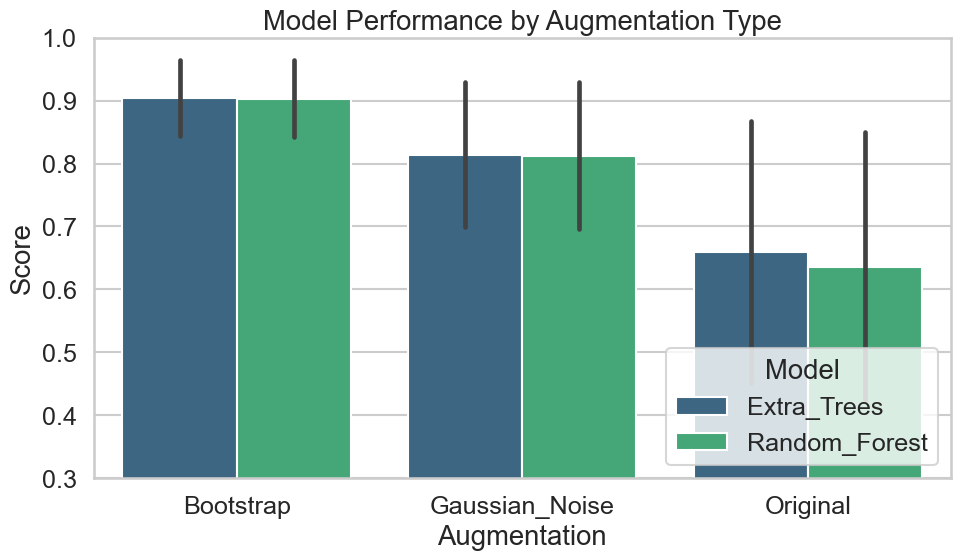

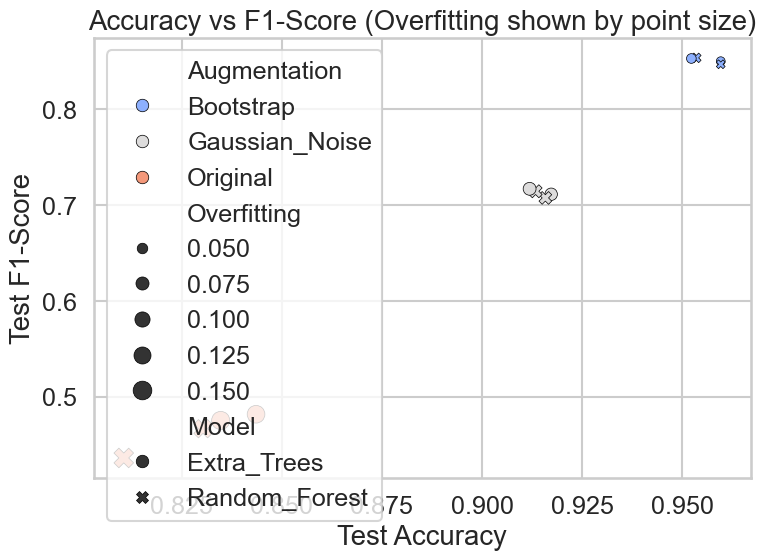

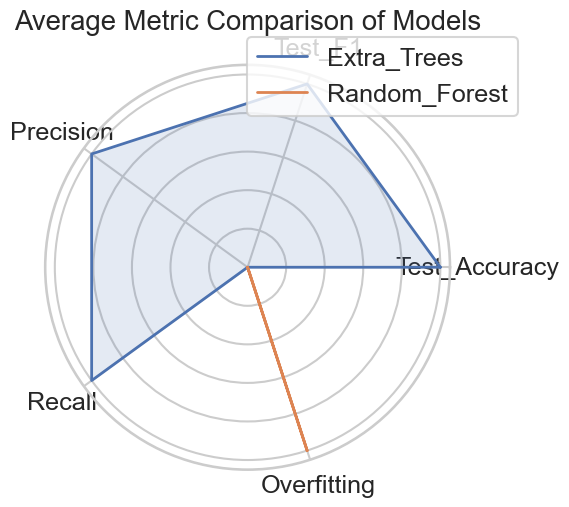

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Load Data ---
df = pd.read_csv("F:/_____My_Thesies____/_ImpFiles/4. LULC/_Paper/3.Results/7.All_Aug_50-50/augmentation_comparison.csv")  # or pd.read_csv("yourfile.csv")

# --- Plot Style ---
sns.set(style="whitegrid", context="talk", font_scale=1.1)

# --- 1. Grouped Barplot: Accuracy & F1 by Augmentation and Model ---
plt.figure(figsize=(10, 6))
df_melt = df.melt(id_vars=["Augmentation", "Model"], value_vars=["Test_Accuracy", "Test_F1"], 
                  var_name="Metric", value_name="Score")

sns.barplot(data=df_melt, x="Augmentation", y="Score", hue="Model", palette="viridis", ci="sd")
plt.title("Model Performance by Augmentation Type")
plt.ylabel("Score")
plt.ylim(0.3, 1.0)
plt.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.show()

# --- 2. Overfitting Scatter Plot: Accuracy vs F1 ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Test_Accuracy", y="Test_F1", hue="Augmentation", style="Model", 
                size="Overfitting", sizes=(40, 200), palette="coolwarm", edgecolor="black")
plt.title("Accuracy vs F1-Score (Overfitting shown by point size)")
plt.xlabel("Test Accuracy")
plt.ylabel("Test F1-Score")
plt.tight_layout()
plt.show()

# --- 3. Radar Plot for Best Models ---
metrics = ["Test_Accuracy", "Test_F1", "Precision", "Recall", "Overfitting"]
best_models = (df.groupby("Model")[metrics].mean()).reset_index()

# Normalize values between 0 and 1 for plotting
best_models_norm = best_models.copy()
best_models_norm[metrics] = (best_models[metrics] - best_models[metrics].min()) / (best_models[metrics].max() - best_models[metrics].min())

labels = metrics
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for i, row in best_models_norm.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row["Model"], linewidth=2)
    ax.fill(angles, values, alpha=0.15)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Average Metric Comparison of Models")
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()


Creating Radar Chart...
Creating Parallel Coordinates Plot...
Creating Interactive Scatter Matrix...
Creating 3D Scatter Plot...
Creating Performance Heatmap...
Creating Facet Grid...
Creating Bar Plot with Error Bars...
Creating Sunburst Chart...
Creating Gauge Charts...
Creating Trend Analysis...
STATE-OF-THE-ART MODEL PERFORMANCE VISUALIZATIONS


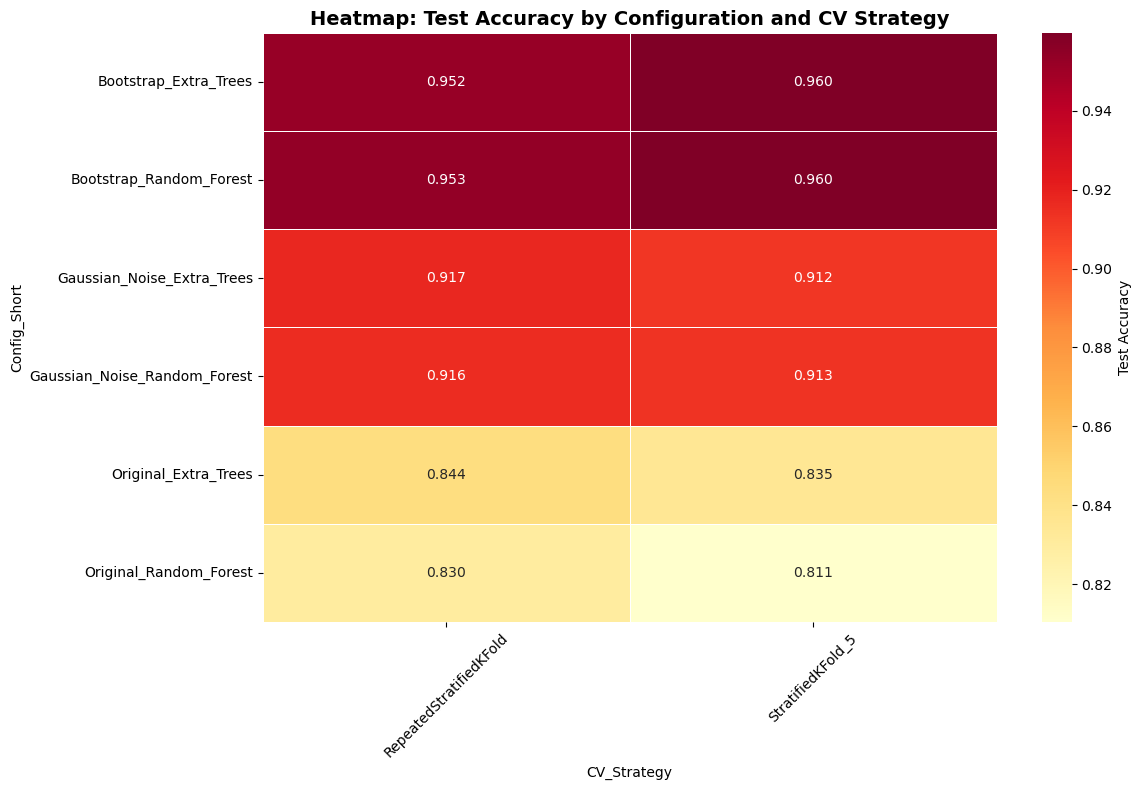

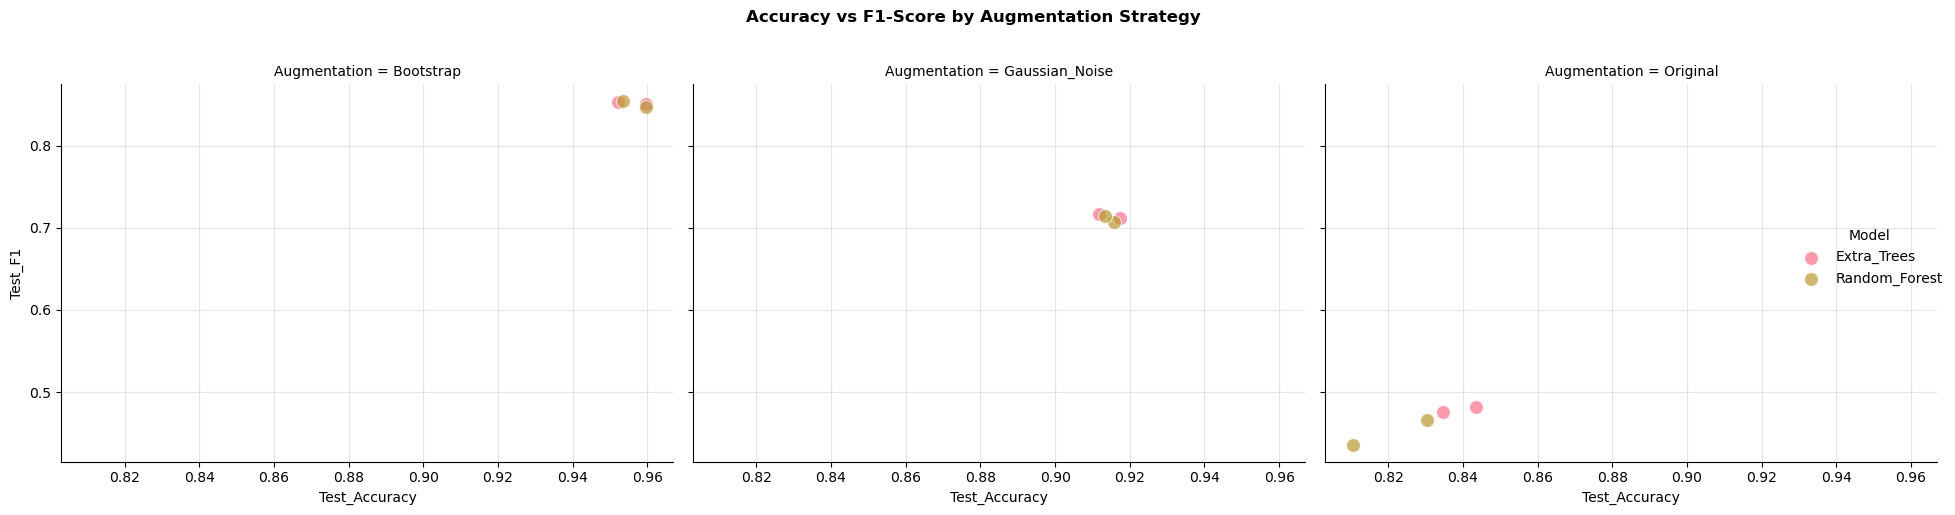

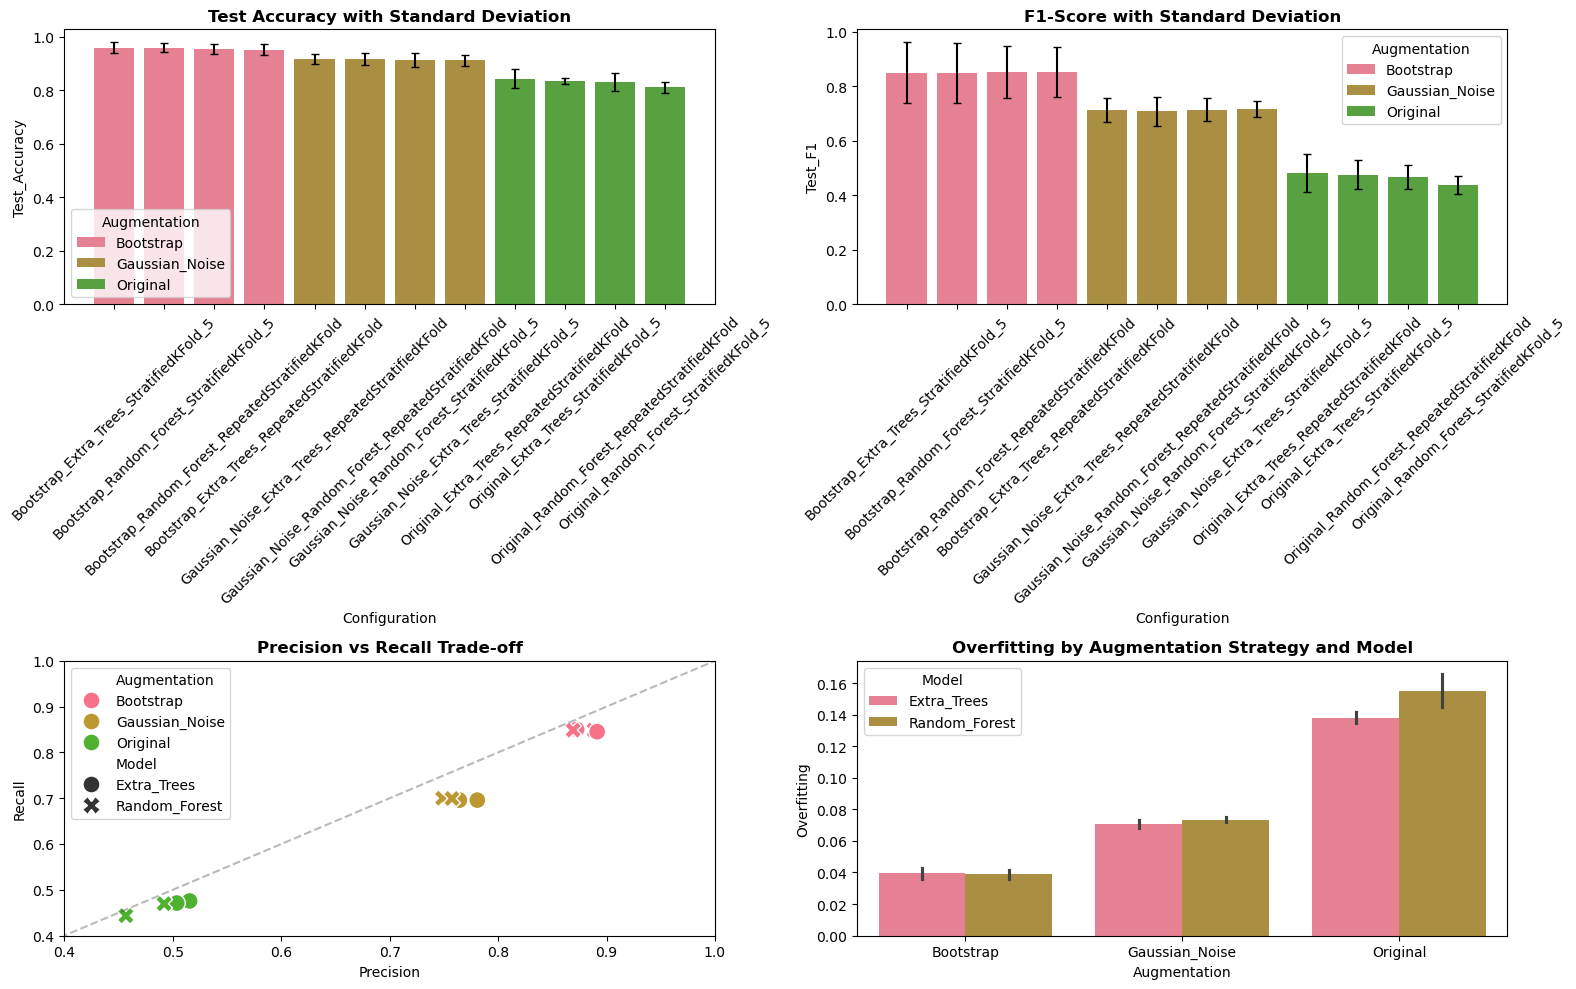

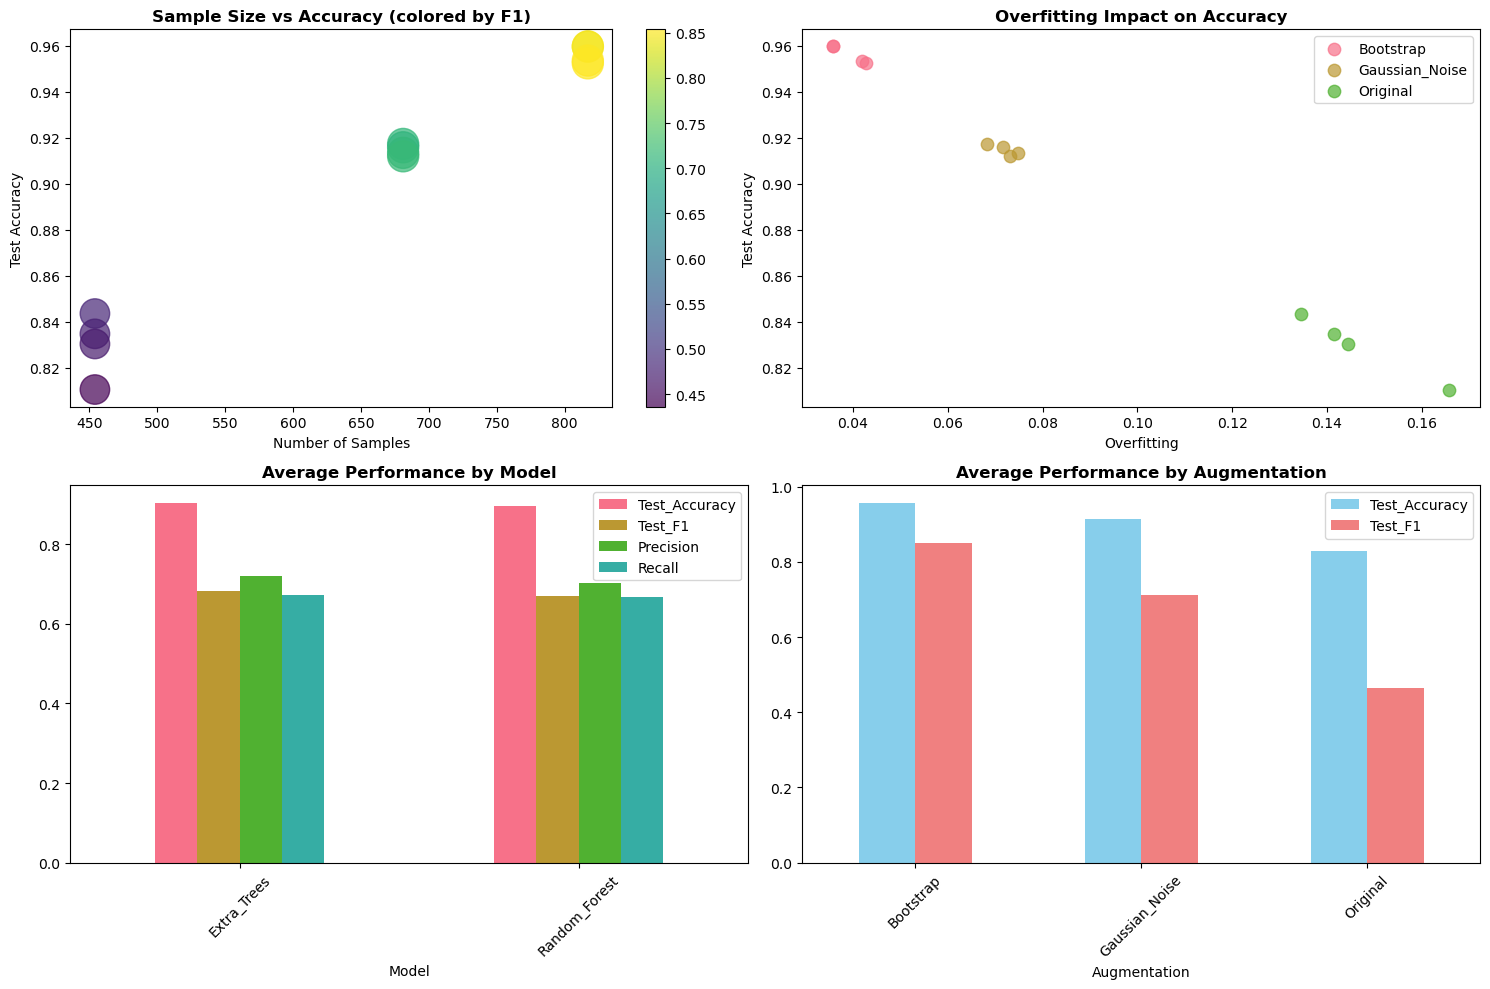


ALL VISUALIZATIONS COMPLETED!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Create the dataframe
data = {
    'Configuration': [
        'Bootstrap_Extra_Trees_StratifiedKFold_5', 'Bootstrap_Random_Forest_StratifiedKFold_5',
        'Bootstrap_Random_Forest_RepeatedStratifiedKFold', 'Bootstrap_Extra_Trees_RepeatedStratifiedKFold',
        'Gaussian_Noise_Extra_Trees_RepeatedStratifiedKFold', 'Gaussian_Noise_Random_Forest_RepeatedStratifiedKFold',
        'Gaussian_Noise_Random_Forest_StratifiedKFold_5', 'Gaussian_Noise_Extra_Trees_StratifiedKFold_5',
        'Original_Extra_Trees_RepeatedStratifiedKFold', 'Original_Extra_Trees_StratifiedKFold_5',
        'Original_Random_Forest_RepeatedStratifiedKFold', 'Original_Random_Forest_StratifiedKFold_5'
    ],
    'Augmentation': ['Bootstrap']*4 + ['Gaussian_Noise']*4 + ['Original']*4,
    'Model': ['Extra_Trees', 'Random_Forest', 'Random_Forest', 'Extra_Trees', 
             'Extra_Trees', 'Random_Forest', 'Random_Forest', 'Extra_Trees',
             'Extra_Trees', 'Extra_Trees', 'Random_Forest', 'Random_Forest'],
    'CV_Strategy': ['StratifiedKFold_5', 'StratifiedKFold_5', 'RepeatedStratifiedKFold', 'RepeatedStratifiedKFold',
                   'RepeatedStratifiedKFold', 'RepeatedStratifiedKFold', 'StratifiedKFold_5', 'StratifiedKFold_5',
                   'RepeatedStratifiedKFold', 'StratifiedKFold_5', 'RepeatedStratifiedKFold', 'StratifiedKFold_5'],
    'Samples': [817, 817, 817, 817, 681, 681, 681, 681, 454, 454, 454, 454],
    'Features': [50, 50, 50, 50, 50, 50, 50, 50, 45, 45, 45, 45],
    'Test_Accuracy': [0.959591501, 0.959591501, 0.953483964, 0.952254477, 0.917257049, 0.915800773, 
                     0.913364105, 0.911872048, 0.843573464, 0.834749695, 0.83033781, 0.810549451],
    'Accuracy_Std': [0.019272561, 0.01676606, 0.019340731, 0.019030922, 0.017770066, 0.022627771,
                    0.024776488, 0.021385871, 0.034140203, 0.012800286, 0.03459301, 0.019129719],
    'Test_F1': [0.850308186, 0.847091923, 0.853778364, 0.853117816, 0.711393222, 0.707583239,
               0.71454005, 0.717101575, 0.481776027, 0.47528107, 0.46665663, 0.436150094],
    'F1_Std': [0.110748576, 0.109988404, 0.095715443, 0.091945554, 0.044389918, 0.053380184,
              0.043567919, 0.028147983, 0.068996217, 0.052079976, 0.04423814, 0.032933065],
    'Precision': [0.872428041, 0.869178306, 0.888472174, 0.891321607, 0.764279778, 0.748856835,
                 0.757436074, 0.780822183, 0.51543544, 0.503612424, 0.491952196, 0.456682543],
    'Recall': [0.850150286, 0.848648763, 0.848587037, 0.845221484, 0.695751101, 0.699874774,
              0.699343026, 0.695828153, 0.475647001, 0.471027392, 0.469543469, 0.443454433],
    'Overfitting': [0.035818533, 0.03581947, 0.041824601, 0.042850372, 0.068302629, 0.071715642,
                   0.074887379, 0.073076684, 0.134586255, 0.141578522, 0.144515619, 0.165772712]
}

df = pd.DataFrame(data)

# Set style
plt.style.use('default')
sns.set_palette("husl")

# ============================================================================
# 1. RADAR CHART - Comprehensive Model Comparison
# ============================================================================
print("Creating Radar Chart...")

def create_radar_chart():
    metrics = ['Test_Accuracy', 'Test_F1', 'Precision', 'Recall', 'Overfitting']
    
    # Normalize metrics (lower is better for Overfitting, so we invert it)
    radar_df = df[['Configuration', 'Augmentation', 'Model'] + metrics].copy()
    for metric in metrics:
        if metric == 'Overfitting':
            # For overfitting, lower is better, so we invert and normalize
            radar_df[metric] = 1 - (radar_df[metric] - radar_df[metric].min()) / (radar_df[metric].max() - radar_df[metric].min())
        else:
            radar_df[metric] = (radar_df[metric] - radar_df[metric].min()) / (radar_df[metric].max() - radar_df[metric].min())
    
    # Select top 3 configurations from each augmentation type
    top_configs = []
    for aug in df['Augmentation'].unique():
        top = df[df['Augmentation'] == aug].nlargest(3, 'Test_Accuracy')['Configuration'].tolist()
        top_configs.extend(top)
    
    fig = go.Figure()
    
    colors = px.colors.qualitative.Set3
    for i, config in enumerate(top_configs[:6]):  # Show top 6 for clarity
        config_data = radar_df[radar_df['Configuration'] == config].iloc[0]
        values = config_data[metrics].tolist()
        values += values[:1]  # Complete the circle
        
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=metrics + [metrics[0]],
            fill='toself',
            name=f"{config_data['Augmentation']} - {config_data['Model']}",
            line=dict(color=colors[i % len(colors)], width=2),
            opacity=0.7
        ))
    
    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[0, 1])
        ),
        showlegend=True,
        title="Radar Chart: Comprehensive Model Performance Comparison<br><sub>Normalized Metrics (Higher is Better)</sub>",
        font=dict(size=12),
        height=600
    )
    fig.show()

# ============================================================================
# 2. PARALLEL COORDINATES PLOT
# ============================================================================
print("Creating Parallel Coordinates Plot...")

def create_parallel_plot():
    fig = px.parallel_coordinates(df, 
                                color="Test_Accuracy",
                                dimensions=['Test_Accuracy', 'Test_F1', 'Precision', 'Recall', 'Overfitting', 'Samples'],
                                color_continuous_scale=px.colors.sequential.Viridis,
                                title="Parallel Coordinates: Multi-Dimensional Model Performance")
    fig.update_layout(height=500)
    fig.show()

# ============================================================================
# 3. INTERACTIVE SCATTER PLOT MATRIX
# ============================================================================
print("Creating Interactive Scatter Matrix...")

def create_scatter_matrix():
    fig = px.scatter_matrix(df,
                           dimensions=['Test_Accuracy', 'Test_F1', 'Precision', 'Recall', 'Overfitting'],
                           color="Augmentation",
                           symbol="Model",
                           hover_name="Configuration",
                           title="Scatter Plot Matrix: Performance Metrics Relationships",
                           opacity=0.7)
    fig.update_traces(diagonal_visible=False)
    fig.update_layout(height=800)
    fig.show()

# ============================================================================
# 4. 3D SCATTER PLOT
# ============================================================================
print("Creating 3D Scatter Plot...")

def create_3d_scatter():
    fig = px.scatter_3d(df, 
                       x='Test_Accuracy', 
                       y='Test_F1', 
                       z='Overfitting',
                       color='Augmentation',
                       size='Samples',
                       symbol='Model',
                       hover_name='Configuration',
                       title='3D Performance Space: Accuracy vs F1 vs Overfitting',
                       opacity=0.8)
    fig.update_layout(height=700)
    fig.show()

# ============================================================================
# 5. HEATMAP OF PERFORMANCE METRICS
# ============================================================================
print("Creating Performance Heatmap...")

def create_performance_heatmap():
    # Create a simplified configuration name for display
    df['Config_Short'] = df['Augmentation'] + '_' + df['Model']
    
    # Pivot for heatmap
    heatmap_data = df.pivot(index='Config_Short', 
                           columns='CV_Strategy', 
                           values='Test_Accuracy')
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
                cbar_kws={'label': 'Test Accuracy'}, linewidths=0.5)
    plt.title('Heatmap: Test Accuracy by Configuration and CV Strategy', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ============================================================================
# 6. FACET GRID COMPARISON
# ============================================================================
print("Creating Facet Grid...")

def create_facet_grid():
    g = sns.FacetGrid(df, col='Augmentation', hue='Model', height=5, aspect=1.2)
    g.map(sns.scatterplot, 'Test_Accuracy', 'Test_F1', s=100, alpha=0.7)
    g.add_legend()
    g.fig.suptitle('Accuracy vs F1-Score by Augmentation Strategy', y=1.02, fontweight='bold')
    
    for ax in g.axes.flat:
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 7. BAR PLOT WITH ERROR BARS
# ============================================================================
print("Creating Bar Plot with Error Bars...")

def create_error_bar_plot():
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
    
    # Accuracy with std
    sns.barplot(data=df, x='Configuration', y='Test_Accuracy', hue='Augmentation', ax=ax1)
    ax1.errorbar(x=range(len(df)), y=df['Test_Accuracy'], 
                yerr=df['Accuracy_Std'], fmt='none', c='black', capsize=3)
    ax1.set_title('Test Accuracy with Standard Deviation', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    
    # F1 Score with std
    sns.barplot(data=df, x='Configuration', y='Test_F1', hue='Augmentation', ax=ax2)
    ax2.errorbar(x=range(len(df)), y=df['Test_F1'], 
                yerr=df['F1_Std'], fmt='none', c='black', capsize=3)
    ax2.set_title('F1-Score with Standard Deviation', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    
    # Precision vs Recall
    sns.scatterplot(data=df, x='Precision', y='Recall', hue='Augmentation', 
                   style='Model', s=150, ax=ax3)
    ax3.set_title('Precision vs Recall Trade-off', fontweight='bold')
    ax3.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax3.set_xlim(0.4, 1.0)
    ax3.set_ylim(0.4, 1.0)
    
    # Overfitting analysis
    sns.barplot(data=df, x='Augmentation', y='Overfitting', hue='Model', ax=ax4)
    ax4.set_title('Overfitting by Augmentation Strategy and Model', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 8. SUNBURST CHART (HIERARCHICAL)
# ============================================================================
print("Creating Sunburst Chart...")

def create_sunburst_chart():
    fig = px.sunburst(df, 
                     path=['Augmentation', 'Model', 'CV_Strategy'], 
                     values='Test_Accuracy',
                     color='Test_F1',
                     color_continuous_scale='RdYlGn',
                     title='Sunburst Chart: Hierarchical Model Performance',
                     hover_data=['Samples', 'Overfitting'])
    fig.update_layout(height=700)
    fig.show()

# ============================================================================
# 9. PERFORMANCE GAUGE CHARTS
# ============================================================================
print("Creating Gauge Charts...")

def create_gauge_charts():
    # Select top configuration
    top_config = df.loc[df['Test_Accuracy'].idxmax()]
    
    fig = make_subplots(rows=2, cols=2, 
                       specs=[[{'type': 'indicator'}, {'type': 'indicator'}],
                             [{'type': 'indicator'}, {'type': 'indicator'}]],
                       subplot_titles=['Accuracy', 'F1-Score', 'Precision', 'Recall'])
    
    # Accuracy gauge
    fig.add_trace(go.Indicator(
        mode="gauge+number+delta",
        value=top_config['Test_Accuracy'],
        title={'text': f"Accuracy - {top_config['Model']}"},
        domain={'row': 0, 'column': 0},
        gauge={'axis': {'range': [0.8, 1.0]},
               'bar': {'color': "darkblue"},
               'steps': [{'range': [0.8, 0.9], 'color': "lightgray"},
                        {'range': [0.9, 1.0], 'color': "gray"}]}
    ), row=1, col=1)
    
    # F1-Score gauge
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=top_config['Test_F1'],
        title={'text': "F1-Score"},
        domain={'row': 0, 'column': 1},
        gauge={'axis': {'range': [0, 1]},
               'bar': {'color': "darkgreen"}}
    ), row=1, col=2)
    
    # Precision gauge
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=top_config['Precision'],
        title={'text': "Precision"},
        domain={'row': 1, 'column': 0},
        gauge={'axis': {'range': [0, 1]},
               'bar': {'color': "darkred"}}
    ), row=2, col=1)
    
    # Recall gauge
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=top_config['Recall'],
        title={'text': "Recall"},
        domain={'row': 1, 'column': 1},
        gauge={'axis': {'range': [0, 1]},
               'bar': {'color': "darkorange"}}
    ), row=2, col=2)
    
    fig.update_layout(
        title=f"Performance Gauges - Best Configuration: {top_config['Configuration']}",
        height=500
    )
    fig.show()

# ============================================================================
# 10. TREND ANALYSIS PLOT
# ============================================================================
print("Creating Trend Analysis...")

def create_trend_analysis():
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Samples vs Performance
    sc1 = axes[0,0].scatter(df['Samples'], df['Test_Accuracy'], 
                           c=df['Test_F1'], s=df['Features']*10, 
                           cmap='viridis', alpha=0.7)
    axes[0,0].set_xlabel('Number of Samples')
    axes[0,0].set_ylabel('Test Accuracy')
    axes[0,0].set_title('Sample Size vs Accuracy (colored by F1)', fontweight='bold')
    plt.colorbar(sc1, ax=axes[0,0])
    
    # Overfitting vs Performance
    for aug in df['Augmentation'].unique():
        subset = df[df['Augmentation'] == aug]
        axes[0,1].scatter(subset['Overfitting'], subset['Test_Accuracy'], 
                         label=aug, s=80, alpha=0.7)
    axes[0,1].set_xlabel('Overfitting')
    axes[0,1].set_ylabel('Test Accuracy')
    axes[0,1].set_title('Overfitting Impact on Accuracy', fontweight='bold')
    axes[0,1].legend()
    
    # Model comparison
    model_metrics = df.groupby('Model')[['Test_Accuracy', 'Test_F1', 'Precision', 'Recall']].mean()
    model_metrics.plot(kind='bar', ax=axes[1,0])
    axes[1,0].set_title('Average Performance by Model', fontweight='bold')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Augmentation strategy comparison
    aug_metrics = df.groupby('Augmentation')[['Test_Accuracy', 'Test_F1']].mean()
    aug_metrics.plot(kind='bar', ax=axes[1,1], color=['skyblue', 'lightcoral'])
    axes[1,1].set_title('Average Performance by Augmentation', fontweight='bold')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# EXECUTE ALL VISUALIZATIONS
# ============================================================================
if __name__ == "__main__":
    print("="*60)
    print("STATE-OF-THE-ART MODEL PERFORMANCE VISUALIZATIONS")
    print("="*60)
    
    # Create all visualizations
    create_radar_chart()
    create_parallel_plot()
    create_scatter_matrix()
    create_3d_scatter()
    create_performance_heatmap()
    create_facet_grid()
    create_error_bar_plot()
    create_sunburst_chart()
    create_gauge_charts()
    create_trend_analysis()
    
    print("\n" + "="*60)
    print("ALL VISUALIZATIONS COMPLETED!")
    print("="*60)

In [4]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data from the table
data = {
    'Configuration': [
        'Bootstrap_Extra_Trees_StratifiedKFold_5', 'Bootstrap_Random_Forest_StratifiedKFold_5',
        'Bootstrap_Random_Forest_RepeatedStratifiedKFold', 'Bootstrap_Extra_Trees_RepeatedStratifiedKFold',
        'Gaussian_Noise_Extra_Trees_RepeatedStratifiedKFold', 'Gaussian_Noise_Random_Forest_RepeatedStratifiedKFold',
        'Gaussian_Noise_Random_Forest_StratifiedKFold_5', 'Gaussian_Noise_Extra_Trees_StratifiedKFold_5',
        'Original_Extra_Trees_RepeatedStratifiedKFold', 'Original_Extra_Trees_StratifiedKFold_5',
        'Original_Random_Forest_RepeatedStratifiedKFold', 'Original_Random_Forest_StratifiedKFold_5'
    ],
    'Augmentation': [
        'Bootstrap', 'Bootstrap', 'Bootstrap', 'Bootstrap', 'Gaussian_Noise', 'Gaussian_Noise',
        'Gaussian_Noise', 'Gaussian_Noise', 'Original', 'Original', 'Original', 'Original'
    ],
    'Model': [
        'Extra_Trees', 'Random_Forest', 'Random_Forest', 'Extra_Trees', 'Extra_Trees', 'Random_Forest',
        'Random_Forest', 'Extra_Trees', 'Extra_Trees', 'Extra_Trees', 'Random_Forest', 'Random_Forest'
    ],
    'CV_Strategy': [
        'StratifiedKFold_5', 'StratifiedKFold_5', 'RepeatedStratifiedKFold', 'RepeatedStratifiedKFold',
        'RepeatedStratifiedKFold', 'RepeatedStratifiedKFold', 'StratifiedKFold_5', 'StratifiedKFold_5',
        'RepeatedStratifiedKFold', 'StratifiedKFold_5', 'RepeatedStratifiedKFold', 'StratifiedKFold_5'
    ],
    'Samples': [817, 817, 817, 817, 681, 681, 681, 681, 454, 454, 454, 454],
    'Features': [50, 50, 50, 50, 50, 50, 50, 50, 45, 45, 45, 45],
    'Test_Accuracy': [
        0.959591501, 0.959591501, 0.953483964, 0.952254477, 0.917257049, 0.915800773,
        0.913364105, 0.911872048, 0.843573464, 0.834749695, 0.83033781, 0.810549451
    ],
    'Accuracy_Std': [
        0.019272561, 0.01676606, 0.019340731, 0.019030922, 0.017770066, 0.022627771,
        0.024776488, 0.021385871, 0.034140203, 0.012800286, 0.03459301, 0.019129719
    ],
    'Test_F1': [
        0.850308186, 0.847091923, 0.853778364, 0.853117816, 0.711393222, 0.707583239,
        0.71454005, 0.717101575, 0.481776027, 0.47528107, 0.46665663, 0.436150094
    ],
    'F1_Std': [
        0.110748576, 0.109988404, 0.095715443, 0.091945554, 0.044389918, 0.053380184,
        0.043567919, 0.028147983, 0.068996217, 0.052079976, 0.04423814, 0.032933065
    ],
    'Precision': [
        0.872428041, 0.869178306, 0.888472174, 0.891321607, 0.764279778, 0.748856835,
        0.757436074, 0.780822183, 0.51543544, 0.503612424, 0.491952196, 0.456682543
    ],
    'Recall': [
        0.850150286, 0.848648763, 0.848587037, 0.845221484, 0.695751101, 0.699874774,
        0.699343026, 0.695828153, 0.475647001, 0.471027392, 0.469543469, 0.443454433
    ],
    'Overfitting': [
        0.035818533, 0.03581947, 0.041824601, 0.042850372, 0.068302629, 0.071715642,
        0.074887379, 0.073076684, 0.134586255, 0.141578522, 0.144515619, 0.165772712
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# 1. Parallel Coordinates Plot
fig1 = px.parallel_coordinates(
    df,
    dimensions=['Test_Accuracy', 'Test_F1', 'Precision', 'Recall', 'Overfitting'],
    color='Test_Accuracy',
    labels={
        'Test_Accuracy': 'Test Accuracy',
        'Test_F1': 'F1 Score',
        'Precision': 'Precision',
        'Recall': 'Recall',
        'Overfitting': 'Overfitting'
    },
    color_continuous_scale=px.colors.diverging.Tealrose,
    title='Parallel Coordinates Plot of Model Performance Metrics'
)
fig1.update_layout(
    title={'x': 0.5, 'xanchor': 'center', 'font': {'size': 16}},
    font=dict(size=12),
    height=600
)

# 2. Grouped Bar Plot for Key Metrics by Augmentation and Model
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Test Accuracy', 'F1 Score', 'Precision', 'Recall'),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# Test Accuracy
fig2.add_trace(
    go.Bar(
        x=df['Configuration'], y=df['Test_Accuracy'], name='Test Accuracy',
        marker_color='teal', showlegend=False
    ),
    row=1, col=1
)

# F1 Score
fig2.add_trace(
    go.Bar(
        x=df['Configuration'], y=df['Test_F1'], name='F1 Score',
        marker_color='darkcyan', showlegend=False
    ),
    row=1, col=2
)

# Precision
fig2.add_trace(
    go.Bar(
        x=df['Configuration'], y=df['Precision'], name='Precision',
        marker_color='seagreen', showlegend=False
    ),
    row=2, col=1
)

# Recall
fig2.add_trace(
    go.Bar(
        x=df['Configuration'], y=df['Recall'], name='Recall',
        marker_color='cadetblue', showlegend=False
    ),
    row=2, col=2
)

fig2.update_layout(
    title_text='Grouped Bar Plot of Model Performance Metrics by Configuration',
    title_x=0.5,
    height=800,
    width=1200,
    showlegend=False,
    xaxis=dict(tickangle=45),
    xaxis2=dict(tickangle=45),
    xaxis3=dict(tickangle=45),
    xaxis4=dict(tickangle=45),
    font=dict(size=12)
)
fig2.update_xaxes(tickfont=dict(size=10))

# Show plots
fig1.show()
fig2.show()

# Save plots as HTML for interactive viewing
fig1.write_html('parallel_coordinates.html')
fig2.write_html('grouped_bar.html')

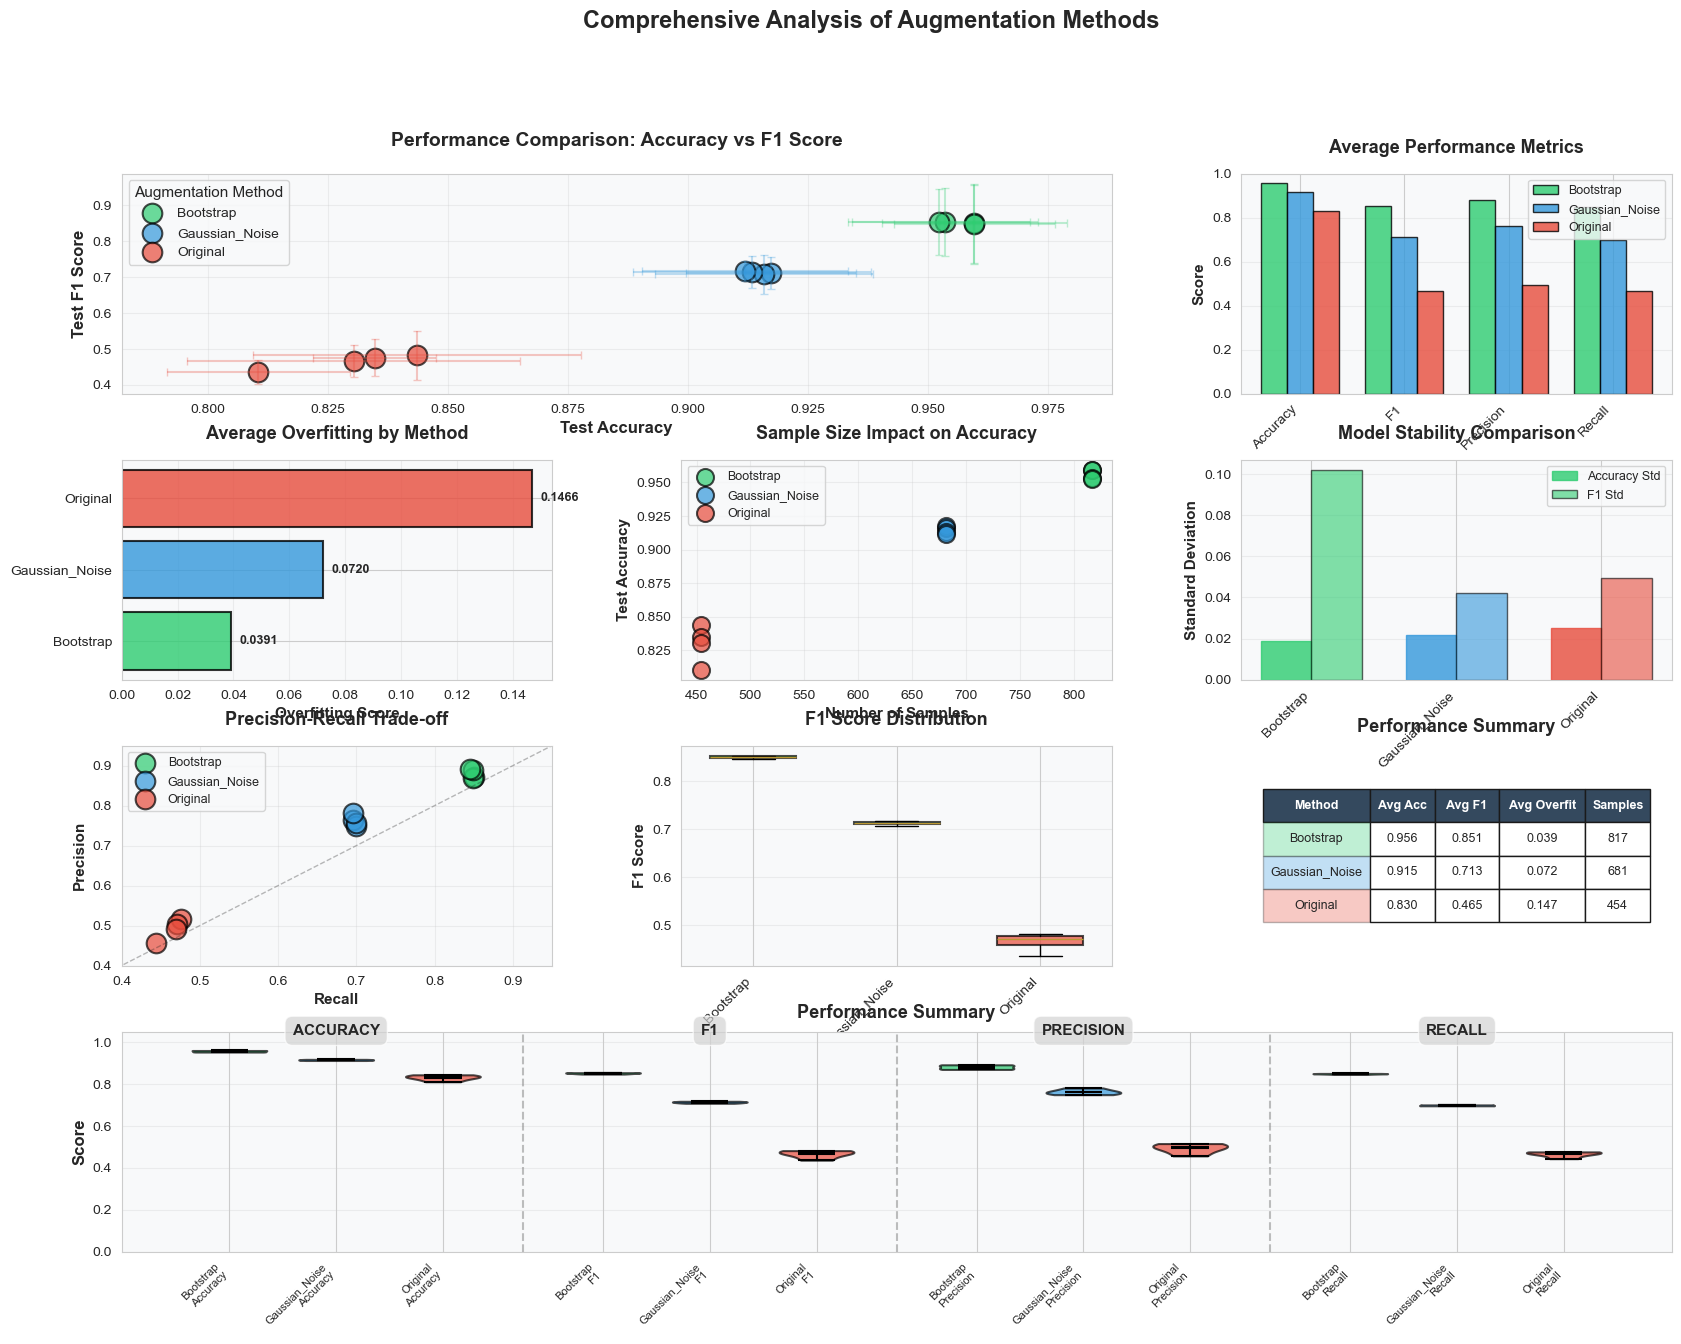

AUGMENTATION METHODS PERFORMANCE SUMMARY

BOOTSTRAP:
  Samples: 817
  Avg Accuracy: 0.9562 (±0.0186)
  Avg F1 Score: 0.8511 (±0.1021)
  Avg Precision: 0.8804
  Avg Recall: 0.8482
  Avg Overfitting: 0.0391

GAUSSIAN_NOISE:
  Samples: 681
  Avg Accuracy: 0.9146 (±0.0216)
  Avg F1 Score: 0.7127 (±0.0424)
  Avg Precision: 0.7628
  Avg Recall: 0.6977
  Avg Overfitting: 0.0720

ORIGINAL:
  Samples: 454
  Avg Accuracy: 0.8298 (±0.0252)
  Avg F1 Score: 0.4650 (±0.0496)
  Avg Precision: 0.4919
  Avg Recall: 0.4649
  Avg Overfitting: 0.1466

KEY FINDINGS:
1. Best Accuracy: Bootstrap (0.9562)
2. Best F1 Score: Bootstrap (0.8511)
3. Least Overfitting: Bootstrap (0.0391)
4. Sample Size Boost: Bootstrap adds 363 samples (+80.0%)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data
data = {
    'Configuration': ['Bootstrap_Extra_Trees_StratifiedKFold_5', 'Bootstrap_Random_Forest_StratifiedKFold_5', 
                     'Bootstrap_Random_Forest_RepeatedStratifiedKFold', 'Bootstrap_Extra_Trees_RepeatedStratifiedKFold',
                     'Gaussian_Noise_Extra_Trees_RepeatedStratifiedKFold', 'Gaussian_Noise_Random_Forest_RepeatedStratifiedKFold',
                     'Gaussian_Noise_Random_Forest_StratifiedKFold_5', 'Gaussian_Noise_Extra_Trees_StratifiedKFold_5',
                     'Original_Extra_Trees_RepeatedStratifiedKFold', 'Original_Extra_Trees_StratifiedKFold_5',
                     'Original_Random_Forest_RepeatedStratifiedKFold', 'Original_Random_Forest_StratifiedKFold_5'],
    'Augmentation': ['Bootstrap', 'Bootstrap', 'Bootstrap', 'Bootstrap', 
                    'Gaussian_Noise', 'Gaussian_Noise', 'Gaussian_Noise', 'Gaussian_Noise',
                    'Original', 'Original', 'Original', 'Original'],
    'Model': ['Extra_Trees', 'Random_Forest', 'Random_Forest', 'Extra_Trees',
             'Extra_Trees', 'Random_Forest', 'Random_Forest', 'Extra_Trees',
             'Extra_Trees', 'Extra_Trees', 'Random_Forest', 'Random_Forest'],
    'CV_Strategy': ['StratifiedKFold_5', 'StratifiedKFold_5', 'RepeatedStratifiedKFold', 'RepeatedStratifiedKFold',
                   'RepeatedStratifiedKFold', 'RepeatedStratifiedKFold', 'StratifiedKFold_5', 'StratifiedKFold_5',
                   'RepeatedStratifiedKFold', 'StratifiedKFold_5', 'RepeatedStratifiedKFold', 'StratifiedKFold_5'],
    'Samples': [817, 817, 817, 817, 681, 681, 681, 681, 454, 454, 454, 454],
    'Features': [50, 50, 50, 50, 50, 50, 50, 50, 45, 45, 45, 45],
    'Test_Accuracy': [0.959591501, 0.959591501, 0.953483964, 0.952254477,
                     0.917257049, 0.915800773, 0.913364105, 0.911872048,
                     0.843573464, 0.834749695, 0.83033781, 0.810549451],
    'Accuracy_Std': [0.019272561, 0.01676606, 0.019340731, 0.019030922,
                    0.017770066, 0.022627771, 0.024776488, 0.021385871,
                    0.034140203, 0.012800286, 0.03459301, 0.019129719],
    'Test_F1': [0.850308186, 0.847091923, 0.853778364, 0.853117816,
               0.711393222, 0.707583239, 0.71454005, 0.717101575,
               0.481776027, 0.47528107, 0.46665663, 0.436150094],
    'F1_Std': [0.110748576, 0.109988404, 0.095715443, 0.091945554,
              0.044389918, 0.053380184, 0.043567919, 0.028147983,
              0.068996217, 0.052079976, 0.04423814, 0.032933065],
    'Precision': [0.872428041, 0.869178306, 0.888472174, 0.891321607,
                 0.764279778, 0.748856835, 0.757436074, 0.780822183,
                 0.51543544, 0.503612424, 0.491952196, 0.456682543],
    'Recall': [0.850150286, 0.848648763, 0.848587037, 0.845221484,
              0.695751101, 0.699874774, 0.699343026, 0.695828153,
              0.475647001, 0.471027392, 0.469543469, 0.443454433],
    'Overfitting': [0.035818533, 0.03581947, 0.041824601, 0.042850372,
                   0.068302629, 0.071715642, 0.074887379, 0.073076684,
                   0.134586255, 0.141578522, 0.144515619, 0.165772712]
}

df = pd.DataFrame(data)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'

# Create color palette
colors = {'Bootstrap': '#2ecc71', 'Gaussian_Noise': '#3498db', 'Original': '#e74c3c'}

# Create figure with subplots
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Main Performance Comparison (Accuracy vs F1)
ax1 = fig.add_subplot(gs[0, :2])
for aug in df['Augmentation'].unique():
    data_aug = df[df['Augmentation'] == aug]
    ax1.scatter(data_aug['Test_Accuracy'], data_aug['Test_F1'], 
               s=200, alpha=0.7, label=aug, color=colors[aug], edgecolors='black', linewidth=1.5)
    
    # Add error bars
    ax1.errorbar(data_aug['Test_Accuracy'], data_aug['Test_F1'],
                xerr=data_aug['Accuracy_Std'], yerr=data_aug['F1_Std'],
                fmt='none', ecolor=colors[aug], alpha=0.3, capsize=3)

ax1.set_xlabel('Test Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test F1 Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance Comparison: Accuracy vs F1 Score', fontsize=14, fontweight='bold', pad=20)
ax1.legend(title='Augmentation Method', fontsize=10, title_fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. Grouped Bar Chart - Average Metrics
ax2 = fig.add_subplot(gs[0, 2])
metrics_avg = df.groupby('Augmentation')[['Test_Accuracy', 'Test_F1', 'Precision', 'Recall']].mean()
x = np.arange(len(metrics_avg.columns))
width = 0.25

for i, aug in enumerate(metrics_avg.index):
    offset = (i - 1) * width
    ax2.bar(x + offset, metrics_avg.loc[aug], width, 
           label=aug, color=colors[aug], alpha=0.8, edgecolor='black', linewidth=1)

ax2.set_ylabel('Score', fontsize=11, fontweight='bold')
ax2.set_title('Average Performance Metrics', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(['Accuracy', 'F1', 'Precision', 'Recall'], rotation=45, ha='right')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 1])

# 3. Overfitting Comparison
ax3 = fig.add_subplot(gs[1, 0])
overfitting_avg = df.groupby('Augmentation')['Overfitting'].mean().sort_values()
bars = ax3.barh(overfitting_avg.index, overfitting_avg.values, 
               color=[colors[aug] for aug in overfitting_avg.index],
               alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Overfitting Score', fontsize=11, fontweight='bold')
ax3.set_title('Average Overfitting by Method', fontsize=13, fontweight='bold', pad=15)
ax3.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (aug, val) in enumerate(overfitting_avg.items()):
    ax3.text(val + 0.003, i, f'{val:.4f}', va='center', fontweight='bold', fontsize=9)

# 4. Sample Size Impact
ax4 = fig.add_subplot(gs[1, 1])
for aug in df['Augmentation'].unique():
    data_aug = df[df['Augmentation'] == aug]
    ax4.scatter(data_aug['Samples'], data_aug['Test_Accuracy'], 
               s=150, alpha=0.7, label=aug, color=colors[aug], edgecolors='black', linewidth=1.5)

ax4.set_xlabel('Number of Samples', fontsize=11, fontweight='bold')
ax4.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax4.set_title('Sample Size Impact on Accuracy', fontsize=13, fontweight='bold', pad=15)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 5. Stability Analysis (Standard Deviations)
ax5 = fig.add_subplot(gs[1, 2])
stability_data = df.groupby('Augmentation')[['Accuracy_Std', 'F1_Std']].mean()
x_pos = np.arange(len(stability_data.index))
width = 0.35

bars1 = ax5.bar(x_pos - width/2, stability_data['Accuracy_Std'], width,
               label='Accuracy Std', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax5.bar(x_pos + width/2, stability_data['F1_Std'], width,
               label='F1 Std', alpha=0.8, edgecolor='black', linewidth=1)

# Color bars by augmentation method
for i, aug in enumerate(stability_data.index):
    bars1[i].set_color(colors[aug])
    bars2[i].set_facecolor(colors[aug])
    bars2[i].set_alpha(0.6)

ax5.set_ylabel('Standard Deviation', fontsize=11, fontweight='bold')
ax5.set_title('Model Stability Comparison', fontsize=13, fontweight='bold', pad=15)
ax5.set_xticks(x_pos)
ax5.set_xticklabels(stability_data.index, rotation=45, ha='right')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Precision-Recall Trade-off
ax6 = fig.add_subplot(gs[2, 0])
for aug in df['Augmentation'].unique():
    data_aug = df[df['Augmentation'] == aug]
    ax6.scatter(data_aug['Recall'], data_aug['Precision'], 
               s=200, alpha=0.7, label=aug, color=colors[aug], edgecolors='black', linewidth=1.5)

ax6.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax6.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax6.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax6.set_title('Precision-Recall Trade-off', fontsize=13, fontweight='bold', pad=15)
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)
ax6.set_xlim([0.4, 0.95])
ax6.set_ylim([0.4, 0.95])

# 7. Box plot - F1 Score Distribution
ax7 = fig.add_subplot(gs[2, 1])
f1_data = [df[df['Augmentation'] == aug]['Test_F1'].values for aug in ['Bootstrap', 'Gaussian_Noise', 'Original']]
bp = ax7.boxplot(f1_data, labels=['Bootstrap', 'Gaussian_Noise', 'Original'],
                patch_artist=True, widths=0.6)

for patch, aug in zip(bp['boxes'], ['Bootstrap', 'Gaussian_Noise', 'Original']):
    patch.set_facecolor(colors[aug])
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

ax7.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax7.set_title('F1 Score Distribution', fontsize=13, fontweight='bold', pad=15)
ax7.grid(True, alpha=0.3, axis='y')
plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 8. Summary Table
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')

summary_data = []
for aug in ['Bootstrap', 'Gaussian_Noise', 'Original']:
    data_aug = df[df['Augmentation'] == aug]
    summary_data.append([
        aug,
        f"{data_aug['Test_Accuracy'].mean():.3f}",
        f"{data_aug['Test_F1'].mean():.3f}",
        f"{data_aug['Overfitting'].mean():.3f}",
        f"{data_aug['Samples'].iloc[0]}"
    ])

table = ax8.table(cellText=summary_data,
                 colLabels=['Method', 'Avg Acc', 'Avg F1', 'Avg Overfit', 'Samples'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.25, 0.15, 0.15, 0.2, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Color code the table
for i, aug in enumerate(['Bootstrap', 'Gaussian_Noise', 'Original'], start=1):
    table[(i, 0)].set_facecolor(colors[aug])
    table[(i, 0)].set_alpha(0.3)

for i in range(5):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax8.set_title('Performance Summary', fontsize=13, fontweight='bold', pad=10)

# 9. Violin Plot - Performance Metrics Distribution
ax9 = fig.add_subplot(gs[3, :])

# Prepare data for violin plot
metrics_list = ['Test_Accuracy', 'Test_F1', 'Precision', 'Recall']
plot_data = []
plot_labels = []
plot_colors = []

for metric in metrics_list:
    for aug in ['Bootstrap', 'Gaussian_Noise', 'Original']:
        data_aug = df[df['Augmentation'] == aug][metric].values
        plot_data.append(data_aug)
        plot_labels.append(f'{aug}\n{metric.replace("Test_", "")}')
        plot_colors.append(colors[aug])

positions = []
pos = 0
for i in range(len(metrics_list)):
    for j in range(3):
        positions.append(pos)
        pos += 1
    pos += 0.5  # Add spacing between metric groups

parts = ax9.violinplot(plot_data, positions=positions, widths=0.7, 
                       showmeans=True, showmedians=True)

# Color the violin plots
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plot_colors[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

# Customize the plot elements
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts:
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(1.5)

ax9.set_ylabel('Score', fontsize=12, fontweight='bold')
ax9.set_title('Distribution of Performance Metrics by Augmentation Method (Violin Plot)', 
             fontsize=14, fontweight='bold', pad=20)
ax9.set_xticks(positions)
ax9.set_xticklabels(plot_labels, rotation=45, ha='right', fontsize=8)
ax9.grid(True, alpha=0.3, axis='y')
ax9.set_ylim([0, 1.05])

# Add vertical lines to separate metric groups
for i in range(1, len(metrics_list)):
    x_pos = positions[i*3 - 1] + (positions[i*3] - positions[i*3 - 1]) / 2
    ax9.axvline(x=x_pos, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# Add metric group labels
metric_centers = []
for i in range(len(metrics_list)):
    center = np.mean(positions[i*3:(i+1)*3])
    metric_centers.append(center)

for i, metric in enumerate(metrics_list):
    ax9.text(metric_centers[i], 1.02, metric.replace('Test_', '').upper(), 
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.7))

ax9.set_title('Performance Summary', fontsize=13, fontweight='bold', pad=10)

plt.suptitle('Comprehensive Analysis of Augmentation Methods', 
             fontsize=17, fontweight='bold', y=0.997)

plt.tight_layout()
plt.savefig('F:/_____My_Thesies____/_ImpFiles/4. LULC/_Paper/3.Results/7.All_Aug_50-50/augmentation_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

# Print Statistical Summary
print("=" * 80)
print("AUGMENTATION METHODS PERFORMANCE SUMMARY")
print("=" * 80)

for aug in ['Bootstrap', 'Gaussian_Noise', 'Original']:
    data_aug = df[df['Augmentation'] == aug]
    print(f"\n{aug.upper()}:")
    print(f"  Samples: {data_aug['Samples'].iloc[0]}")
    print(f"  Avg Accuracy: {data_aug['Test_Accuracy'].mean():.4f} (±{data_aug['Accuracy_Std'].mean():.4f})")
    print(f"  Avg F1 Score: {data_aug['Test_F1'].mean():.4f} (±{data_aug['F1_Std'].mean():.4f})")
    print(f"  Avg Precision: {data_aug['Precision'].mean():.4f}")
    print(f"  Avg Recall: {data_aug['Recall'].mean():.4f}")
    print(f"  Avg Overfitting: {data_aug['Overfitting'].mean():.4f}")

print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("=" * 80)
print(f"1. Best Accuracy: Bootstrap ({df[df['Augmentation']=='Bootstrap']['Test_Accuracy'].mean():.4f})")
print(f"2. Best F1 Score: Bootstrap ({df[df['Augmentation']=='Bootstrap']['Test_F1'].mean():.4f})")
print(f"3. Least Overfitting: Bootstrap ({df[df['Augmentation']=='Bootstrap']['Overfitting'].mean():.4f})")
print(f"4. Sample Size Boost: Bootstrap adds {817-454} samples (+{((817-454)/454*100):.1f}%)")
print("=" * 80)